In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import ast 
from sklearn.metrics import make_scorer
from sklearn.model_selection import cross_validate, KFold
from sklearn.model_selection import cross_val_predict

In [2]:
train_fixed = pd.read_csv('fixed_train_set_0.8.csv')
test_fixed = pd.read_csv('fixed_test_set_0.2.csv')

In [3]:
print(train_fixed.shape)
train_fixed.head()

(558, 6)


,surfaceComposition,Facet,ChemicalComposition,Site,O*_energy,OH*_energy
0,Au3Bi,111,Au9Bi3,hollow|A_A_A|HCP,2.021316,1.135781
1,AgBi,101,Ag6Bi6,hollow|A_B_B|FCC,1.280299,0.360114
2,Cu3Zn,111,Cu9Zn3,hollow|A_A_A|FCC,0.981924,0.240317
3,RhZn,101,Rh6Zn6,top|B,2.863009,1.020129
4,Rh3Ru,111,Rh9Ru3,hollow|A_A_B|FCC,0.265972,0.133044


In [4]:
print(test_fixed.shape)
test_fixed.head()

(140, 6)


,surfaceComposition,Facet,ChemicalComposition,Site,O*_energy,OH*_energy
0,BiRu,101,Bi6Ru6,top-tilt|B,1.136508,0.245490
1,Re3Tc,111,Re9Tc3,hollow|A_A_A|HCP,-1.346391,-0.586845
2,Pd3Cu,111,Cu3Pd9,top|B,2.723777,1.422551
3,BiRh,101,Bi6Rh6,hollow-tilt|A_A_B|FCC,1.462971,0.423030
4,La,111,La12,hollow|A_A_A|HCP,-2.911750,-2.104819


In [5]:
train_fixed["Site"].head()

0    hollow|A_A_A|HCP
1    hollow|A_B_B|FCC
2    hollow|A_A_A|FCC
3               top|B
4    hollow|A_A_B|FCC
Name: Site, dtype: object

In [6]:
import re

def get_coord_number(site_str, plane, surfaceComposition=None):
    # convert inputs to strings safely
    site_str_lower = str(site_str).lower().strip()
    
    plane_str = str(plane).strip()
    surfaceComposition_str = str(surfaceComposition).lower() if surfaceComposition is not None else ""

    # 1. BCC + plane 110
    if "bcc" in surfaceComposition_str and plane_str == "110":
        return 4

    # 2. Single element like "Cr", "O"
    if re.fullmatch(r"^[A-Z][a-z]?(?:-site)?$", str(site_str).strip()):
        return 1

    # 3. Explicitly defined top-like metal sites
    if site_str in ["O1C", "O2C", "CUS", "M1", "M2"]:
        return 1

    if site_str == "metal-site":
        return 1

    # 4. Top site
    if "top" in site_str_lower:
        return 1

    if "cus" in site_str_lower:
        return 1

    # 5. Bridge or peroxo
    if "bridge" in site_str_lower or "peroxo" in site_str_lower:
        return 2

    # 6. Hollow/fcc/hcp
    if "hollow" in site_str_lower or "fcc" in site_str_lower or "hcp" in site_str_lower:
        if plane_str in ["100", "101", "110"]:
            return 4
        else:
            return 3

    if site_str == "Ir-site--Cr-nonadjacent" or site_str == "Ir-site--Cr-adjacent":
        return 1


    # Default
    return None



train_fixed["CoordinationNumber"] = train_fixed.apply(
    lambda row: get_coord_number(row["Site"], row["Facet"], row.get("surfaceComposition")), axis=1)

test_fixed["CoordinationNumber"] = test_fixed.apply(
    lambda row: get_coord_number(row["Site"], row["Facet"], row.get("surfaceComposition")), axis=1)


# Quick check
#train_fixed[["Site", "CoordinationNumber"]].head(10)


In [7]:
test_fixed.head(50)

,surfaceComposition,Facet,ChemicalComposition,Site,O*_energy,OH*_energy,CoordinationNumber
0,BiRu,101,Bi6Ru6,top-tilt|B,1.136508,0.245490,1.0
1,Re3Tc,111,Re9Tc3,hollow|A_A_A|HCP,-1.346391,-0.586845,3.0
2,Pd3Cu,111,Cu3Pd9,top|B,2.723777,1.422551,1.0
3,BiRh,101,Bi6Rh6,hollow-tilt|A_A_B|FCC,1.462971,0.423030,4.0
4,La,111,La12,hollow|A_A_A|HCP,-2.911750,-2.104819,3.0
5,Cu3Ru,111,Cu9Ru3,hollow|A_A_A|FCC,0.838452,0.159505,3.0
6,CuOs,101,Cu6Os6,hollow|A_B_B|FCC,-0.229970,0.368961,4.0
7,Ir3Pt,111,Ir9Pt3,hollow|A_A_A|FCC,0.414151,0.677033,3.0
8,Ir3Ru,111,Ir9Ru3,hollow|A_A_B|HCP,0.560752,0.603027,3.0
9,Os3Re,111,Os9Re3,hollow|A_A_A|HCP,-0.216678,0.395298,3.0


In [8]:
not_defined_CN = train_fixed[train_fixed["CoordinationNumber"].isna()]
not_defined_CN.head(34)

,surfaceComposition,Facet,ChemicalComposition,Site,O*_energy,OH*_energy,CoordinationNumber
28,LiCoO2,01-12,Co16Li16H6O38,NaN,4.686361,0.382709,NaN
112,LiCoO2,10-14,Co24Li24O51,NaN,3.048388,0.975510,NaN
216,Fe2P,100,Fe20HP10,NaN,-0.832678,-1.070017,NaN
250,CuC48N24H24,active_site,CuC48H24N24,NaN,1.739836,-0.629989,NaN
318,IrO2,110,Ir16H8O37,NaN,1.459570,-0.291909,NaN
358,Li0.5CoO2,11-20,Co21Li12H5O47,NaN,2.518541,0.476574,NaN
370,Li0.5CoO2,10-14,Co36Li18O77,NaN,3.294541,1.183651,NaN
410,CuC39N15H21,active_site,CuC39H21N15,NaN,2.600193,0.328245,NaN
547,MoP,0.5H,Mo16H2P16,NaN,-0.218188,-0.547261,NaN


In [9]:
not_defined_CN_test = test_fixed[test_fixed["CoordinationNumber"].isna()]
not_defined_CN_test.head(34)

,surfaceComposition,Facet,ChemicalComposition,Site,O*_energy,OH*_energy,CoordinationNumber
11,LiCoO2,11-20,Co21Li21H5O47,NaN,2.916728,0.820323,NaN
42,Fe0.5Co0.5P,101,Co8Fe8P16,NaN,0.089773,-0.686855,NaN
45,RuZn,101,Ru6Zn6,4fold|A_A_B_B,0.519629,0.004075,NaN
103,Li0.5CoO2,01-12,Co24Li12H23O59,NaN,2.247935,0.229175,NaN


In [10]:
import re

def count_elements(formula):
    if pd.isna(formula):
        return None
    # Extract element symbols (e.g., Ni, Fe, Co)
    elements = re.findall(r'[A-Z][a-z]?', formula)
    return len(set(elements))

# Apply function to chemical composition column
train_fixed["NumElementsSurface"] = train_fixed["ChemicalComposition"].apply(count_elements)

test_fixed["NumElementsSurface"] = test_fixed["ChemicalComposition"].apply(count_elements)

# Collect all unique elements across the dataset
all_elements = set()

for formula in train_fixed["ChemicalComposition"].dropna():
    elements = re.findall(r'[A-Z][a-z]?', formula)
    all_elements.update(elements)

for formula in test_fixed["ChemicalComposition"].dropna():
    elements = re.findall(r'[A-Z][a-z]?', formula)
    all_elements.update(elements)

print("Unique elements present across all catalysts:", all_elements)

Unique elements present across all catalysts: {'In', 'Bi', 'Ga', 'Nb', 'Zn', 'Tc', 'Hf', 'W', 'Ir', 'P', 'C', 'Os', 'Co', 'Tl', 'Y', 'Ni', 'Sn', 'Rh', 'Cd', 'Ag', 'Ta', 'Mn', 'Re', 'Pt', 'Sc', 'Cr', 'Li', 'V', 'Mo', 'Pd', 'Fe', 'La', 'O', 'Cu', 'Ru', 'Zr', 'Pb', 'N', 'Au', 'Al', 'H'}


In [11]:
test_fixed.head(20)

,surfaceComposition,Facet,ChemicalComposition,Site,O*_energy,OH*_energy,CoordinationNumber,NumElementsSurface
0,BiRu,101,Bi6Ru6,top-tilt|B,1.136508,0.245490,1.0,2
1,Re3Tc,111,Re9Tc3,hollow|A_A_A|HCP,-1.346391,-0.586845,3.0,2
2,Pd3Cu,111,Cu3Pd9,top|B,2.723777,1.422551,1.0,2
3,BiRh,101,Bi6Rh6,hollow-tilt|A_A_B|FCC,1.462971,0.423030,4.0,2
4,La,111,La12,hollow|A_A_A|HCP,-2.911750,-2.104819,3.0,1
5,Cu3Ru,111,Cu9Ru3,hollow|A_A_A|FCC,0.838452,0.159505,3.0,2
6,CuOs,101,Cu6Os6,hollow|A_B_B|FCC,-0.229970,0.368961,4.0,2
7,Ir3Pt,111,Ir9Pt3,hollow|A_A_A|FCC,0.414151,0.677033,3.0,2
8,Ir3Ru,111,Ir9Ru3,hollow|A_A_B|HCP,0.560752,0.603027,3.0,2
9,Os3Re,111,Os9Re3,hollow|A_A_A|HCP,-0.216678,0.395298,3.0,2


In [12]:
train_fixed.head(20)

,surfaceComposition,Facet,ChemicalComposition,Site,O*_energy,OH*_energy,CoordinationNumber,NumElementsSurface
0,Au3Bi,111,Au9Bi3,hollow|A_A_A|HCP,2.021316,1.135781,3.0,2
1,AgBi,101,Ag6Bi6,hollow|A_B_B|FCC,1.280299,0.360114,4.0,2
2,Cu3Zn,111,Cu9Zn3,hollow|A_A_A|FCC,0.981924,0.240317,3.0,2
3,RhZn,101,Rh6Zn6,top|B,2.863009,1.020129,1.0,2
4,Rh3Ru,111,Rh9Ru3,hollow|A_A_B|FCC,0.265972,0.133044,3.0,2
5,Ir3Ru,111,Ir9Ru3,top|B,1.213463,0.818651,1.0,2
6,RhRu,101,Rh6Ru6,hollow|A_B_B|FCC,0.023804,0.320810,4.0,2
7,Cu3Ru,111,Cu9Ru3,hollow|A_A_B|HCP,-0.064586,-0.051024,3.0,2
8,CuOs,101,Cu6Os6,top-tilt|B,0.435814,0.217789,1.0,2
9,Ag3Cu,111,Ag9Cu3,top|B,2.309041,0.786083,1.0,2


In [13]:
import re

R = 8.314  # J/(mol*K)

def parse_formula(formula):
    # Extract elements and counts, default count=1 if not specified
    tokens = re.findall(r'([A-Z][a-z]?)(\d*)', formula)
    comp = {}
    for elem, count in tokens:
        comp[elem] = comp.get(elem, 0) + (int(count) if count else 1)
    return comp

def config_entropy(formula):
    if pd.isna(formula):
        return np.nan
    comp = parse_formula(formula)
    total = sum(comp.values())
    mole_fracs = [v/total for v in comp.values()]
    S_conf = -R * sum(x*np.log(x) for x in mole_fracs if x > 0)
    return S_conf

# Apply to dataset
train_fixed["ConfigEntropy_JmolK"] = train_fixed["ChemicalComposition"].apply(config_entropy)
test_fixed["ConfigEntropy_JmolK"] = test_fixed["ChemicalComposition"].apply(config_entropy)

In [14]:
train_fixed.head()

,surfaceComposition,Facet,ChemicalComposition,Site,O*_energy,OH*_energy,CoordinationNumber,NumElementsSurface,ConfigEntropy_JmolK
0,Au3Bi,111,Au9Bi3,hollow|A_A_A|HCP,2.021316,1.135781,3.0,2,4.675254
1,AgBi,101,Ag6Bi6,hollow|A_B_B|FCC,1.280299,0.360114,4.0,2,5.762826
2,Cu3Zn,111,Cu9Zn3,hollow|A_A_A|FCC,0.981924,0.240317,3.0,2,4.675254
3,RhZn,101,Rh6Zn6,top|B,2.863009,1.020129,1.0,2,5.762826
4,Rh3Ru,111,Rh9Ru3,hollow|A_A_B|FCC,0.265972,0.133044,3.0,2,4.675254


In [15]:
import math

def reduce_formula(formula):
    if pd.isna(formula):
        return formula
    # Extract elements and their counts
    tokens = re.findall(r'([A-Z][a-z]?)(\d*)', formula)
    counts = [int(c) if c else 1 for _, c in tokens]

    gcd = math.gcd(*counts)
    # Rebuild formula with reduced counts
    reduced = ''.join(f"{elem}{(cnt//gcd if cnt//gcd > 1 else '')}" 
                      for (elem, _), cnt in zip(tokens, counts))
    return reduced

train_fixed["ReducedComposition"] = train_fixed["ChemicalComposition"].apply(reduce_formula)
test_fixed["ReducedComposition"] = test_fixed["ChemicalComposition"].apply(reduce_formula)

test_fixed.head()

,surfaceComposition,Facet,ChemicalComposition,Site,O*_energy,OH*_energy,CoordinationNumber,NumElementsSurface,ConfigEntropy_JmolK,ReducedComposition
0,BiRu,101,Bi6Ru6,top-tilt|B,1.136508,0.245490,1.0,2,5.762826,BiRu
1,Re3Tc,111,Re9Tc3,hollow|A_A_A|HCP,-1.346391,-0.586845,3.0,2,4.675254,Re3Tc
2,Pd3Cu,111,Cu3Pd9,top|B,2.723777,1.422551,1.0,2,4.675254,CuPd3
3,BiRh,101,Bi6Rh6,hollow-tilt|A_A_B|FCC,1.462971,0.423030,4.0,2,5.762826,BiRh
4,La,111,La12,hollow|A_A_A|HCP,-2.911750,-2.104819,3.0,1,-0.000000,La


## re.findall(r'([A-Z][a-z]?)(\d*)', formula) ###

### This can output a list of element and the ratio of each element ##

### Mapping Composition to Elemental Property

In [16]:
elementalProperty = pd.read_csv("PubChemElements_all.csv")

In [17]:
elementalProperty.head()

,AtomicNumber,Symbol,Name,AtomicMass,CPKHexColor,ElectronConfiguration,Electronegativity,AtomicRadius,IonizationEnergy,ElectronAffinity,...,StandardState,MeltingPoint,BoilingPoint,Density,GroupBlock,YearDiscovered,EnthalpyFusion,Outermost_p_count,Outermost_d_count,Group
0,1,H,Hydrogen,1.008000,FFFFFF,1s1,2.20,120.0,13.598,0.754,...,Gas,13.81,20.28,0.000090,Nonmetal,1766,0.558,0,0,1
1,2,He,Helium,4.002600,D9FFFF,1s2,NaN,140.0,24.587,NaN,...,Gas,0.95,4.22,0.000179,Noble gas,1868,0.020,0,0,18
2,3,Li,Lithium,7.000000,CC80FF,[He]2s1,0.98,182.0,5.392,0.618,...,Solid,453.65,1615.00,0.534000,Alkali metal,1817,3.000,0,0,1
3,4,Be,Beryllium,9.012183,C2FF00,[He]2s2,1.57,153.0,9.323,NaN,...,Solid,1560.00,2744.00,1.850000,Alkaline earth metal,1798,7.950,0,0,2
4,5,B,Boron,10.810000,FFB5B5,[He]2s2 2p1,2.04,192.0,8.298,0.277,...,Solid,2348.00,4273.00,2.370000,Metalloid,1808,50.000,1,0,13


In [18]:
elementalProperty = elementalProperty.drop(['Name', 'CPKHexColor', 'StandardState', 'YearDiscovered', 'GroupBlock'], axis = 1)

In [19]:
elementalProperty.columns

Index(['AtomicNumber', 'Symbol', 'AtomicMass', 'ElectronConfiguration',
       'Electronegativity', 'AtomicRadius', 'IonizationEnergy',
       'ElectronAffinity', 'OxidationStates', 'MeltingPoint', 'BoilingPoint',
       'Density', 'EnthalpyFusion', 'Outermost_p_count', 'Outermost_d_count',
       'Group '],
      dtype='object')

In [20]:
def elementalPropertyMapping(property_name, dataset) :
    meanPropertyList = []
    maxPropertyList = []
    minPropertyList = []
    stdPropertyList = []
    
    for index, row in dataset.iterrows():
        reducedComposition = row["ReducedComposition"]
        token = re.findall(r'([A-Z][a-z]?)(\d*)', reducedComposition)
        processed_token = [(el, int(num) if num else 1) for el, num in token]
        indiv_property = []
        indiv_atom = []
        totalAtom = 0
        
        for each_tuple in processed_token:
            element = each_tuple[0]
            totalAtom = totalAtom + each_tuple[1]
            filter_elementalProperty = elementalProperty[elementalProperty["Symbol"] == element]
            indiv_property.append(filter_elementalProperty[property_name].values[0])
            indiv_atom.append(each_tuple[1])
            
        meanProperty = 0
        for prop_val, atom in zip(indiv_property, indiv_atom):
            meanProperty = meanProperty + prop_val* (atom/totalAtom) 
        meanPropertyList.append(meanProperty)

        maxProperty = max(indiv_property)
        maxPropertyList.append(maxProperty)
        
        minProperty = min(indiv_property)
        minPropertyList.append(minProperty) 


        variance = 0
        for prop_val, atom in zip(indiv_property, indiv_atom):
            variance = variance + (atom/totalAtom)*(prop_val - meanProperty)**2
            
        stdPropertyList.append(np.sqrt(variance))
        
    return meanPropertyList, maxPropertyList, minPropertyList, stdPropertyList



In [21]:
# Atomic Radius
meanRadius,maxRadius,minRadius,stdRadius = elementalPropertyMapping("AtomicRadius", train_fixed)
train_fixed["meanAtomicRadius"] = meanRadius
train_fixed["maxAtomicRadius"] = maxRadius
train_fixed["minAtomicRadius"] = minRadius
train_fixed["stdAtomicRadius"] = stdRadius

meanRadius,maxRadius,minRadius,stdRadius = elementalPropertyMapping("AtomicRadius", test_fixed)
test_fixed["meanAtomicRadius"] = meanRadius
test_fixed["maxAtomicRadius"] = maxRadius
test_fixed["minAtomicRadius"] = minRadius
test_fixed["stdAtomicRadius"] = stdRadius

#Atomic Mass
meanMass,maxMass,minMass,stdMass = elementalPropertyMapping("AtomicMass", train_fixed)
train_fixed["meanAtomicMass"] = meanMass
train_fixed["maxAtomicMass"] = maxMass
train_fixed["minAtomicMass"] = minMass
train_fixed["stdAtomicMass"] = stdMass

meanMass,maxMass,minMass,stdMass = elementalPropertyMapping("AtomicMass", test_fixed)
test_fixed["meanAtomicMass"] = meanMass
test_fixed["maxAtomicMass"] = maxMass
test_fixed["minAtomicMass"] = minMass
test_fixed["stdAtomicMass"] = stdMass

In [22]:
meanPcount,maxPcount,minPcount,stdPcount = elementalPropertyMapping("Outermost_p_count", train_fixed)
train_fixed["meanPcount"] = meanPcount
train_fixed["maxPcount"] = maxPcount
train_fixed["minPcount"] = minPcount
train_fixed["stdPcount"] = stdPcount

meanPcount,maxPcount,minPcount,stdPcount = elementalPropertyMapping("Outermost_p_count", test_fixed)
test_fixed["meanPcount"] = meanPcount
test_fixed["maxPcount"] = maxPcount
test_fixed["minPcount"] = minPcount
test_fixed["stdPcount"] = stdPcount

meanDcount,maxDcount,minDcount,stdDcount = elementalPropertyMapping("Outermost_d_count", train_fixed)
train_fixed["meanDcount"] = meanDcount
train_fixed["maxDcount"] = maxDcount
train_fixed["minDcount"] = minDcount
train_fixed["stdDcount"] = stdDcount

meanDcount,maxDcount,minDcount,stdDcount = elementalPropertyMapping("Outermost_d_count", test_fixed)
test_fixed["meanDcount"] = meanDcount
test_fixed["maxDcount"] = maxDcount
test_fixed["minDcount"] = minDcount
test_fixed["stdDcount"] = stdDcount

In [23]:
meanAffinity,maxAffinity,minAffinity,stdAffinity = elementalPropertyMapping("ElectronAffinity", train_fixed)
train_fixed["meanAffinity"] = meanAffinity
train_fixed["maxAffinity"] = maxAffinity
train_fixed["minAffinity"] = minAffinity
train_fixed["stdAffinity"] = stdAffinity

meanAffinity,maxAffinity,minAffinity,stdAffinity = elementalPropertyMapping("ElectronAffinity", test_fixed)
test_fixed["meanAffinity"] = meanAffinity
test_fixed["maxAffinity"] = maxAffinity
test_fixed["minAffinity"] = minAffinity
test_fixed["stdAffinity"] = stdAffinity

meanDensity,maxDensity,minDensity,stdDensity = elementalPropertyMapping("Density", train_fixed)
train_fixed["meanDensity"] = meanDensity
train_fixed["maxDensity"] = maxDensity
train_fixed["minDensity"] = minDensity
train_fixed["stdDensity"] = stdDensity

meanDensity,maxDensity,minDensity,stdDensity = elementalPropertyMapping("Density", test_fixed)
test_fixed["meanDensity"] = meanDensity
test_fixed["maxDensity"] = maxDensity
test_fixed["minDensity"] = minDensity
test_fixed["stdDensity"] = stdDensity

meanGroup,maxGroup,minGroup,stdGroup = elementalPropertyMapping("Group ", train_fixed)
train_fixed["meanGroup"] = meanGroup
train_fixed["maxGroup"] = maxGroup
train_fixed["minGroup"] = minGroup
train_fixed["stdGroup"] = stdGroup

meanGroup,maxGroup,minGroup,stdGroup = elementalPropertyMapping("Group ", test_fixed)
test_fixed["meanGroup"] = meanGroup
test_fixed["maxGroup"] = maxGroup
test_fixed["minGroup"] = minGroup
test_fixed["stdGroup"] = stdGroup

In [24]:
meanMT,maxMT,minMT,stdMT = elementalPropertyMapping("MeltingPoint", train_fixed)
train_fixed["meanMeltingP"] = meanMT
train_fixed["maxMeltingP"] = maxMT
train_fixed["minMeltingP"] = minMT
train_fixed["stdMeltingP"] = stdMT

meanMT,maxMT,minMT,stdMT = elementalPropertyMapping("MeltingPoint", test_fixed)
test_fixed["meanMeltingP"] = meanMT
test_fixed["maxMeltingP"] = maxMT
test_fixed["minMeltingP"] = minMT
test_fixed["stdMeltingP"] = stdMT

In [25]:
meanIon,maxIon,minIon,stdIon = elementalPropertyMapping("IonizationEnergy", train_fixed)
train_fixed["meanIon"] = meanIon
train_fixed["maxIon"] = maxIon
train_fixed["minIon"] = minIon
train_fixed["stdIon"] = stdIon

meanIon,maxIon,minIon,stdIon = elementalPropertyMapping("IonizationEnergy", test_fixed)
test_fixed["meanIon"] = meanIon
test_fixed["maxIon"] = maxIon
test_fixed["minIon"] = minIon
test_fixed["stdIon"] = stdIon

In [26]:
meanElectro,maxElectro,minElectro,stdElectro = elementalPropertyMapping("Electronegativity", train_fixed)
train_fixed["meanElectronegativity"] = meanElectro
train_fixed["maxElectronegativity"] = maxElectro
train_fixed["minElectronegativity"] = minElectro
train_fixed["stdElectronegativity"] = stdElectro

meanElectro,maxElectro,minElectro,stdElectro = elementalPropertyMapping("Electronegativity", test_fixed)
test_fixed["meanElectronegativity"] = meanElectro
test_fixed["maxElectronegativity"] = maxElectro
test_fixed["minElectronegativity"] = minElectro
test_fixed["stdElectronegativity"] = stdElectro

In [27]:
meanEnthalpy,maxEnthalpy,minEnthalpy,stdEnthalpy = elementalPropertyMapping("EnthalpyFusion", train_fixed)
train_fixed["meanEnthalpy"] = meanEnthalpy
train_fixed["maxEnthalpy"] = maxEnthalpy
train_fixed["minEnthalpy"] = minEnthalpy 
train_fixed["stdEnthalpy"] = stdEnthalpy

meanEnthalpy,maxEnthalpy,minEnthalpy,stdEnthalpy = elementalPropertyMapping("EnthalpyFusion", test_fixed)
test_fixed["meanEnthalpy"] = meanEnthalpy
test_fixed["maxEnthalpy"] = maxEnthalpy
test_fixed["minEnthalpy"] = minEnthalpy 
test_fixed["stdEnthalpy"] = stdEnthalpy

In [28]:
train_fixed.head()

,surfaceComposition,Facet,ChemicalComposition,Site,O*_energy,OH*_energy,CoordinationNumber,NumElementsSurface,ConfigEntropy_JmolK,ReducedComposition,...,minIon,stdIon,meanElectronegativity,maxElectronegativity,minElectronegativity,stdElectronegativity,meanEnthalpy,maxEnthalpy,minEnthalpy,stdEnthalpy
0,Au3Bi,111,Au9Bi3,hollow|A_A_A|HCP,2.021316,1.135781,3.0,2,4.675254,Au3Bi,...,7.289,0.838746,2.4100,2.54,2.02,0.225167,12.1000,12.5,10.90,0.692820
1,AgBi,101,Ag6Bi6,hollow|A_B_B|FCC,1.280299,0.360114,4.0,2,5.762826,AgBi,...,7.289,0.143500,1.9750,2.02,1.93,0.045000,11.1000,11.3,10.90,0.200000
2,Cu3Zn,111,Cu9Zn3,hollow|A_A_A|FCC,0.981924,0.240317,3.0,2,4.675254,Cu3Zn,...,7.726,0.722265,1.8375,1.90,1.65,0.108253,11.6625,13.1,7.35,2.489823
3,RhZn,101,Rh6Zn6,top|B,2.863009,1.020129,1.0,2,5.762826,RhZn,...,7.459,0.967500,1.9650,2.28,1.65,0.315000,14.5250,21.7,7.35,7.175000
4,Rh3Ru,111,Rh9Ru3,hollow|A_A_B|FCC,0.265972,0.133044,3.0,2,4.675254,Rh3Ru,...,7.361,0.042435,2.2600,2.28,2.20,0.034641,22.7000,25.7,21.70,1.732051


In [29]:
train_fixed["ReactionEnergy"] = train_fixed["O*_energy"] - train_fixed["OH*_energy"]
test_fixed["ReactionEnergy"] = test_fixed["O*_energy"] - test_fixed["OH*_energy"]

train_fixed.to_csv('train_fixed_feature.csv', index = False)
test_fixed.to_csv('test_fixed_feature.csv', index = False)

In [30]:
train_fixed.head()

,surfaceComposition,Facet,ChemicalComposition,Site,O*_energy,OH*_energy,CoordinationNumber,NumElementsSurface,ConfigEntropy_JmolK,ReducedComposition,...,stdIon,meanElectronegativity,maxElectronegativity,minElectronegativity,stdElectronegativity,meanEnthalpy,maxEnthalpy,minEnthalpy,stdEnthalpy,ReactionEnergy
0,Au3Bi,111,Au9Bi3,hollow|A_A_A|HCP,2.021316,1.135781,3.0,2,4.675254,Au3Bi,...,0.838746,2.4100,2.54,2.02,0.225167,12.1000,12.5,10.90,0.692820,0.885535
1,AgBi,101,Ag6Bi6,hollow|A_B_B|FCC,1.280299,0.360114,4.0,2,5.762826,AgBi,...,0.143500,1.9750,2.02,1.93,0.045000,11.1000,11.3,10.90,0.200000,0.920185
2,Cu3Zn,111,Cu9Zn3,hollow|A_A_A|FCC,0.981924,0.240317,3.0,2,4.675254,Cu3Zn,...,0.722265,1.8375,1.90,1.65,0.108253,11.6625,13.1,7.35,2.489823,0.741607
3,RhZn,101,Rh6Zn6,top|B,2.863009,1.020129,1.0,2,5.762826,RhZn,...,0.967500,1.9650,2.28,1.65,0.315000,14.5250,21.7,7.35,7.175000,1.842880
4,Rh3Ru,111,Rh9Ru3,hollow|A_A_B|FCC,0.265972,0.133044,3.0,2,4.675254,Rh3Ru,...,0.042435,2.2600,2.28,2.20,0.034641,22.7000,25.7,21.70,1.732051,0.132928


In [31]:
train_fixed = train_fixed[train_fixed["CoordinationNumber"].notna()]

In [32]:
train_fixed.head()

,surfaceComposition,Facet,ChemicalComposition,Site,O*_energy,OH*_energy,CoordinationNumber,NumElementsSurface,ConfigEntropy_JmolK,ReducedComposition,...,stdIon,meanElectronegativity,maxElectronegativity,minElectronegativity,stdElectronegativity,meanEnthalpy,maxEnthalpy,minEnthalpy,stdEnthalpy,ReactionEnergy
0,Au3Bi,111,Au9Bi3,hollow|A_A_A|HCP,2.021316,1.135781,3.0,2,4.675254,Au3Bi,...,0.838746,2.4100,2.54,2.02,0.225167,12.1000,12.5,10.90,0.692820,0.885535
1,AgBi,101,Ag6Bi6,hollow|A_B_B|FCC,1.280299,0.360114,4.0,2,5.762826,AgBi,...,0.143500,1.9750,2.02,1.93,0.045000,11.1000,11.3,10.90,0.200000,0.920185
2,Cu3Zn,111,Cu9Zn3,hollow|A_A_A|FCC,0.981924,0.240317,3.0,2,4.675254,Cu3Zn,...,0.722265,1.8375,1.90,1.65,0.108253,11.6625,13.1,7.35,2.489823,0.741607
3,RhZn,101,Rh6Zn6,top|B,2.863009,1.020129,1.0,2,5.762826,RhZn,...,0.967500,1.9650,2.28,1.65,0.315000,14.5250,21.7,7.35,7.175000,1.842880
4,Rh3Ru,111,Rh9Ru3,hollow|A_A_B|FCC,0.265972,0.133044,3.0,2,4.675254,Rh3Ru,...,0.042435,2.2600,2.28,2.20,0.034641,22.7000,25.7,21.70,1.732051,0.132928


In [33]:
train_fixed = pd.get_dummies(train_fixed, columns=["Facet"], dtype = int)


In [34]:
test_fixed = pd.get_dummies(test_fixed, columns=["Facet"], dtype = int)

## Some Visualization 

In [35]:
train_fixed.columns

Index(['surfaceComposition', 'ChemicalComposition', 'Site', 'O*_energy',
       'OH*_energy', 'CoordinationNumber', 'NumElementsSurface',
       'ConfigEntropy_JmolK', 'ReducedComposition', 'meanAtomicRadius',
       'maxAtomicRadius', 'minAtomicRadius', 'stdAtomicRadius',
       'meanAtomicMass', 'maxAtomicMass', 'minAtomicMass', 'stdAtomicMass',
       'meanPcount', 'maxPcount', 'minPcount', 'stdPcount', 'meanDcount',
       'maxDcount', 'minDcount', 'stdDcount', 'meanAffinity', 'maxAffinity',
       'minAffinity', 'stdAffinity', 'meanDensity', 'maxDensity', 'minDensity',
       'stdDensity', 'meanGroup', 'maxGroup', 'minGroup', 'stdGroup',
       'meanMeltingP', 'maxMeltingP', 'minMeltingP', 'stdMeltingP', 'meanIon',
       'maxIon', 'minIon', 'stdIon', 'meanElectronegativity',
       'maxElectronegativity', 'minElectronegativity', 'stdElectronegativity',
       'meanEnthalpy', 'maxEnthalpy', 'minEnthalpy', 'stdEnthalpy',
       'ReactionEnergy', 'Facet_100', 'Facet_101', 'Facet_110

In [36]:
import seaborn as sns

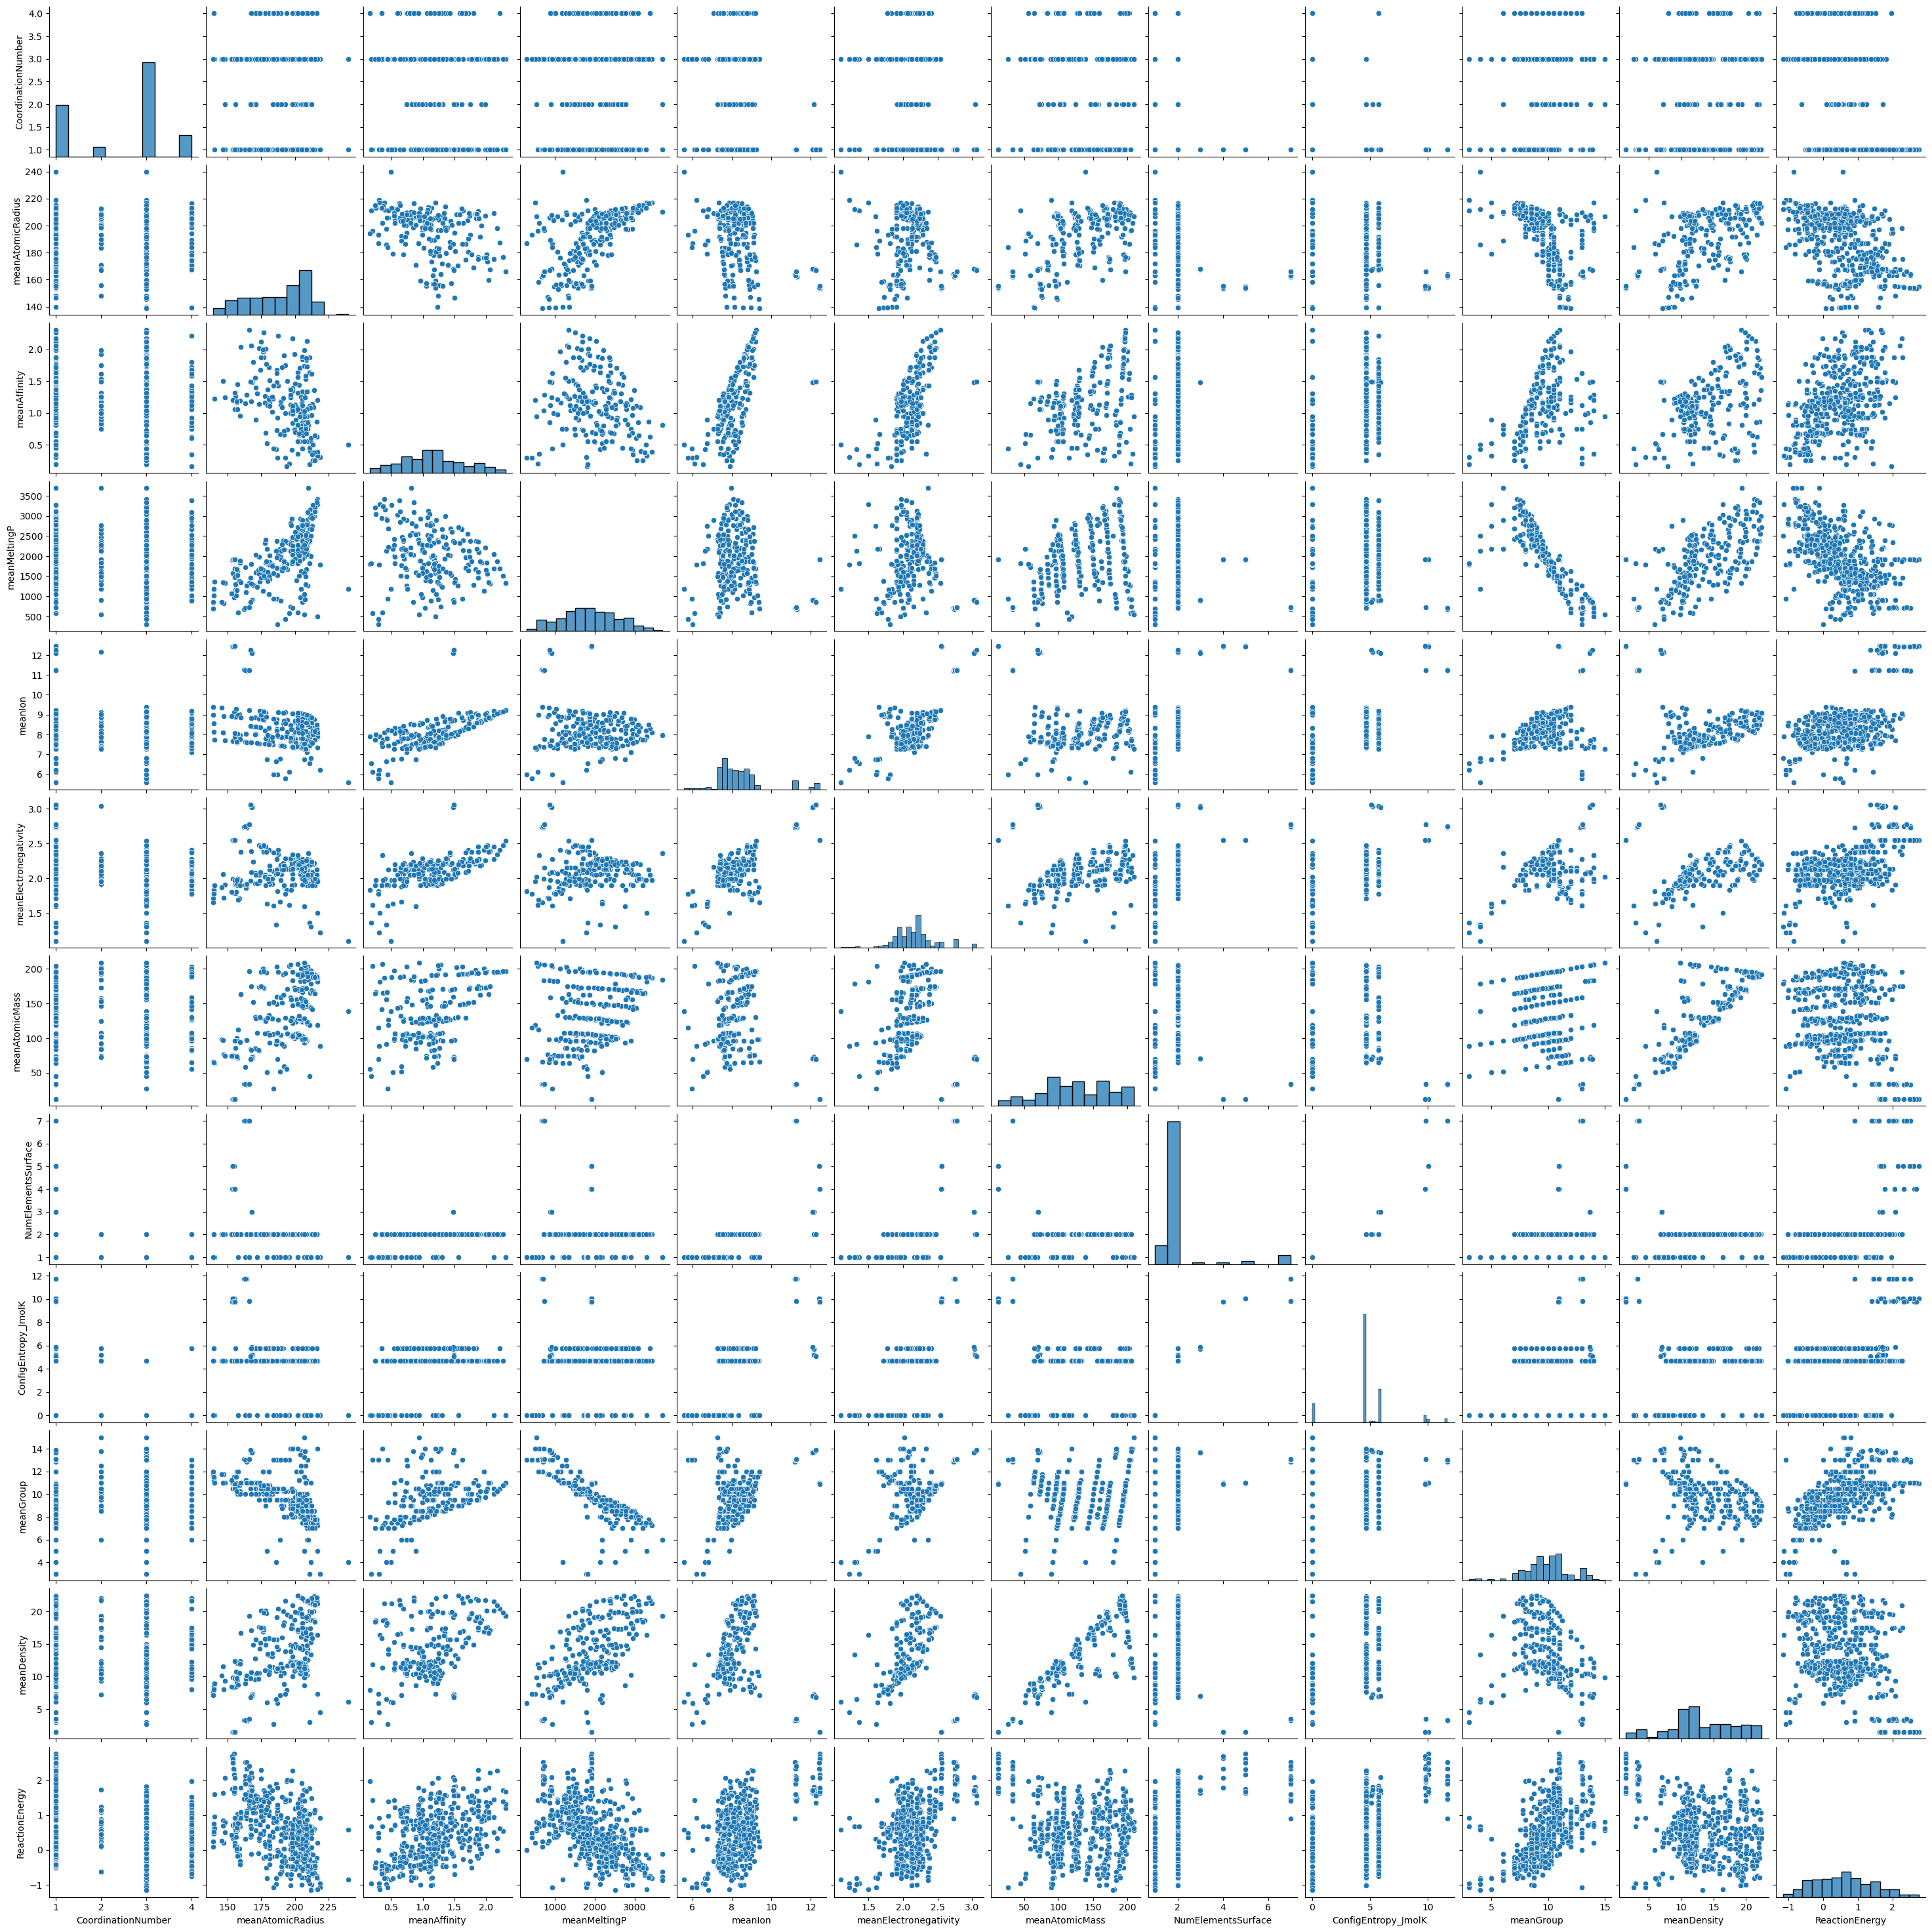

In [37]:
g = sns.pairplot(train_fixed[["CoordinationNumber","meanAtomicRadius", "meanAffinity", "meanMeltingP", 
                          "meanIon", "meanElectronegativity", "meanAtomicMass", 
                          "NumElementsSurface", "ConfigEntropy_JmolK", 'meanGroup', "meanDensity",
                          "ReactionEnergy"]])
g.savefig('PairPlot', dpi=300, bbox_inches='tight')

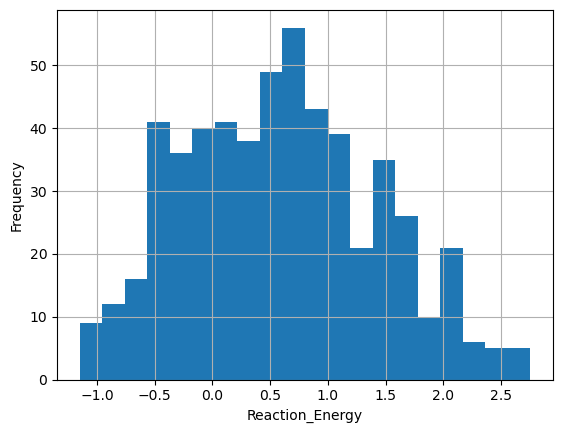

In [49]:
train_fixed['ReactionEnergy'].hist(bins=20)
plt.xlabel("Reaction_Energy")
plt.ylabel("Frequency")
plt.savefig("reaction_energy_distribution", dpi = 300)
plt.show()


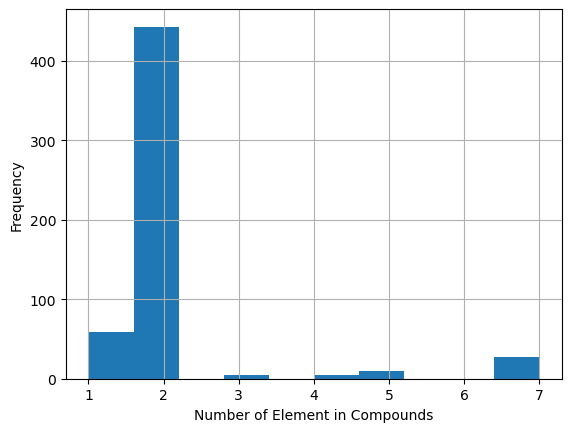

In [39]:
train_fixed['NumElementsSurface'].hist(bins=10)
plt.xlabel("Number of Element in Compounds")
plt.ylabel("Frequency")
plt.savefig("Surface Composition", dpi = 300)
plt.show()

In [40]:
train_fixed['NumElementsSurface'].value_counts()

NumElementsSurface
2    443
1     59
7     27
5     10
4      5
3      5
Name: count, dtype: int64

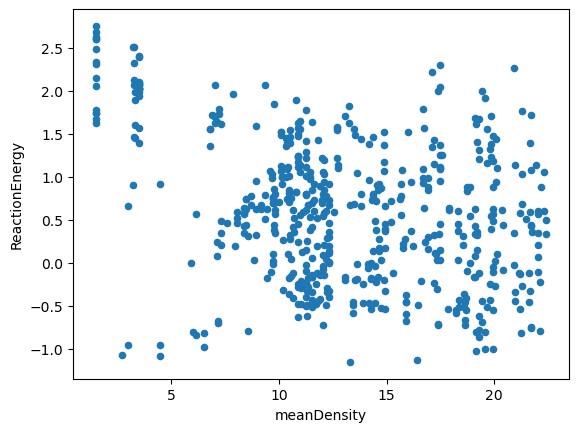

In [64]:
train_fixed.plot.scatter(x='meanDensity', y='ReactionEnergy')
plt.xlabel('meanDensity')
plt.ylabel('ReactionEnergy')
plt.savefig("Density", dpi = 300)
plt.show()

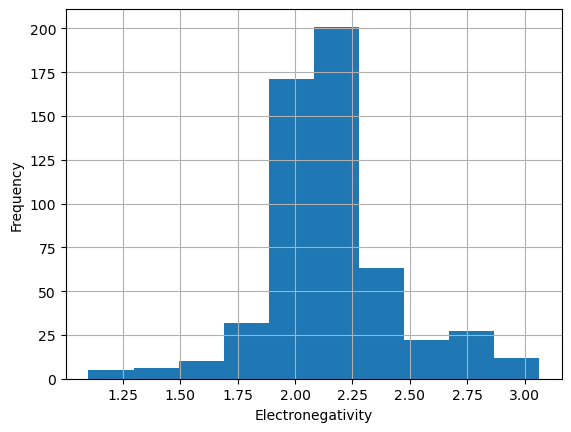

In [42]:
train_fixed['meanElectronegativity'].hist(bins=10)
plt.xlabel("Electronegativity")
plt.ylabel("Frequency")
plt.show()

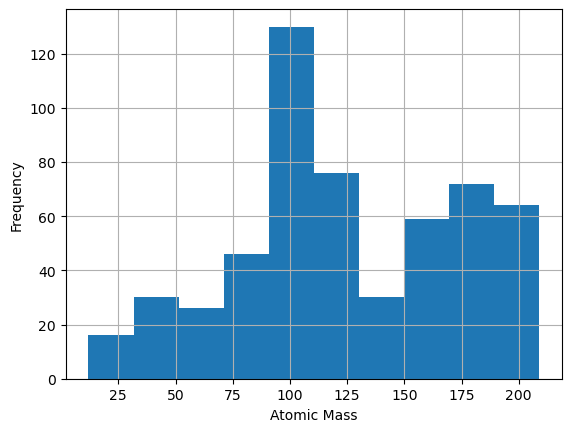

In [43]:
train_fixed['meanAtomicMass'].hist(bins=10)
plt.xlabel("Atomic Mass")
plt.ylabel("Frequency")
plt.show()

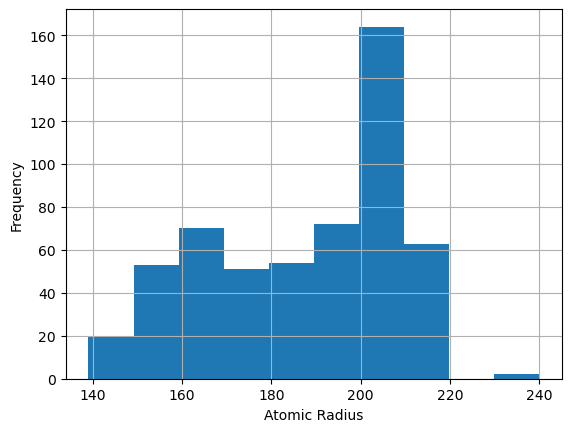

In [44]:
train_fixed['meanAtomicRadius'].hist(bins=10)
plt.xlabel("Atomic Radius")
plt.ylabel("Frequency")
plt.show()

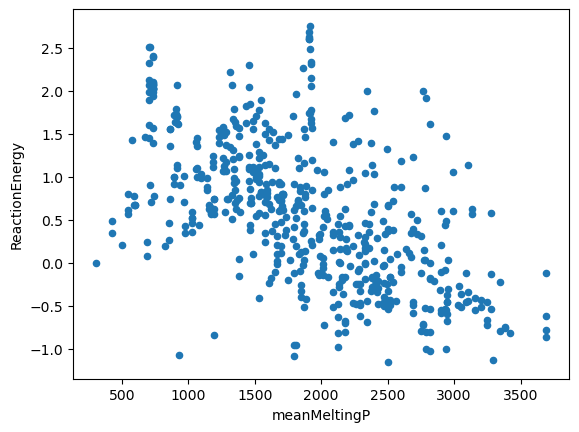

In [45]:
train_fixed.plot.scatter(x='meanMeltingP', y='ReactionEnergy')
plt.xlabel('meanMeltingP')
plt.ylabel('ReactionEnergy')
plt.savefig("MeltingP", dpi = 300)
plt.show()

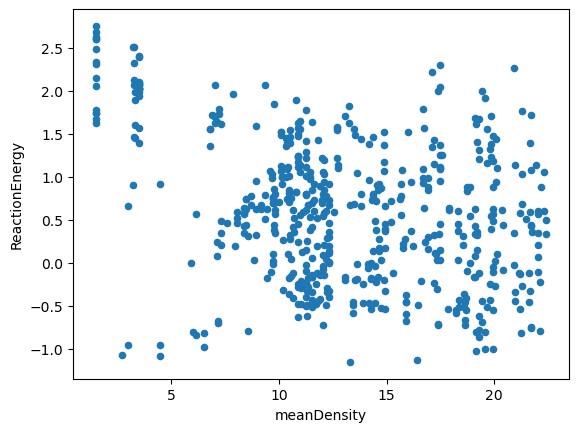

In [40]:
train_fixed.plot.scatter(x='meanDensity', y='ReactionEnergy')
plt.xlabel('meanDensity')
plt.ylabel('ReactionEnergy')
plt.savefig("Density", dpi = 300)
plt.show()

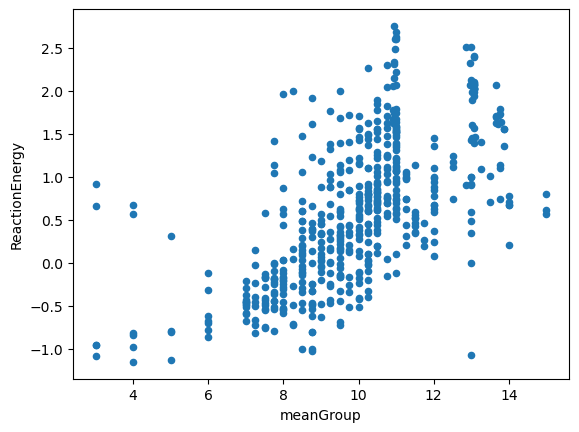

In [41]:
train_fixed.plot.scatter(x='meanGroup', y='ReactionEnergy')
plt.xlabel('meanGroup')
plt.ylabel('ReactionEnergy')
plt.savefig("Group", dpi = 300)
plt.show()

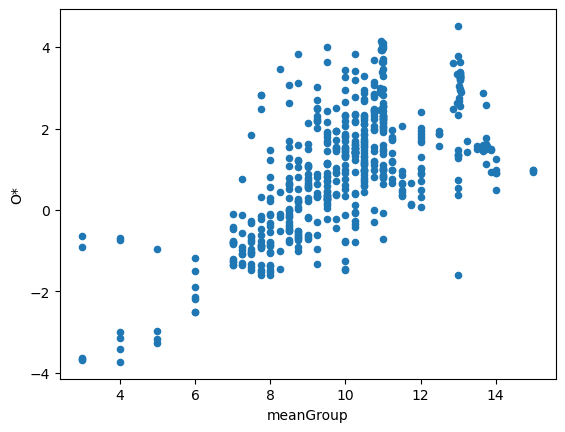

In [42]:
train_fixed.plot.scatter(x='meanGroup', y='O*_energy')
plt.xlabel('meanGroup')
plt.ylabel('O*')
plt.show()

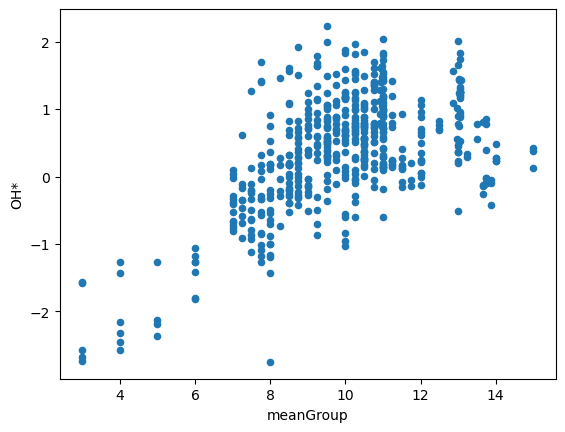

In [43]:
train_fixed.plot.scatter(x='meanGroup', y='OH*_energy')
plt.xlabel('meanGroup')
plt.ylabel('OH*')
plt.show()

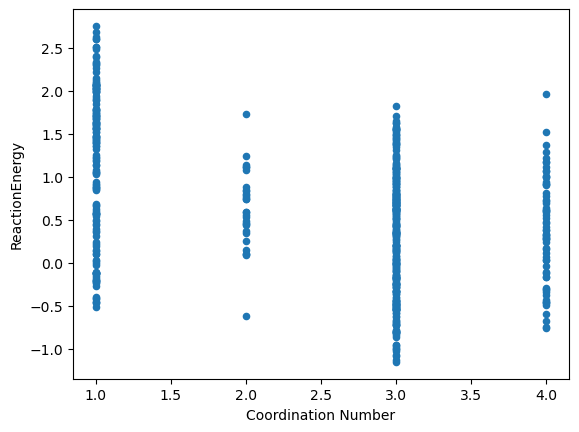

In [44]:
train_fixed.plot.scatter(x='CoordinationNumber', y='ReactionEnergy')
plt.xlabel('Coordination Number')
plt.ylabel('ReactionEnergy')
plt.savefig("Coordination Number", dpi = 300)
plt.show()

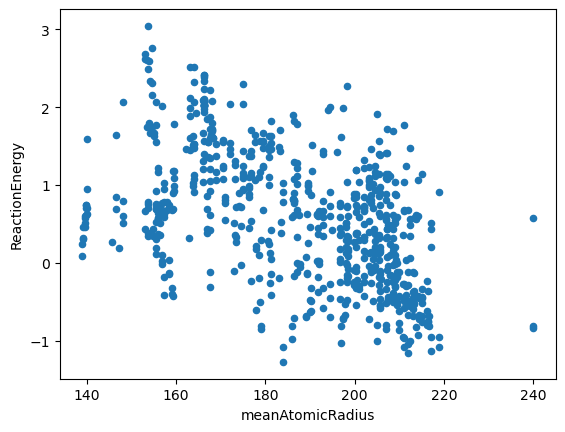

In [63]:
complete_data.plot.scatter(x='meanAtomicRadius', y='ReactionEnergy')
plt.xlabel('meanAtomicRadius')
plt.ylabel('ReactionEnergy')
plt.savefig("Atomic Radius", dpi = 300)
plt.show()

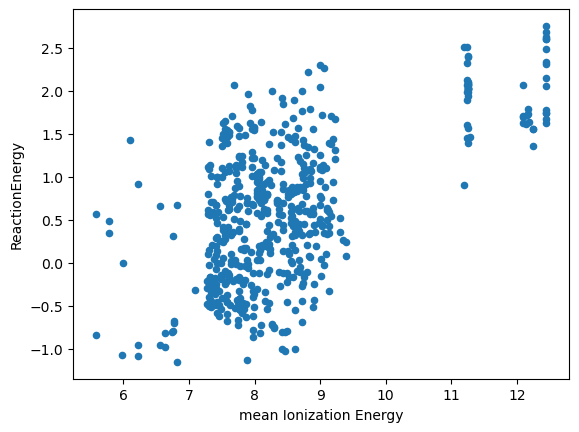

In [46]:
train_fixed.plot.scatter(x='meanIon', y='ReactionEnergy')
plt.xlabel('mean Ionization Energy')
plt.ylabel('ReactionEnergy')
plt.savefig("Ionization", dpi = 300)
plt.show()

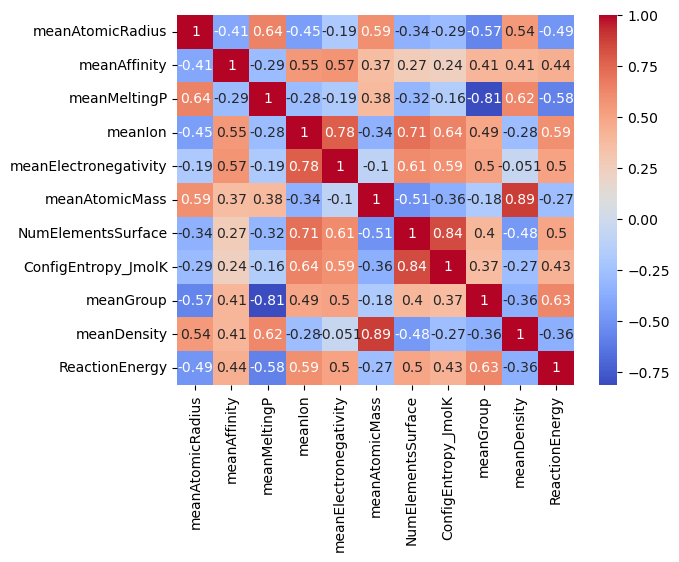

In [47]:
corr = train_fixed[["meanAtomicRadius", "meanAffinity", "meanMeltingP", 
                          "meanIon", "meanElectronegativity", "meanAtomicMass", 
                          "NumElementsSurface", "ConfigEntropy_JmolK", "meanGroup", "meanDensity",
                          "ReactionEnergy"]].corr()
heatP = sns.heatmap(corr, annot=True, cmap="coolwarm")
figure = heatP.get_figure()    
figure.savefig('correlationHeatMap.jpg', dpi=400)
plt.show()


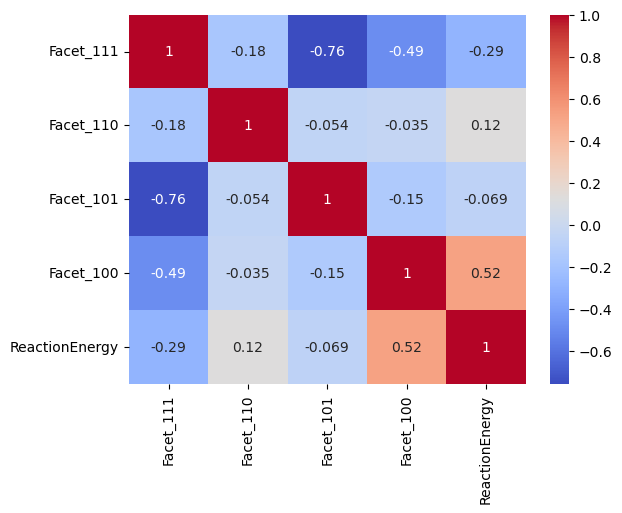

In [59]:
corr = train_fixed[["Facet_111", "Facet_110", "Facet_101", 
                          "Facet_100", 
                          "ReactionEnergy"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

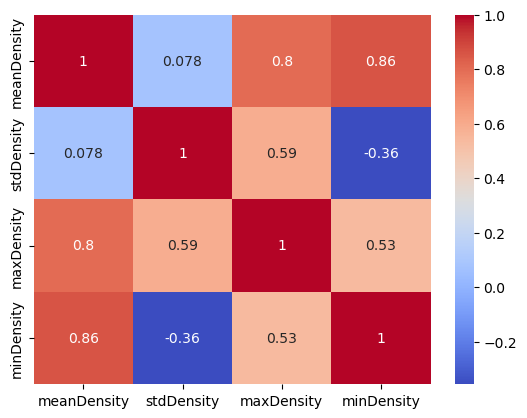

In [60]:
corr_radius = train_fixed[['meanDensity', 'stdDensity','maxDensity', 'minDensity']].corr()
sns.heatmap(corr_radius, annot=True, cmap="coolwarm")
plt.show()

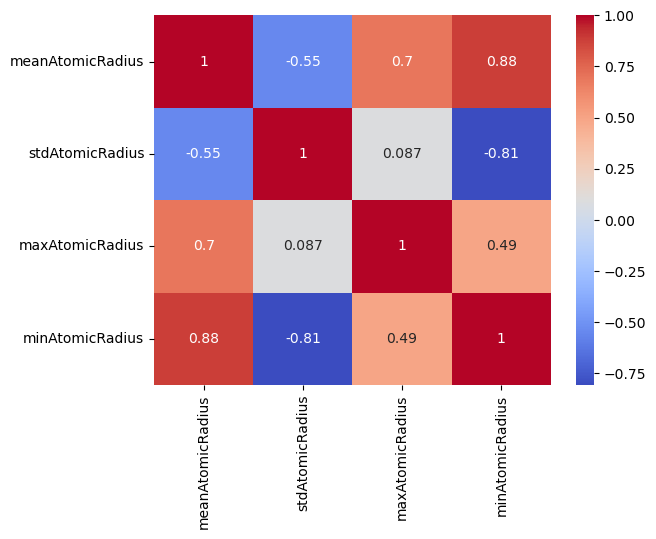

In [61]:
corr_radius = train_fixed[['meanAtomicRadius', 'stdAtomicRadius','maxAtomicRadius', 'minAtomicRadius']].corr()
sns.heatmap(corr_radius, annot=True, cmap="coolwarm")
plt.show()

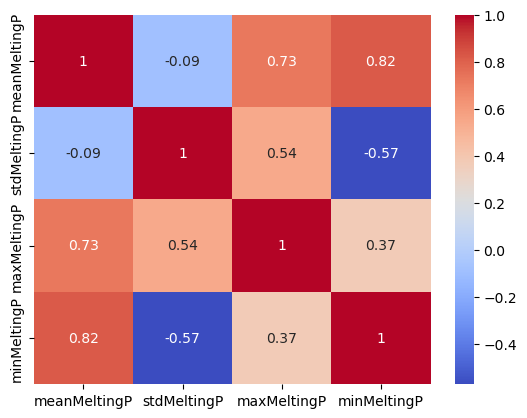

In [62]:
corr_MeltingP = train_fixed[['meanMeltingP', 'stdMeltingP','maxMeltingP', 'minMeltingP']].corr()
sns.heatmap(corr_MeltingP, annot=True, cmap="coolwarm")
plt.show()

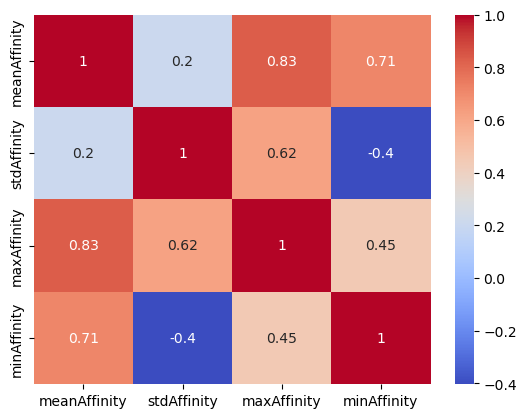

In [63]:
corr_affinity = train_fixed[['meanAffinity', 'stdAffinity','maxAffinity', 'minAffinity']].corr()
sns.heatmap(corr_affinity, annot=True, cmap="coolwarm")
plt.show()

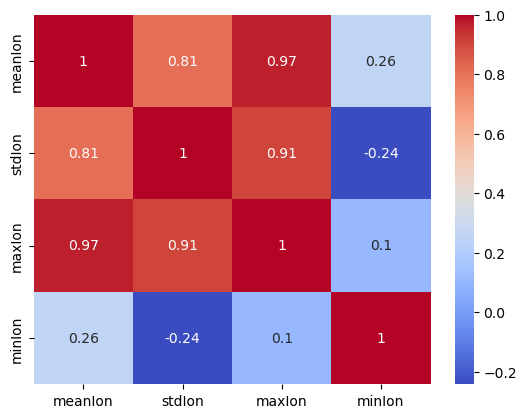

In [64]:
corr_Ion = train_fixed[['meanIon', 'stdIon','maxIon', 'minIon']].corr()
sns.heatmap(corr_Ion, annot=True, cmap="coolwarm")
plt.show()

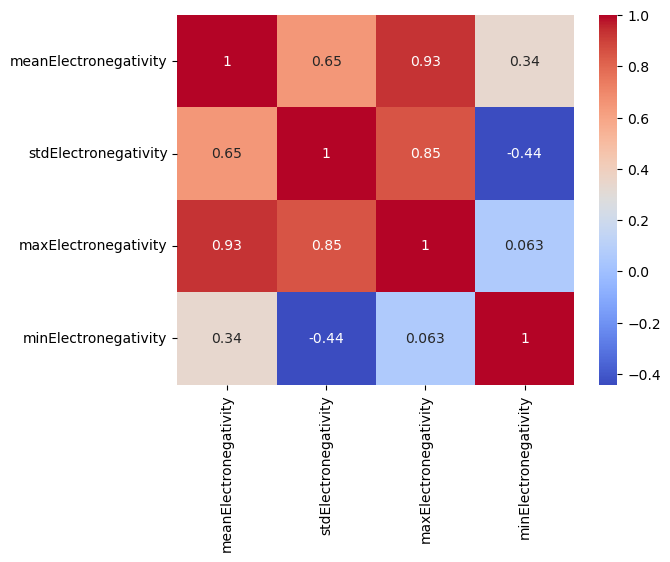

In [39]:
corr_Electronegativity = train_fixed[['meanElectronegativity', 'stdElectronegativity','maxElectronegativity', 'minElectronegativity']].corr()
sns.heatmap(corr_Electronegativity, annot=True, cmap="coolwarm")
plt.show()

In [47]:
corr_check = train_fixed[['meanGroup','CoordinationNumber', 'meanDcount', 'meanMeltingP', 'minGroup', 'maxAtomicRadius','meanAtomicRadius',     
            'minDensity', 'meanElectronegativity']].corr().abs()

high_corr_mask = (corr_check >= 0.8) & (corr_check < 1.0)

highly_correlated_columns = [col for col in high_corr_mask.columns if high_corr_mask[col].any()]

print("Columns with correlation >= 0.7 with at least one other column:")
print(highly_correlated_columns)

Columns with correlation >= 0.7 with at least one other column:
['meanGroup', 'meanDcount', 'meanMeltingP', 'minGroup']


In [48]:
print(corr_check["meanGroup"])

meanGroup                1.000000
CoordinationNumber       0.139341
meanDcount               0.254965
meanMeltingP             0.813223
minGroup                 0.427633
maxAtomicRadius          0.380326
meanAtomicRadius         0.567674
minDensity               0.416365
meanElectronegativity    0.501207
Name: meanGroup, dtype: float64


In [51]:
complete_data = pd.concat([train_fixed, test_fixed])

In [52]:
complete_data.head()

,surfaceComposition,ChemicalComposition,Site,O*_energy,OH*_energy,CoordinationNumber,NumElementsSurface,ConfigEntropy_JmolK,ReducedComposition,meanAtomicRadius,...,maxEnthalpy,minEnthalpy,stdEnthalpy,ReactionEnergy,Facet_100,Facet_101,Facet_110,Facet_111,Facet_01-12,Facet_11-20
0,Au3Bi,Au9Bi3,hollow|A_A_A|HCP,2.021316,1.135781,3.0,2,4.675254,Au3Bi,176.25,...,12.5,10.90,0.692820,0.885535,0,0,0,1,NaN,NaN
1,AgBi,Ag6Bi6,hollow|A_B_B|FCC,1.280299,0.360114,4.0,2,5.762826,AgBi,189.50,...,11.3,10.90,0.200000,0.920185,0,1,0,0,NaN,NaN
2,Cu3Zn,Cu9Zn3,hollow|A_A_A|FCC,0.981924,0.240317,3.0,2,4.675254,Cu3Zn,139.75,...,13.1,7.35,2.489823,0.741607,0,0,0,1,NaN,NaN
3,RhZn,Rh6Zn6,top|B,2.863009,1.020129,1.0,2,5.762826,RhZn,167.00,...,21.7,7.35,7.175000,1.842880,0,1,0,0,NaN,NaN
4,Rh3Ru,Rh9Ru3,hollow|A_A_B|FCC,0.265972,0.133044,3.0,2,4.675254,Rh3Ru,198.00,...,25.7,21.70,1.732051,0.132928,0,0,0,1,NaN,NaN


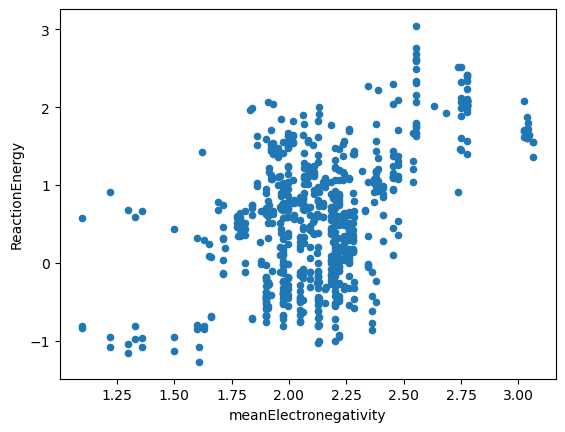

In [62]:
complete_data.plot.scatter(x='meanElectronegativity', y='ReactionEnergy')
plt.xlabel('meanElectronegativity')
plt.ylabel('ReactionEnergy')
plt.savefig("Electronegativity", dpi = 300)
plt.show()

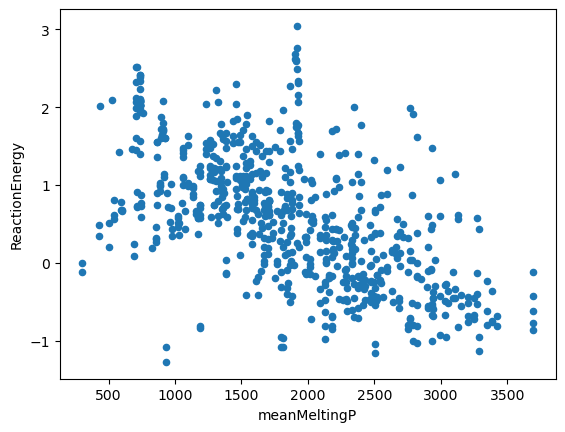

In [61]:
complete_data.plot.scatter(x='meanMeltingP', y='ReactionEnergy')
plt.xlabel('meanMeltingP')
plt.ylabel('ReactionEnergy')
plt.savefig("MeltingP", dpi = 300)
plt.show()

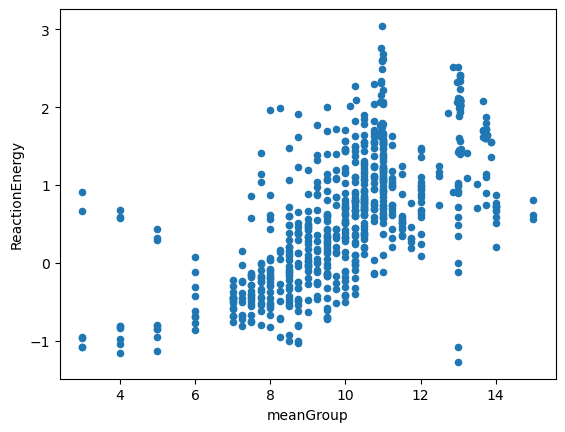

In [58]:
complete_data.plot.scatter(x='meanGroup', y='ReactionEnergy')
plt.xlabel('meanGroup')
plt.ylabel('ReactionEnergy')
plt.savefig("Group", dpi = 300)
plt.show()

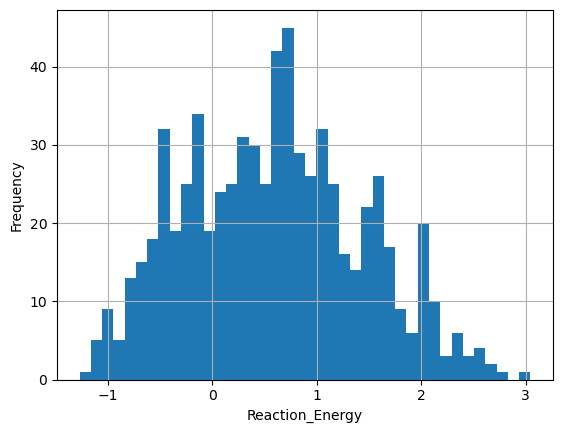

In [55]:
complete_data['ReactionEnergy'].hist(bins=40)
plt.xlabel("Reaction_Energy")
plt.ylabel("Frequency")
plt.savefig("reaction_energy_distribution", dpi = 300)
plt.show()

In [ ]:
train_fixed['meanAtomicRadius'].hist(bins=10)
plt.xlabel("Atomic Radius")
plt.ylabel("Frequency")
plt.show()

In [52]:
complete_data

,surfaceComposition,ChemicalComposition,Site,O*_energy,OH*_energy,CoordinationNumber,NumElementsSurface,ConfigEntropy_JmolK,ReducedComposition,meanAtomicRadius,...,maxEnthalpy,minEnthalpy,stdEnthalpy,ReactionEnergy,Facet_100,Facet_101,Facet_110,Facet_111,Facet_01-12,Facet_11-20
0,Au3Bi,Au9Bi3,hollow|A_A_A|HCP,2.021316,1.135781,3.0,2,4.675254,Au3Bi,176.25,...,12.5,10.90,0.692820,0.885535,0,0,0,1,NaN,NaN
1,AgBi,Ag6Bi6,hollow|A_B_B|FCC,1.280299,0.360114,4.0,2,5.762826,AgBi,189.50,...,11.3,10.90,0.200000,0.920185,0,1,0,0,NaN,NaN
2,Cu3Zn,Cu9Zn3,hollow|A_A_A|FCC,0.981924,0.240317,3.0,2,4.675254,Cu3Zn,139.75,...,13.1,7.35,2.489823,0.741607,0,0,0,1,NaN,NaN
3,RhZn,Rh6Zn6,top|B,2.863009,1.020129,1.0,2,5.762826,RhZn,167.00,...,21.7,7.35,7.175000,1.842880,0,1,0,0,NaN,NaN
4,Rh3Ru,Rh9Ru3,hollow|A_A_B|FCC,0.265972,0.133044,3.0,2,4.675254,Rh3Ru,198.00,...,25.7,21.70,1.732051,0.132928,0,0,0,1,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135,Ag3Pd,Ag9Pd3,hollow|A_A_A|HCP,2.538899,0.866356,3.0,2,4.675254,Ag3Pd,179.50,...,16.7,11.30,2.338269,1.672543,0,0,0,1,0.0,0.0
136,Cu3Tc,Cu9Tc3,hollow|A_A_B|HCP,-0.766864,-0.358038,3.0,2,4.675254,Cu3Tc,157.25,...,23.0,13.10,4.286826,-0.408827,0,0,0,1,0.0,0.0
137,Pt3Ag,Ag3Pt9,hollow|A_A_A|HCP,1.274178,1.007923,3.0,2,4.675254,AgPt3,199.75,...,20.0,11.30,3.767211,0.266255,0,0,0,1,0.0,0.0
138,Ir3Au,Au3Ir9,hollow|A_A_A|FCC,0.332023,0.904443,3.0,2,4.675254,AuIr3,193.00,...,26.0,12.50,5.845671,-0.572420,0,0,0,1,0.0,0.0


In [59]:
complete_data.drop(columns=['Facet_01-12', 'Facet_11-20']).to_csv("true_ONLY_featureData.csv")

# Linear Regression OLS

In [70]:
train_fixed.isna().sum()

surfaceComposition       0
ChemicalComposition      0
Site                     0
O*_energy                0
OH*_energy               0
CoordinationNumber       0
NumElementsSurface       0
ConfigEntropy_JmolK      0
ReducedComposition       0
meanAtomicRadius         0
maxAtomicRadius          0
minAtomicRadius          0
stdAtomicRadius          0
meanAtomicMass           0
maxAtomicMass            0
minAtomicMass            0
stdAtomicMass            0
meanAffinity             0
maxAffinity              0
minAffinity              0
stdAffinity              0
meanDensity              0
maxDensity               0
minDensity               0
stdDensity               0
meanGroup                2
maxGroup                 2
minGroup                 2
stdGroup                 2
meanMeltingP             0
maxMeltingP              0
minMeltingP              0
stdMeltingP              0
meanIon                  0
maxIon                   0
minIon                   0
stdIon                   0
m

In [71]:
train_cleaned = complete_data[['meanAtomicRadius', 'maxAtomicRadius', 'minAtomicRadius', 'stdAtomicRadius', 'CoordinationNumber',
       'NumElementsSurface', 'ConfigEntropy_JmolK', 
       'meanAtomicRadius', 'maxAtomicRadius', 'minAtomicRadius',
       'stdAtomicRadius', 'meanMeltingP', 'maxMeltingP', 'minMeltingP',
       'stdMeltingP', 'meanIon', 'maxIon', 'minIon', 'stdIon',
       'meanElectronegativity', 'maxElectronegativity', 'minElectronegativity',
       'stdElectronegativity', 'meanAtomicMass', 'maxAtomicMass',
       'minAtomicMass', 'stdAtomicMass', 'ReactionEnergy']].dropna()

X_train, X_test, y_train, y_test = train_test_split(train_cleaned.drop('ReactionEnergy', axis = 1), 
                                                    train_cleaned['ReactionEnergy'],
                                                    test_size = 0.2, 
                                                    random_state=42)

In [72]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

multi_lr = LinearRegression()
multi_lr.fit(X_train, y_train)

LinearRegression()

In [73]:
y_pred = multi_lr.predict(X_test)

# Metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
r = np.corrcoef(y_test, y_pred)[0,1]

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)
print("R:", r)

MAE: 0.39256612181562744
RMSE: 0.5134890420495614
R2: 0.6800623141196032
R: 0.8276225162683337


In [74]:
import statsmodels.api as sm

# Add constant for intercept
X_sm = sm.add_constant(X_train)
model = sm.OLS(y_train, X_sm).fit()

print(model.summary())

significant_vars = model.pvalues[model.pvalues <= 0.05]
print("Variables with p-value <= 0.05:")
print(significant_vars)

                            OLS Regression Results                            
Dep. Variable:         ReactionEnergy   R-squared:                       0.661
Model:                            OLS   Adj. R-squared:                  0.646
Method:                 Least Squares   F-statistic:                     44.48
Date:                Thu, 09 Oct 2025   Prob (F-statistic):          2.22e-107
Time:                        16:27:58   Log-Likelihood:                -377.31
No. Observations:                 548   AIC:                             802.6
Df Residuals:                     524   BIC:                             906.0
Df Model:                          23                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                     0.18

In [75]:
# Add constant for intercept
X_sm = sm.add_constant(X_test)
model = sm.OLS(y_test, X_sm).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         ReactionEnergy   R-squared:                       0.717
Model:                            OLS   Adj. R-squared:                  0.660
Method:                 Least Squares   F-statistic:                     12.46
Date:                Thu, 09 Oct 2025   Prob (F-statistic):           1.92e-21
Time:                        16:27:58   Log-Likelihood:                -94.629
No. Observations:                 137   AIC:                             237.3
Df Residuals:                     113   BIC:                             307.3
Df Model:                          23                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                     0.62

## OLS After Correlation Matrix Check

In [76]:
train_corro_checked = complete_data[['CoordinationNumber',
       'ConfigEntropy_JmolK',
       'meanAtomicRadius', 'stdAtomicRadius', 
       'meanAffinity', 'stdAffinity', 
        'meanMeltingP', 'stdMeltingP', 
         'meanIon', 'minIon',
       'meanElectronegativity', 'minElectronegativity', 'stdElectronegativity',  
        'Facet_100', 'Facet_101','Facet_110',
         'ReactionEnergy', 'maxGroup', 'meanDensity']].dropna()

X_train, X_test, y_train, y_test = train_test_split(train_corro_checked.drop('ReactionEnergy', axis = 1), 
                                                    train_corro_checked['ReactionEnergy'],
                                                    test_size = 0.2, 
                                                    random_state=42)

In [77]:
corro_lr = LinearRegression()
corro_lr.fit(X_train, y_train)

LinearRegression()

In [78]:
y_pred = corro_lr.predict(X_test)

# Metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
r = np.corrcoef(y_test, y_pred)[0,1]

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)
print("R:", r)

MAE: 0.391293317907528
RMSE: 0.5256284141540823
R2: 0.6573965446648236
R: 0.8109709973364946


In [79]:
X_sm = sm.add_constant(X_train)
model_corro = sm.OLS(y_train, X_sm).fit()

print(model_corro.summary())
significant_vars = model_corro.pvalues[model_corro.pvalues <= 0.05]
print("Variables with p-value <= 0.05:")
print(significant_vars)

                            OLS Regression Results                            
Dep. Variable:         ReactionEnergy   R-squared:                       0.646
Model:                            OLS   Adj. R-squared:                  0.633
Method:                 Least Squares   F-statistic:                     53.23
Date:                Thu, 09 Oct 2025   Prob (F-statistic):          6.57e-106
Time:                        16:28:01   Log-Likelihood:                -388.07
No. Observations:                 545   AIC:                             814.1
Df Residuals:                     526   BIC:                             895.9
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                     0.48

In [80]:
X_sm = sm.add_constant(X_test)
model_corro = sm.OLS(y_test, X_sm).fit()
print(model_corro.summary())

                            OLS Regression Results                            
Dep. Variable:         ReactionEnergy   R-squared:                       0.741
Model:                            OLS   Adj. R-squared:                  0.702
Method:                 Least Squares   F-statistic:                     18.80
Date:                Thu, 09 Oct 2025   Prob (F-statistic):           1.37e-26
Time:                        16:28:03   Log-Likelihood:                -87.006
No. Observations:                 137   AIC:                             212.0
Df Residuals:                     118   BIC:                             267.5
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                     0.86

## OLS with significant feature as previous

In [81]:
train_corro_checked = complete_data[['CoordinationNumber',
       'ConfigEntropy_JmolK',
       'meanAffinity', 
        'meanMeltingP', 
        'minIon',
       'Facet_100', 'Facet_110',  
         'ReactionEnergy']].dropna()

X_train, X_test, y_train, y_test = train_test_split(train_corro_checked.drop('ReactionEnergy', axis = 1), 
                                                    train_corro_checked['ReactionEnergy'],
                                                    test_size = 0.2, 
                                                    random_state=42)

In [82]:
sig_lr = LinearRegression()
sig_lr.fit(X_train, y_train)

LinearRegression()

In [83]:
y_pred = sig_lr.predict(X_test)

# Metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
r = np.corrcoef(y_test, y_pred)[0,1]

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)
print("R:", r)

MAE: 0.4025875494899047
RMSE: 0.5305650530391278
R2: 0.6584295275375718
R: 0.8150665256757267


In [84]:
X_sm = sm.add_constant(X_train)
model_sig = sm.OLS(y_train, X_sm).fit()

print(model_sig.summary())
significant_vars = model_sig.pvalues[model_sig.pvalues <= 0.05]
print("Variables with p-value <= 0.05:")
print(significant_vars)

                            OLS Regression Results                            
Dep. Variable:         ReactionEnergy   R-squared:                       0.626
Model:                            OLS   Adj. R-squared:                  0.621
Method:                 Least Squares   F-statistic:                     129.0
Date:                Thu, 09 Oct 2025   Prob (F-statistic):          6.46e-111
Time:                        16:28:11   Log-Likelihood:                -404.67
No. Observations:                 548   AIC:                             825.3
Df Residuals:                     540   BIC:                             859.8
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.0653    

In [85]:
X_sm = sm.add_constant(X_test)
model_sig = sm.OLS(y_test, X_sm).fit()

print(model_sig.summary())
significant_vars = model_sig.pvalues[model_sig.pvalues <= 0.05]
print("Variables with p-value <= 0.05:")
print(significant_vars)

                            OLS Regression Results                            
Dep. Variable:         ReactionEnergy   R-squared:                       0.667
Model:                            OLS   Adj. R-squared:                  0.652
Method:                 Least Squares   F-statistic:                     43.44
Date:                Thu, 09 Oct 2025   Prob (F-statistic):           8.69e-29
Time:                        16:28:12   Log-Likelihood:                -105.77
No. Observations:                 137   AIC:                             225.5
Df Residuals:                     130   BIC:                             246.0
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  -0.2613    

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1967: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])


## Linear Regression Exhaustive Feature Search

In [86]:
import itertools
from sklearn.model_selection import cross_val_score

exhaustive = complete_data[['CoordinationNumber',
       'ConfigEntropy_JmolK',
       'meanAtomicRadius', 'stdAtomicRadius', 
       'maxAffinity', 'minAffinity', 
        'meanMeltingP', 'stdMeltingP', 
         'meanIon', 'minIon',
       'meanElectronegativity', 'minElectronegativity', 'stdElectronegativity',  
        'Facet_100', 'Facet_101','Facet_110',
         'ReactionEnergy']].dropna()

X = exhaustive.drop('ReactionEnergy', axis = 1)
y = exhaustive['ReactionEnergy']

best_score = -np.inf
best_features = None

for k in range(1, len(X.columns)+1):  # subset sizes from 1 to 16
    for subset in itertools.combinations(X.columns, k):
        X_subset = X[list(subset)]
        model = LinearRegression()
        
        # Evaluate using cross-validation (5-fold)
        scores = cross_val_score(model, X_subset, y, cv=5, scoring='r2')
        mean_score = scores.mean()
        
        if mean_score > best_score:
            best_score = mean_score
            best_features = subset

print("Best features:", best_features)
print("Best CV R²:", best_score)


Best features: ('CoordinationNumber', 'ConfigEntropy_JmolK', 'meanAtomicRadius', 'stdAtomicRadius', 'maxAffinity', 'meanMeltingP', 'meanIon', 'meanElectronegativity', 'stdElectronegativity', 'Facet_101')
Best CV R²: 0.6288320174501083


# Random Forest Regression

In [53]:
complete_data.head()

,surfaceComposition,ChemicalComposition,Site,O*_energy,OH*_energy,CoordinationNumber,NumElementsSurface,ConfigEntropy_JmolK,ReducedComposition,meanAtomicRadius,...,maxEnthalpy,minEnthalpy,stdEnthalpy,ReactionEnergy,Facet_100,Facet_101,Facet_110,Facet_111,Facet_01-12,Facet_11-20
0,Au3Bi,Au9Bi3,hollow|A_A_A|HCP,2.021316,1.135781,3.0,2,4.675254,Au3Bi,176.25,...,12.5,10.90,0.692820,0.885535,0,0,0,1,NaN,NaN
1,AgBi,Ag6Bi6,hollow|A_B_B|FCC,1.280299,0.360114,4.0,2,5.762826,AgBi,189.50,...,11.3,10.90,0.200000,0.920185,0,1,0,0,NaN,NaN
2,Cu3Zn,Cu9Zn3,hollow|A_A_A|FCC,0.981924,0.240317,3.0,2,4.675254,Cu3Zn,139.75,...,13.1,7.35,2.489823,0.741607,0,0,0,1,NaN,NaN
3,RhZn,Rh6Zn6,top|B,2.863009,1.020129,1.0,2,5.762826,RhZn,167.00,...,21.7,7.35,7.175000,1.842880,0,1,0,0,NaN,NaN
4,Rh3Ru,Rh9Ru3,hollow|A_A_B|FCC,0.265972,0.133044,3.0,2,4.675254,Rh3Ru,198.00,...,25.7,21.70,1.732051,0.132928,0,0,0,1,NaN,NaN


In [54]:
complete_data.columns

Index(['surfaceComposition', 'ChemicalComposition', 'Site', 'O*_energy',
       'OH*_energy', 'CoordinationNumber', 'NumElementsSurface',
       'ConfigEntropy_JmolK', 'ReducedComposition', 'meanAtomicRadius',
       'maxAtomicRadius', 'minAtomicRadius', 'stdAtomicRadius',
       'meanAtomicMass', 'maxAtomicMass', 'minAtomicMass', 'stdAtomicMass',
       'meanPcount', 'maxPcount', 'minPcount', 'stdPcount', 'meanDcount',
       'maxDcount', 'minDcount', 'stdDcount', 'meanAffinity', 'maxAffinity',
       'minAffinity', 'stdAffinity', 'meanDensity', 'maxDensity', 'minDensity',
       'stdDensity', 'meanGroup', 'maxGroup', 'minGroup', 'stdGroup',
       'meanMeltingP', 'maxMeltingP', 'minMeltingP', 'stdMeltingP', 'meanIon',
       'maxIon', 'minIon', 'stdIon', 'meanElectronegativity',
       'maxElectronegativity', 'minElectronegativity', 'stdElectronegativity',
       'meanEnthalpy', 'maxEnthalpy', 'minEnthalpy', 'stdEnthalpy',
       'ReactionEnergy', 'Facet_100', 'Facet_101', 'Facet_110

In [55]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

randomForestData = complete_data[['CoordinationNumber', 'NumElementsSurface',
       'ConfigEntropy_JmolK', 'meanAtomicRadius',
       'maxAtomicRadius', 'minAtomicRadius', 'stdAtomicRadius',
       'meanAtomicMass', 'maxAtomicMass', 'minAtomicMass', 'stdAtomicMass',
       'meanAffinity', 'maxAffinity','minAffinity', 'stdAffinity',
       'meanGroup', 'maxGroup','minGroup', 'stdGroup',
        'meanPcount', 'maxPcount','minPcount', 'stdPcount',
        'meanDcount', 'maxDcount','minDcount', 'stdDcount',
        'meanDensity', 'maxDensity','minDensity', 'stdDensity',
       'meanMeltingP', 'maxMeltingP', 'minMeltingP', 'stdMeltingP', 'meanIon',
       'maxIon', 'minIon', 'stdIon', 'meanElectronegativity',
       'maxElectronegativity', 'minElectronegativity', 'stdElectronegativity',"ReactionEnergy",
        'Facet_100', 'Facet_101', 'Facet_110', 'Facet_111', 'meanEnthalpy', 'maxEnthalpy', 'minEnthalpy', 'stdEnthalpy']].dropna()

X = randomForestData.drop('ReactionEnergy', axis = 1)
y = randomForestData["ReactionEnergy"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestRegressor(
    n_estimators=500,      
    max_depth=None,        
    min_samples_split=2,   
    min_samples_leaf=1,    
    max_features=1.0,   
    random_state=42,
    n_jobs=-1              
)


rf.fit(X_train, y_train)


y_pred = rf.predict(X_test)


mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Random Forest Performance:")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)


Random Forest Performance:
MAE: 0.2596272934092227
RMSE: 0.353028456555981
R2: 0.7868659540870024


meanGroup                0.354372
CoordinationNumber       0.141178
meanEnthalpy             0.082744
meanDcount               0.053939
meanMeltingP             0.050147
meanAffinity             0.020295
meanIon                  0.018465
maxDensity               0.018433
minAffinity              0.016565
meanDensity              0.016081
meanAtomicRadius         0.014408
maxMeltingP              0.012903
meanElectronegativity    0.011966
maxAffinity              0.011946
stdEnthalpy              0.011690
meanAtomicMass           0.010426
stdDcount                0.009820
minDensity               0.009742
stdAffinity              0.009359
stdMeltingP              0.009134
stdAtomicRadius          0.009115
minGroup                 0.007815
minDcount                0.007430
stdDensity               0.007399
maxDcount                0.006754
maxEnthalpy              0.006280
maxAtomicRadius          0.006244
stdIon                   0.006030
stdAtomicMass            0.005902
maxIon        

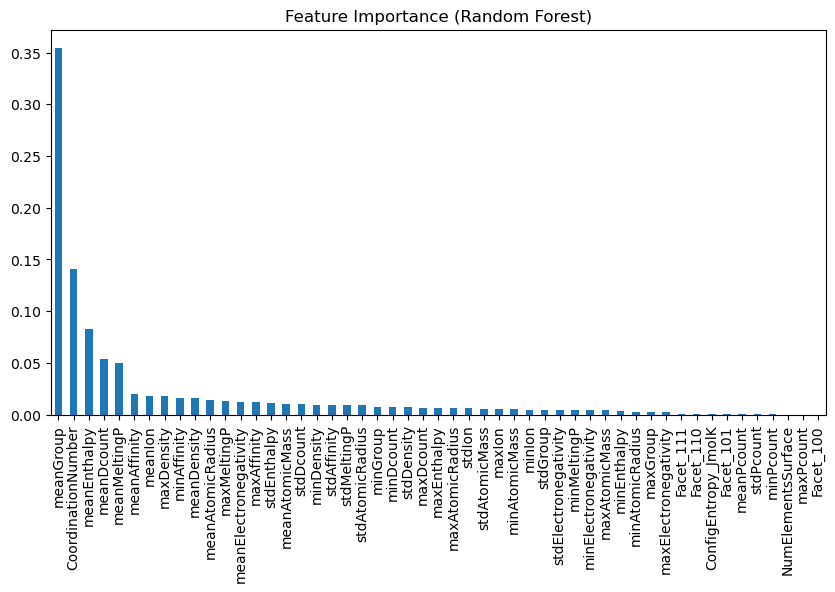

In [56]:
feat_importances = pd.Series(rf.feature_importances_, index=X.columns)
feat_importances = feat_importances.sort_values(ascending=False)
print(feat_importances)

feat_importances.plot(kind='bar', figsize=(10,5))
plt.title("Feature Importance (Random Forest)")
plt.show()

## Recursive Feature Elimation 

====== Cross-Validated Results ======
Mean Train R²:  0.9125 ± 0.0015
Mean Test  R²:  0.6731 ± 0.0431
Mean Test  MAE: 0.3082 ± 0.0329
Mean Test  RMSE:0.4321 ± 0.0428

===== Top 15 Important Features =====
CoordinationNumber       0.157455
meanGroup                0.094319
meanMeltingP             0.082666
meanEnthalpy             0.079088
meanDcount               0.070613
minDcount                0.032806
maxGroup                 0.030146
meanAtomicRadius         0.029464
meanAffinity             0.025843
minEnthalpy              0.025432
minMeltingP              0.024759
minGroup                 0.022762
meanIon                  0.021952
meanElectronegativity    0.021528
maxAffinity              0.017422
dtype: float64


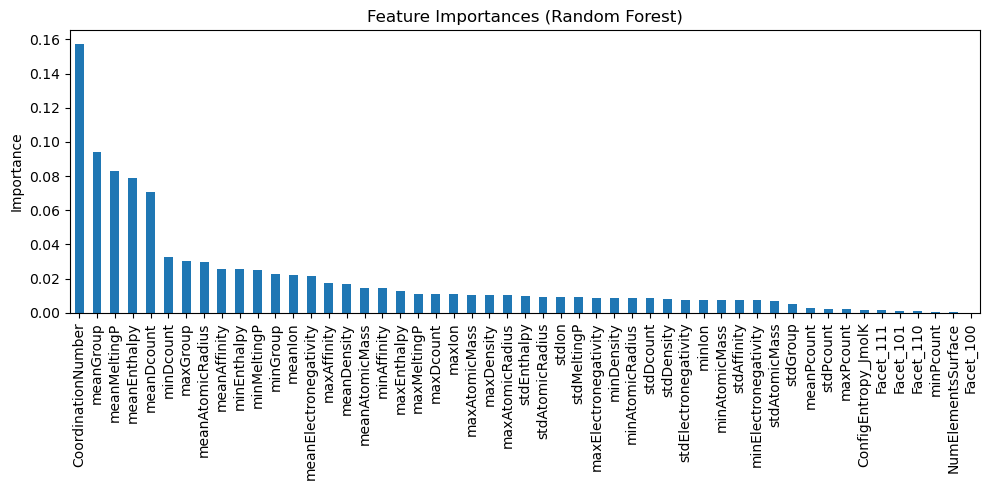

In [57]:
from sklearn.feature_selection import RFECV
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold

X = randomForestData.drop('ReactionEnergy', axis = 1)
y = randomForestData["ReactionEnergy"]

rf = RandomForestRegressor(
    n_estimators=500, 
    max_depth= None,
    min_samples_split=2,   
    min_samples_leaf=1,    
    max_features= 'sqrt',   
    random_state=42,
    n_jobs=-1     
)

cv = KFold(n_splits=5, shuffle=True, random_state=42)


# Define scoring metrics
scoring = {
    'R2': make_scorer(r2_score),
    'MAE': make_scorer(mean_absolute_error),
    'RMSE': make_scorer(lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)))
}

# Perform cross-validation
cv_results = cross_validate(rf, X, y, cv=cv, scoring=scoring, return_train_score=True)

# Print results
print("====== Cross-Validated Results ======")
print(f"Mean Train R²:  {cv_results['train_R2'].mean():.4f} ± {cv_results['train_R2'].std():.4f}")
print(f"Mean Test  R²:  {cv_results['test_R2'].mean():.4f} ± {cv_results['test_R2'].std():.4f}")
print(f"Mean Test  MAE: {cv_results['test_MAE'].mean():.4f} ± {cv_results['test_MAE'].std():.4f}")
print(f"Mean Test  RMSE:{cv_results['test_RMSE'].mean():.4f} ± {cv_results['test_RMSE'].std():.4f}")



# Fit once on the full dataset for feature importance extraction
rf.fit(X, y)

# Compute feature importances
feat_importances = pd.Series(rf.feature_importances_, index=X.columns)
feat_importances = feat_importances.sort_values(ascending=False)

# Print the top 10 most important features
print()
print("===== Top 15 Important Features =====")
print(feat_importances.head(15))

# Plot
plt.figure(figsize=(10,5))
feat_importances.plot(kind='bar')
plt.title("Feature Importances (Random Forest)")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

====== Cross-Validated Results ======
Mean Train R²:  0.9404 ± 0.0015
Mean Test  R²:  0.7937 ± 0.0209
Mean Test  MAE: 0.2706 ± 0.0136
Mean Test  RMSE:0.3819 ± 0.0202

===== Top Important Features =====
meanGroup             0.212592
meanMeltingP          0.149830
minMeltingP           0.134765
CoordinationNumber    0.127109
meanDcount            0.098891
minDcount             0.096085
meanAtomicRadius      0.081489
maxGroup              0.051784
minGroup              0.047455
dtype: float64


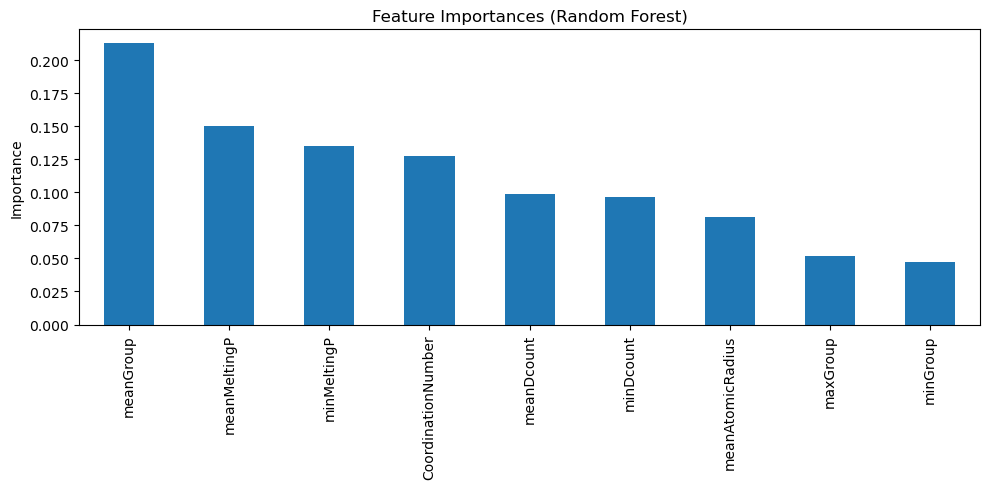

In [58]:
'''CoordinationNumber      0.1575
meanGroup               0.0968
meanMeltingP            0.0945
meanDcount              0.0739
minDcount               0.0382
meanAffinity            0.0374
maxGroup                0.0371
minMeltingP             0.0369
meanAtomicRadius        0.0343
minGroup                0.0319'''


filtered = complete_data[['CoordinationNumber', 'meanAtomicRadius', 
                          'meanDcount', 'minDcount',
                          'meanGroup', 'minGroup', 'maxGroup',
                           'meanMeltingP', 'minMeltingP', 
                          'ReactionEnergy']].dropna()

X = filtered.drop('ReactionEnergy', axis = 1)
y = filtered["ReactionEnergy"]

rf = RandomForestRegressor(
    n_estimators=500,      
    max_depth=None,        
    min_samples_split=2,   
    min_samples_leaf=1,    
    max_features='sqrt',   
    random_state=42,
    n_jobs=-1              
)


cv = KFold(n_splits=5, shuffle=True, random_state=42)


# Define scoring metrics
scoring = {
    'R2': make_scorer(r2_score),
    'MAE': make_scorer(mean_absolute_error),
    'RMSE': make_scorer(lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)))
}

# Perform cross-validation
cv_results = cross_validate(rf, X, y, cv=cv, scoring=scoring, return_train_score=True)

# Print results
print("====== Cross-Validated Results ======")
print(f"Mean Train R²:  {cv_results['train_R2'].mean():.4f} ± {cv_results['train_R2'].std():.4f}")
print(f"Mean Test  R²:  {cv_results['test_R2'].mean():.4f} ± {cv_results['test_R2'].std():.4f}")
print(f"Mean Test  MAE: {cv_results['test_MAE'].mean():.4f} ± {cv_results['test_MAE'].std():.4f}")
print(f"Mean Test  RMSE:{cv_results['test_RMSE'].mean():.4f} ± {cv_results['test_RMSE'].std():.4f}")



# Fit once on the full dataset for feature importance extraction
rf.fit(X, y)

# Compute feature importances
feat_importances = pd.Series(rf.feature_importances_, index=X.columns)
feat_importances = feat_importances.sort_values(ascending=False)

# Print the top 10 most important features
print()
print("===== Top Important Features =====")
print(feat_importances.head(15))

# Plot
plt.figure(figsize=(10,5))
feat_importances.plot(kind='bar')
plt.title("Feature Importances (Random Forest)")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

====== Cross-Validated Results ======
Mean Train R²:  0.9409 ± 0.0013
Mean Test  R²:  0.7941 ± 0.0191
Mean Test  MAE: 0.2701 ± 0.0145
Mean Test  RMSE:0.3816 ± 0.0171

===== Top Important Features =====
meanGroup             0.202384
meanMeltingP          0.155565
minMeltingP           0.136323
CoordinationNumber    0.134465
meanDcount            0.108476
minDcount             0.095967
maxGroup              0.055271
minGroup              0.046408
maxMeltingP           0.038766
maxDcount             0.026374
dtype: float64


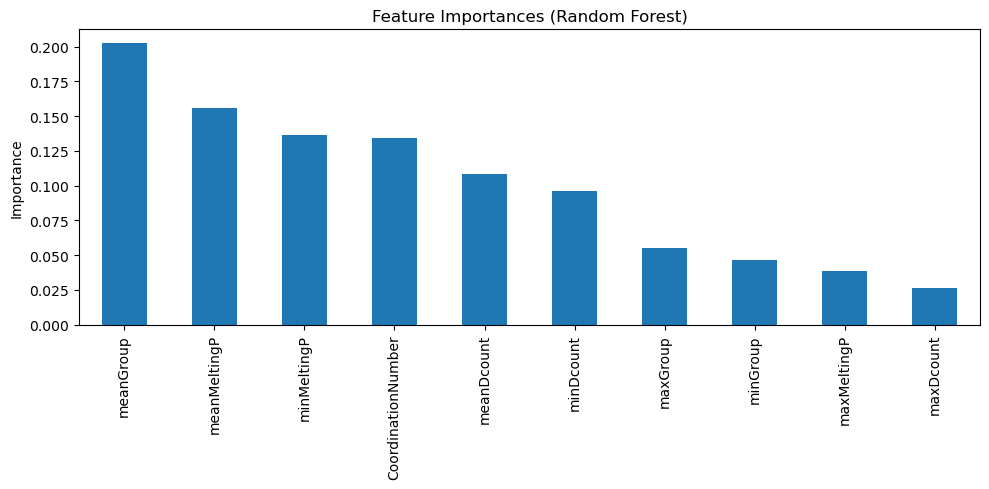

In [59]:
filtered = complete_data[['CoordinationNumber', 'meanGroup',
                               'meanDcount', 'meanMeltingP', 'minGroup', 'minDcount', 'minMeltingP',
                               'maxGroup', 'maxDcount','maxMeltingP', 
                                'ReactionEnergy']].dropna()

X = filtered.drop('ReactionEnergy', axis = 1)
y = filtered["ReactionEnergy"]

rf = RandomForestRegressor(
    n_estimators=500,      
    max_depth=None,        
    min_samples_split=2,   
    min_samples_leaf=1,    
    max_features='sqrt',   
    random_state=42,
    n_jobs=-1              
)


cv = KFold(n_splits=5, shuffle=True, random_state=42)


# Define scoring metrics
scoring = {
    'R2': make_scorer(r2_score),
    'MAE': make_scorer(mean_absolute_error),
    'RMSE': make_scorer(lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)))
}

# Perform cross-validation
cv_results = cross_validate(rf, X, y, cv=cv, scoring=scoring, return_train_score=True)

# Print results
print("====== Cross-Validated Results ======")
print(f"Mean Train R²:  {cv_results['train_R2'].mean():.4f} ± {cv_results['train_R2'].std():.4f}")
print(f"Mean Test  R²:  {cv_results['test_R2'].mean():.4f} ± {cv_results['test_R2'].std():.4f}")
print(f"Mean Test  MAE: {cv_results['test_MAE'].mean():.4f} ± {cv_results['test_MAE'].std():.4f}")
print(f"Mean Test  RMSE:{cv_results['test_RMSE'].mean():.4f} ± {cv_results['test_RMSE'].std():.4f}")



# Fit once on the full dataset for feature importance extraction
rf.fit(X, y)

# Compute feature importances
feat_importances = pd.Series(rf.feature_importances_, index=X.columns)
feat_importances = feat_importances.sort_values(ascending=False)

# Print the top 10 most important features
print()
print("===== Top Important Features =====")
print(feat_importances.head(15))

# Plot
plt.figure(figsize=(10,5))
feat_importances.plot(kind='bar')
plt.title("Feature Importances (Random Forest)")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

In [60]:
from collections import defaultdict
from tqdm import tqdm 
X = randomForestData.drop('ReactionEnergy', axis = 1)
y = randomForestData["ReactionEnergy"]

# --- parameters ---
n_runs = 10
cv_folds = 5
random_state_master = 42            # reproducible set of seeds
seeds = np.random.RandomState(random_state_master).randint(0, 10000, size=n_runs)

rf_params = dict(
    n_estimators=300,
    max_depth=10,
    max_features=1.0,
    n_jobs=-1
)

feature_names = list(X.columns)

# --- containers for aggregated results ---
# store importances per run for each feature (np.nan when not selected in that run)
all_importances = {f: [] for f in feature_names}
# store importances only when selected (for mean/std when selected)
imp_when_selected = defaultdict(list)
# store CV-R2 per run for each feature when it was selected
cv_r2_when_selected = defaultdict(list)
# selection counts
selection_count = {f: 0 for f in feature_names}

# optional: store overall run CV-R2 (for debugging)
overall_run_cv_scores = []

for seed in tqdm(seeds, desc="Running RFECV over seeds"):
    # 1) split (different train/test split each run)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=int(seed))

    # 2) define RF and RFECV with the run seed
    rf = RandomForestRegressor(random_state=int(seed), **rf_params)

    rfe = RFECV(
        estimator=rf,
        step=1,
        cv=KFold(cv_folds, shuffle=True, random_state=int(seed)),
        scoring='r2',
        n_jobs=-1
    )

    # 3) fit RFECV on the training set
    rfe.fit(X_train, y_train)

    # 4) selected features in this run
    selected_mask = rfe.support_
    selected_features = [f for f, m in zip(feature_names, selected_mask) if m]

    # 5) compute a stable CV-R2 for the selected subset (explicit cross_val_score)
    if len(selected_features) > 0:
        cv_score = cross_val_score(
            RandomForestRegressor(random_state=int(seed), **rf_params),
            X_train[selected_features],
            y_train,
            cv=KFold(cv_folds, shuffle=True, random_state=int(seed)),
            scoring='r2',
            n_jobs=-1
        ).mean()
    else:
        cv_score = np.nan

    overall_run_cv_scores.append(cv_score)

    # 6) train RF on full training set using selected features to get importances
    if len(selected_features) > 0:
        rf_full = RandomForestRegressor(random_state=int(seed), **rf_params)
        rf_full.fit(X_train[selected_features], y_train)
        imps = rf_full.feature_importances_
        imp_map = dict(zip(selected_features, imps))
    else:
        imp_map = {}

    # 7) record importances and CV-R2 per feature
    for f in feature_names:
        if f in imp_map:
            val = float(imp_map[f])
            all_importances[f].append(val)          # numerical importance for this run
            imp_when_selected[f].append(val)       # list only for selected runs
            cv_r2_when_selected[f].append(cv_score) # CV-R2 for this run where f was selected
            selection_count[f] += 1
        else:
            all_importances[f].append(np.nan)      # not selected in this run

# === Aggregate into a DataFrame ===
rows = []
for f in feature_names:
    sel_count = selection_count[f]
    sel_freq = sel_count / n_runs

    # mean/std of importance when the feature was selected (ignore runs where not selected)
    if sel_count > 0:
        mean_imp_sel = float(np.nanmean(imp_when_selected[f]))
        std_imp_sel = float(np.nanstd(imp_when_selected[f], ddof=0))
    else:
        mean_imp_sel = 0.0
        std_imp_sel = 0.0

    # mean importance across all runs treating not-selected as 0 (use nan->0)
    mean_imp_allruns = float(np.nanmean(np.nan_to_num(all_importances[f], nan=0.0)))

    # CV-R2 stats for runs where this feature was selected
    if len(cv_r2_when_selected[f]) > 0:
        mean_cv_r2_sel = float(np.nanmean(cv_r2_when_selected[f]))
        std_cv_r2_sel = float(np.nanstd(cv_r2_when_selected[f], ddof=0))
    else:
        mean_cv_r2_sel = np.nan
        std_cv_r2_sel = np.nan

    rows.append({
        "Feature": f,
        "SelectionCount": sel_count,
        "SelectionFreq": sel_freq,
        "MeanImportance_whenSelected": mean_imp_sel,
        "StdImportance_whenSelected": std_imp_sel,
        "MeanImportance_allRuns_asZeroIfNotSelected": mean_imp_allruns,
        "MeanCVR2_whenSelected": mean_cv_r2_sel,
        "StdCVR2_whenSelected": std_cv_r2_sel
    })

results_df = pd.DataFrame(rows).sort_values(by="SelectionCount", ascending=False).reset_index(drop=True)

# nice display
pd.set_option("display.float_format", lambda x: f"{x:0.4f}")
print(results_df)

# optional: plot selection frequency
try:
    import matplotlib.pyplot as plt
    plt.figure(figsize=(8, max(4, len(feature_names)*0.25)))
    plt.barh(results_df['Feature'], results_df['SelectionFreq'])
    plt.gca().invert_yaxis()
    plt.xlabel('Selection frequency (out of {} runs)'.format(n_runs))
    plt.title('Feature selection stability (RFECV over multiple train/test splits)')
    plt.show()
except Exception:
    pass


Running RFECV over seeds:   0%|                          | 0/10 [00:02<?, ?it/s]


KeyboardInterrupt: 

## The variable selection count is actually contradictory to the previous RFE ... 

Cross-validated (out-of-fold) performance:
R²:   0.7644
MAE:  0.2917
RMSE: 0.4091


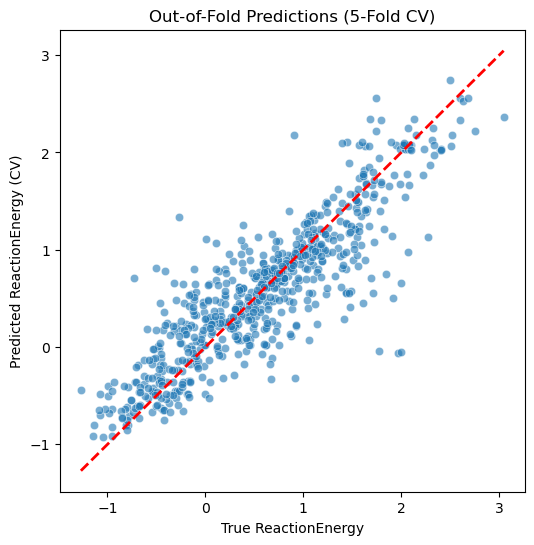

====== Cross-Validated Results ======
Mean Train R²:  0.9353 ± 0.0054
Mean Test  R²:  0.7607 ± 0.0361
Mean Test  MAE: 0.2917 ± 0.0164
Mean Test  RMSE:0.4083 ± 0.0264

===== Top 10 Important Features =====
meanGroup                0.216200
meanMeltingP             0.174090
meanElectronegativity    0.150611
CoordinationNumber       0.119282
meanIon                  0.118290
meanAtomicMass           0.069038
meanAtomicRadius         0.067489
maxMeltingP              0.045141
stdMeltingP              0.039860
dtype: float64


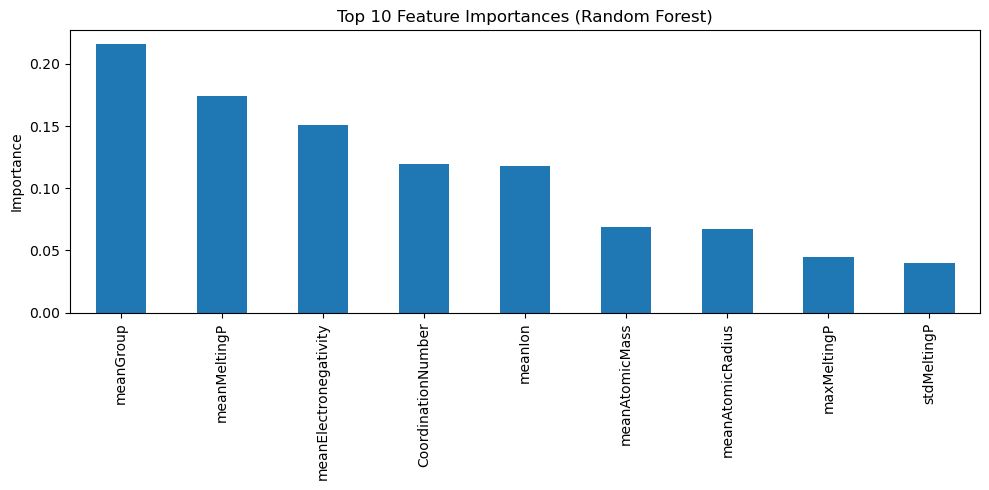

In [49]:
filtered = complete_data[['CoordinationNumber', 'meanAtomicRadius', 'meanAtomicMass', 
                          'meanGroup', 'meanMeltingP', 'maxMeltingP', 'stdMeltingP',
                          'meanIon', 'meanElectronegativity', 'ReactionEnergy']].dropna()

X = filtered.drop('ReactionEnergy', axis = 1)
y = filtered["ReactionEnergy"]

rf = RandomForestRegressor(
    n_estimators=500,      
    max_depth=None,        
    min_samples_split=2,   
    min_samples_leaf=1,    
    max_features='sqrt',   
    random_state=42,
    n_jobs=-1              
)

cv = KFold(n_splits=5, shuffle=True, random_state=42)


rf.fit(X_train, y_train)

scoring = {
    'R2': make_scorer(r2_score),
    'MAE': make_scorer(mean_absolute_error),
    'RMSE': make_scorer(lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)))
}

y_pred_oof = cross_val_predict(rf, X, y, cv=cv, n_jobs=-1) 

r2 = r2_score(y, y_pred_oof)
mae = mean_absolute_error(y, y_pred_oof)
rmse = np.sqrt(mean_squared_error(y, y_pred_oof))

print("Cross-validated (out-of-fold) performance:")
print(f"R²:   {r2:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

# Scatter plot of true vs predicted
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,6))
sns.scatterplot(x=y, y=y_pred_oof, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)  # y=x line
plt.xlabel("True ReactionEnergy")
plt.ylabel("Predicted ReactionEnergy (CV)")
plt.title("Out-of-Fold Predictions (5-Fold CV)")
plt.show()



# Perform cross-validation
cv_results = cross_validate(rf, X, y, cv=cv, scoring=scoring, return_train_score=True)

# Print results
print("====== Cross-Validated Results ======")
print(f"Mean Train R²:  {cv_results['train_R2'].mean():.4f} ± {cv_results['train_R2'].std():.4f}")
print(f"Mean Test  R²:  {cv_results['test_R2'].mean():.4f} ± {cv_results['test_R2'].std():.4f}")
print(f"Mean Test  MAE: {cv_results['test_MAE'].mean():.4f} ± {cv_results['test_MAE'].std():.4f}")
print(f"Mean Test  RMSE:{cv_results['test_RMSE'].mean():.4f} ± {cv_results['test_RMSE'].std():.4f}")



# Fit once on the full dataset for feature importance extraction
rf.fit(X, y)

# Compute feature importances
feat_importances = pd.Series(rf.feature_importances_, index=X.columns)
feat_importances = feat_importances.sort_values(ascending=False)

# Print the top 10 most important features
print()
print("===== Top 10 Important Features =====")
print(feat_importances.head(10))

# Plot
plt.figure(figsize=(10,5))
feat_importances.plot(kind='bar')
plt.title("Top 10 Feature Importances (Random Forest)")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

#0.7799

# Perhaps I should pseudo label O and OH using RF

In [61]:
complete_data.head()

,surfaceComposition,ChemicalComposition,Site,O*_energy,OH*_energy,CoordinationNumber,NumElementsSurface,ConfigEntropy_JmolK,ReducedComposition,meanAtomicRadius,...,maxEnthalpy,minEnthalpy,stdEnthalpy,ReactionEnergy,Facet_100,Facet_101,Facet_110,Facet_111,Facet_01-12,Facet_11-20
0,Au3Bi,Au9Bi3,hollow|A_A_A|HCP,2.021316,1.135781,3.0,2,4.675254,Au3Bi,176.25,...,12.5,10.90,0.692820,0.885535,0,0,0,1,NaN,NaN
1,AgBi,Ag6Bi6,hollow|A_B_B|FCC,1.280299,0.360114,4.0,2,5.762826,AgBi,189.50,...,11.3,10.90,0.200000,0.920185,0,1,0,0,NaN,NaN
2,Cu3Zn,Cu9Zn3,hollow|A_A_A|FCC,0.981924,0.240317,3.0,2,4.675254,Cu3Zn,139.75,...,13.1,7.35,2.489823,0.741607,0,0,0,1,NaN,NaN
3,RhZn,Rh6Zn6,top|B,2.863009,1.020129,1.0,2,5.762826,RhZn,167.00,...,21.7,7.35,7.175000,1.842880,0,1,0,0,NaN,NaN
4,Rh3Ru,Rh9Ru3,hollow|A_A_B|FCC,0.265972,0.133044,3.0,2,4.675254,Rh3Ru,198.00,...,25.7,21.70,1.732051,0.132928,0,0,0,1,NaN,NaN


## OH Pseudo using O* and other 

In [51]:
OH_pseudo = complete_data[['CoordinationNumber', 'NumElementsSurface',
       'ConfigEntropy_JmolK', 'meanAtomicRadius',
       'maxAtomicRadius', 'minAtomicRadius', 'stdAtomicRadius',
       'meanAtomicMass', 'maxAtomicMass', 'minAtomicMass', 'stdAtomicMass',
       'meanAffinity', 'maxAffinity','minAffinity', 'stdAffinity',
       'meanGroup', 'maxGroup','minGroup', 'stdGroup',
        'meanDensity', 'maxDensity','minDensity', 'stdDensity',
       'meanMeltingP', 'maxMeltingP', 'minMeltingP', 'stdMeltingP', 'meanIon',
       'maxIon', 'minIon', 'stdIon', 'meanElectronegativity',
       'maxElectronegativity', 'minElectronegativity', 'stdElectronegativity',
        'meanPcount','maxPcount', 'minPcount', 'stdPcount',
       'meanDcount','maxDcount', 'minDcount', 'stdDcount',
       'O*_energy','OH*_energy']].dropna()

X = OH_pseudo.drop('OH*_energy', axis = 1)
y = OH_pseudo["OH*_energy"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestRegressor(
    n_estimators=500,      
    max_depth=None,        
    min_samples_split=2,   
    min_samples_leaf=1,    
    max_features='sqrt',   
    random_state=42,
    n_jobs=-1              
)


rf.fit(X_train, y_train)



print("====== Training Data ======")

y_pred_train = rf.predict(X_train)


mae = mean_absolute_error(y_train, y_pred_train)
rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
r2 = r2_score(y_train, y_pred_train)

print("Random Forest Performance:")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)


print()
print("====== Test Data ======")
y_pred = rf.predict(X_test)


mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Random Forest Performance:")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

====== Training Data ======
Random Forest Performance:
MAE: 0.09744205636630114
RMSE: 0.13146478204972936
R2: 0.9759469702589506

====== Test Data ======
Random Forest Performance:
MAE: 0.21699700430255142
RMSE: 0.2933724237094432
R2: 0.8498630567031313


O*_energy                0.259716
meanDcount               0.067731
meanGroup                0.066939
maxDcount                0.046970
maxGroup                 0.045275
minGroup                 0.040415
meanAffinity             0.040263
CoordinationNumber       0.038083
meanElectronegativity    0.031161
meanIon                  0.029835
minDcount                0.029510
maxElectronegativity     0.028351
dtype: float64


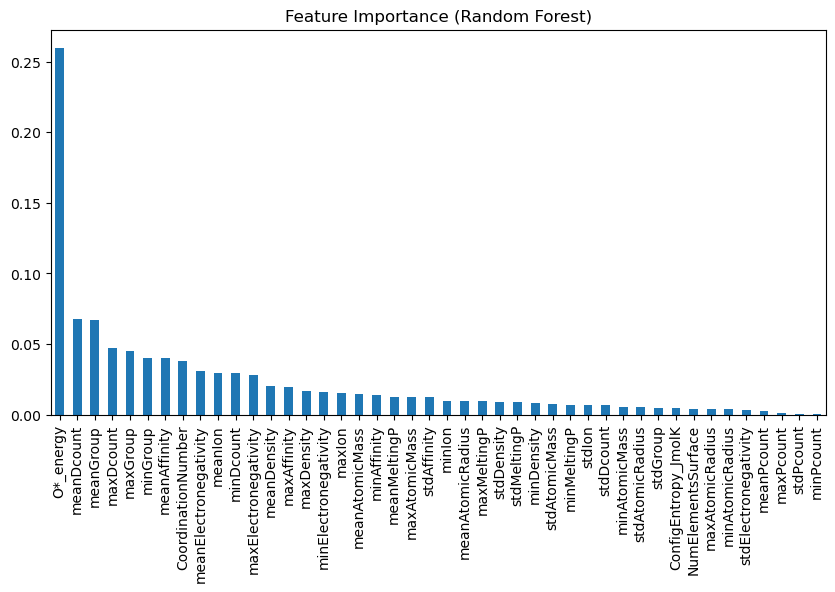

In [52]:
feat_importances = pd.Series(rf.feature_importances_, index=X.columns)
feat_importances = feat_importances.sort_values(ascending=False)
print(feat_importances.head(12))

feat_importances.plot(kind='bar', figsize=(10,5))
plt.title("Feature Importance (Random Forest)")
plt.show()

### Using more significant variable to label OH

In [53]:
OH_pseudo = complete_data[['CoordinationNumber',
       'meanAffinity', 'meanDcount', 'maxDcount','minDcount',
       'meanGroup', 'maxGroup','minGroup', 
       'meanMeltingP', 
        'meanIon',
        'meanElectronegativity', 'maxElectronegativity',
       'O*_energy','OH*_energy']].dropna()

X = OH_pseudo.drop('OH*_energy', axis = 1)
y = OH_pseudo["OH*_energy"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=25)

rf = RandomForestRegressor(
    n_estimators=500,      
    max_depth=None,        
    min_samples_split=2,   
    min_samples_leaf=1,    
    max_features='sqrt',   
    random_state=42,
    n_jobs=-1              
)


rf.fit(X_train, y_train)


print("====== Training Data ======")

y_pred_train = rf.predict(X_train)


mae = mean_absolute_error(y_train, y_pred_train)
rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
r2 = r2_score(y_train, y_pred_train)

print("Random Forest Performance:")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)


print()
print("====== Test Data ======")
y_pred = rf.predict(X_test)


mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Random Forest Performance:")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

====== Training Data ======
Random Forest Performance:
MAE: 0.07718382733465624
RMSE: 0.10702251266367303
R2: 0.9836278589678888

====== Test Data ======
Random Forest Performance:
MAE: 0.1989521067508016
RMSE: 0.2606595834121383
R2: 0.8949546369301304


### This may or may not be useful to label, the pure R2 value is actually quite high, but the MAE of 0.19 may still scale up the error

## Okay, what about now predict O* using OH* and see if it may perform better or worse

====== Cross-Validated Results ======
Mean Train R²:  0.9782 ± 0.0004
Mean Test  R²:  0.8633 ± 0.0230
Mean Test  MAE: 0.3769 ± 0.0470
Mean Test  RMSE:0.5289 ± 0.0610

===== Top 10 Important Features =====
OH*_energy            0.250737
meanGroup             0.085163
meanDcount            0.061671
minGroup              0.051210
CoordinationNumber    0.050949
minDcount             0.041990
meanMeltingP          0.032933
maxGroup              0.032879
meanAffinity          0.032795
maxDcount             0.031508
dtype: float64


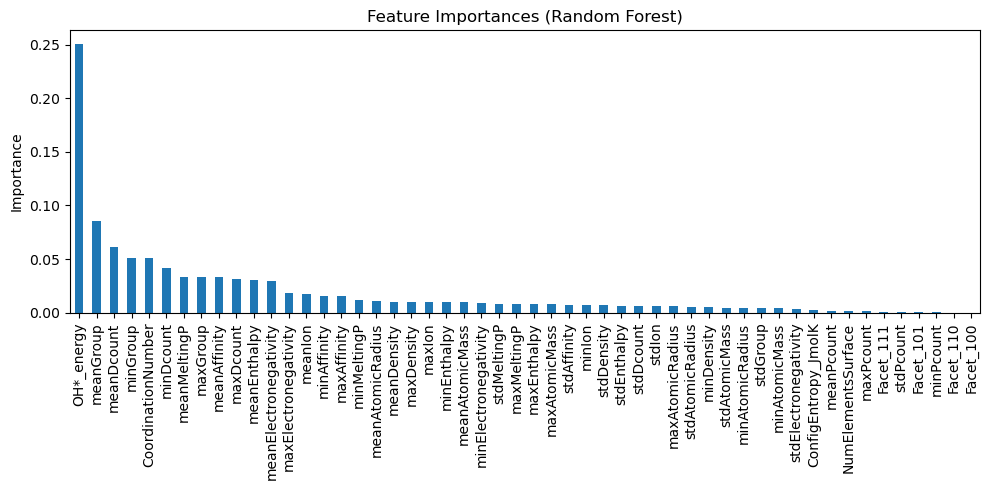

In [62]:
O_pseudo = complete_data[['CoordinationNumber', 'NumElementsSurface',
       'ConfigEntropy_JmolK', 'meanAtomicRadius',
       'maxAtomicRadius', 'minAtomicRadius', 'stdAtomicRadius',
       'meanAtomicMass', 'maxAtomicMass', 'minAtomicMass', 'stdAtomicMass',
       'meanAffinity', 'maxAffinity','minAffinity', 'stdAffinity',
       'meanGroup', 'maxGroup','minGroup', 'stdGroup',
        'meanDensity', 'maxDensity','minDensity', 'stdDensity',
       'meanMeltingP', 'maxMeltingP', 'minMeltingP', 'stdMeltingP', 'meanIon',
       'maxIon', 'minIon', 'stdIon', 'meanElectronegativity',
       'maxElectronegativity', 'minElectronegativity', 'stdElectronegativity',
        'meanPcount','maxPcount', 'minPcount', 'stdPcount',
       'meanDcount','maxDcount', 'minDcount', 'stdDcount',
        'meanEnthalpy','maxEnthalpy', 'minEnthalpy', 'stdEnthalpy',
        'Facet_100', 'Facet_101', 'Facet_110', 'Facet_111', 'O*_energy','OH*_energy']].dropna()

X = O_pseudo.drop('O*_energy', axis = 1)
y = O_pseudo["O*_energy"]


rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

# Define 5-fold cross validation
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Define scoring metrics
scoring = {
    'R2': make_scorer(r2_score),
    'MAE': make_scorer(mean_absolute_error),
    'RMSE': make_scorer(lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)))
}

# Perform cross-validation
cv_results = cross_validate(rf, X, y, cv=cv, scoring=scoring, return_train_score=True)

# Print results
print("====== Cross-Validated Results ======")
print(f"Mean Train R²:  {cv_results['train_R2'].mean():.4f} ± {cv_results['train_R2'].std():.4f}")
print(f"Mean Test  R²:  {cv_results['test_R2'].mean():.4f} ± {cv_results['test_R2'].std():.4f}")
print(f"Mean Test  MAE: {cv_results['test_MAE'].mean():.4f} ± {cv_results['test_MAE'].std():.4f}")
print(f"Mean Test  RMSE:{cv_results['test_RMSE'].mean():.4f} ± {cv_results['test_RMSE'].std():.4f}")



# Fit once on the full dataset for feature importance extraction
rf.fit(X, y)

# Compute feature importances
feat_importances = pd.Series(rf.feature_importances_, index=X.columns)
feat_importances = feat_importances.sort_values(ascending=False)

# Print the top 10 most important features
print()
print("===== Top 10 Important Features =====")
print(feat_importances.head(10))

# Plot
plt.figure(figsize=(10,5))
feat_importances.plot(kind='bar')
plt.title("Feature Importances (Random Forest)")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()



### Again, using the significant variable to pseudo-label again

====== Cross-Validated Results ======
Mean Train R²:  0.9929 ± 0.0005
Mean Test  R²:  0.9496 ± 0.0118
Mean Test  MAE: 0.2549 ± 0.0325
Mean Test  RMSE:0.3391 ± 0.0415

===== Top 10 Important Features =====
OH*_energy            0.473030
meanGroup             0.200222
meanMeltingP          0.106543
meanDcount            0.084394
minGroup              0.072849
CoordinationNumber    0.062961
dtype: float64


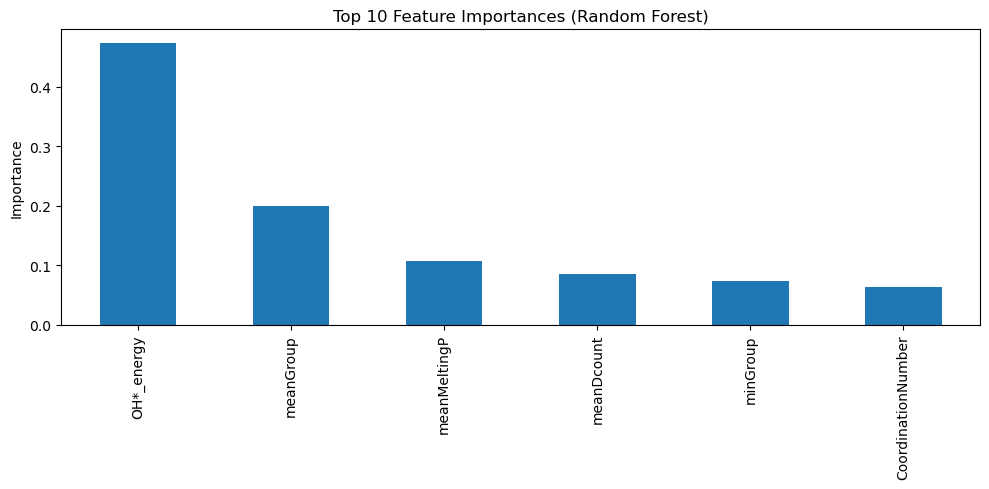

In [63]:
O_pseudo = complete_data[['CoordinationNumber', 
       'meanGroup', 'minGroup', 
        'meanDcount',
        'meanMeltingP', 
        'O*_energy','OH*_energy']].dropna()

X = O_pseudo.drop('O*_energy', axis = 1)
y = O_pseudo["O*_energy"]

rf_pseudo_pred = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

# Define 5-fold cross validation
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Define scoring metrics
scoring = {
    'R2': make_scorer(r2_score),
    'MAE': make_scorer(mean_absolute_error),
    'RMSE': make_scorer(lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)))
}

# Perform cross-validation
cv_results = cross_validate(rf_pseudo_pred, X, y, cv=cv, scoring=scoring, return_train_score=True)

# Print results
print("====== Cross-Validated Results ======")
print(f"Mean Train R²:  {cv_results['train_R2'].mean():.4f} ± {cv_results['train_R2'].std():.4f}")
print(f"Mean Test  R²:  {cv_results['test_R2'].mean():.4f} ± {cv_results['test_R2'].std():.4f}")
print(f"Mean Test  MAE: {cv_results['test_MAE'].mean():.4f} ± {cv_results['test_MAE'].std():.4f}")
print(f"Mean Test  RMSE:{cv_results['test_RMSE'].mean():.4f} ± {cv_results['test_RMSE'].std():.4f}")


# Fit once on the full dataset for feature importance extraction
rf_pseudo_pred.fit(X, y)

# Compute feature importances
feat_importances = pd.Series(rf_pseudo_pred.feature_importances_, index=X.columns)
feat_importances = feat_importances.sort_values(ascending=False)

# Print the top 10 most important features
print()
print("===== Top 10 Important Features =====")
print(feat_importances.head(10))

# Plot
plt.figure(figsize=(10,5))
feat_importances.plot(kind='bar')
plt.title("Top 10 Feature Importances (Random Forest)")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

#0.9496 ± 0.0118

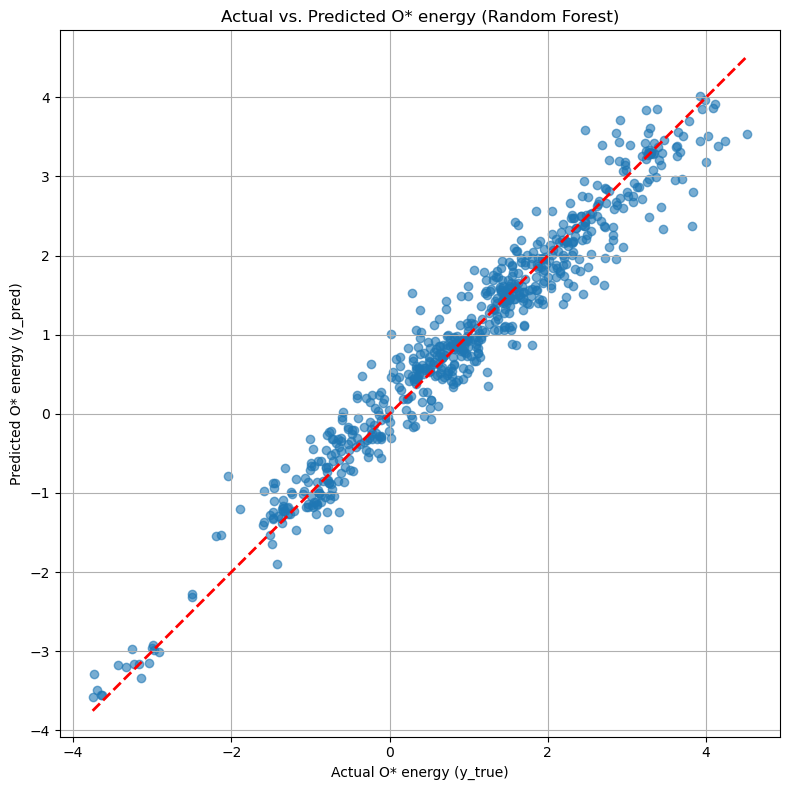

In [49]:
from sklearn.model_selection import cross_val_predict
import matplotlib.pyplot as plt

# To create a plot of actual vs. predicted values, we first need to get
# the predictions. Using cross_val_predict is a good way to get predictions
# for each data point as if it were in the test set.
y_pred = cross_val_predict(rf_pseudo_pred, X, y, cv=cv)

# Now we can create the scatter plot
plt.figure(figsize=(8, 8))
plt.scatter(y, y_pred, alpha=0.6)

# To help visualize the accuracy, it's common to plot a line representing
# perfect predictions (y_pred = y).
min_val = min(y.min(), y_pred.min())
max_val = max(y.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)

# Add labels and a title for clarity
plt.xlabel("Actual O* energy (y_true)")
plt.ylabel("Predicted O* energy (y_pred)")
plt.title("Actual vs. Predicted O* energy (Random Forest)")
plt.grid(True)
plt.axis('equal') # Ensure the x and y axes have the same scale
plt.tight_layout()

plt.savefig('pseudo_labelled_accuracy.png', dpi=500)

plt.show()

## Conclusion: 0.95 for O* Prediction, 0.90 for OH* Prediction
## Next is to label NaN O* data with OH* true label

In [64]:
pseudo_label = pd.read_csv('merged_2500_data.csv')

In [65]:
pseudo_label.head()

,surfaceComposition,Facet,ChemicalComposition,Site,O*_energy,OH*_energy
0,Ag,100,Ag64,hollow,NaN,NaN
1,Ag,111,Ag12,bridge|A_A|A,NaN,0.718151
2,Ag,111,Ag12,hollow|A_A_A|FCC,1.961800,0.563018
3,Ag,111,Ag12,hollow|A_A_A|HCP,2.050681,0.589955
4,Ag,111,Ag12,top|A,3.426808,1.387435


In [66]:
O_pseudo = pseudo_label[pseudo_label["OH*_energy"].notna()]
O_pseudo.head()

,surfaceComposition,Facet,ChemicalComposition,Site,O*_energy,OH*_energy
1,Ag,111,Ag12,bridge|A_A|A,NaN,0.718151
2,Ag,111,Ag12,hollow|A_A_A|FCC,1.961800,0.563018
3,Ag,111,Ag12,hollow|A_A_A|HCP,2.050681,0.589955
4,Ag,111,Ag12,top|A,3.426808,1.387435
9,Ag-fcc,111,Ag16,fcc,2.258668,0.718049


In [67]:
O_pseudo.columns

Index(['surfaceComposition', 'Facet', 'ChemicalComposition', 'Site',
       'O*_energy', 'OH*_energy'],
      dtype='object')

In [68]:
O_pseudo["CoordinationNumber"] = O_pseudo.apply(
    lambda row: get_coord_number(row["Site"], row["Facet"], row.get("surfaceComposition")), axis=1
)

/var/folders/db/r9nl4bjj49vbnwtt3wgg825h0000gn/T/ipykernel_67702/407028041.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  O_pseudo["CoordinationNumber"] = O_pseudo.apply(


In [69]:
O_pseudo.head()

,surfaceComposition,Facet,ChemicalComposition,Site,O*_energy,OH*_energy,CoordinationNumber
1,Ag,111,Ag12,bridge|A_A|A,NaN,0.718151,2.0
2,Ag,111,Ag12,hollow|A_A_A|FCC,1.961800,0.563018,3.0
3,Ag,111,Ag12,hollow|A_A_A|HCP,2.050681,0.589955,3.0
4,Ag,111,Ag12,top|A,3.426808,1.387435,1.0
9,Ag-fcc,111,Ag16,fcc,2.258668,0.718049,3.0


In [70]:
O_pseudo["ReducedComposition"] = O_pseudo["ChemicalComposition"].apply(reduce_formula)

/var/folders/db/r9nl4bjj49vbnwtt3wgg825h0000gn/T/ipykernel_67702/272260126.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  O_pseudo["ReducedComposition"] = O_pseudo["ChemicalComposition"].apply(reduce_formula)


In [71]:
O_pseudo.isna().sum()

surfaceComposition       0
Facet                    0
ChemicalComposition      0
Site                    17
O*_energy              726
OH*_energy               0
CoordinationNumber      18
ReducedComposition       0
dtype: int64

In [72]:
O_pseudo = O_pseudo[O_pseudo["CoordinationNumber"].notna()]
print(O_pseudo.isna().sum())

surfaceComposition       0
Facet                    0
ChemicalComposition      0
Site                     0
O*_energy              721
OH*_energy               0
CoordinationNumber       0
ReducedComposition       0
dtype: int64


In [73]:
meanRadius,maxRadius,minRadius,stdRadius = elementalPropertyMapping("AtomicRadius", O_pseudo)
O_pseudo["meanAtomicRadius"] = meanRadius
O_pseudo["maxAtomicRadius"] = maxRadius
O_pseudo["minAtomicRadius"] = minRadius
O_pseudo["stdAtomicRadius"] = stdRadius

meanMass,maxMass,minMass,stdMass = elementalPropertyMapping("AtomicMass", O_pseudo)
O_pseudo["meanAtomicMass"] = meanMass
O_pseudo["maxAtomicMass"] = maxMass
O_pseudo["minAtomicMass"] = minMass
O_pseudo["stdAtomicMass"] = stdMass

meanAffinity,maxAffinity,minAffinity,stdAffinity = elementalPropertyMapping("ElectronAffinity", O_pseudo)
O_pseudo["meanAffinity"] = meanAffinity
O_pseudo["maxAffinity"] = maxAffinity
O_pseudo["minAffinity"] = minAffinity
O_pseudo["stdAffinity"] = stdAffinity

meanDensity,maxDensity,minDensity,stdDensity = elementalPropertyMapping("Density", O_pseudo)
O_pseudo["meanDensity"] = meanDensity
O_pseudo["maxDensity"] = maxDensity
O_pseudo["minDensity"] = minDensity
O_pseudo["stdDensity"] = stdDensity

meanGroup,maxGroup,minGroup,stdGroup = elementalPropertyMapping("Group ", O_pseudo)
O_pseudo["meanGroup"] = meanGroup
O_pseudo["maxGroup"] = maxGroup
O_pseudo["minGroup"] = minGroup
O_pseudo["stdGroup"] = stdGroup

meanMT,maxMT,minMT,stdMT = elementalPropertyMapping("MeltingPoint", O_pseudo)
O_pseudo["meanMeltingP"] = meanMT
O_pseudo["maxMeltingP"] = maxMT
O_pseudo["minMeltingP"] = minMT
O_pseudo["stdMeltingP"] = stdMT

meanIon,maxIon,minIon,stdIon = elementalPropertyMapping("IonizationEnergy", O_pseudo)
O_pseudo["meanIon"] = meanIon
O_pseudo["maxIon"] = maxIon
O_pseudo["minIon"] = minIon
O_pseudo["stdIon"] = stdIon

meanElectro,maxElectro,minElectro,stdElectro = elementalPropertyMapping("Electronegativity", O_pseudo)
O_pseudo["meanElectronegativity"] = meanElectro
O_pseudo["maxElectronegativity"] = maxElectro
O_pseudo["minElectronegativity"] = minElectro
O_pseudo["stdElectronegativity"] = stdElectro

meanElectro,maxElectro,minElectro,stdElectro = elementalPropertyMapping("Electronegativity", O_pseudo)
O_pseudo["meanElectronegativity"] = meanElectro
O_pseudo["maxElectronegativity"] = maxElectro
O_pseudo["minElectronegativity"] = minElectro
O_pseudo["stdElectronegativity"] = stdElectro

meanPcount,maxPcount,minPcount,stdPcount = elementalPropertyMapping("Outermost_p_count", O_pseudo)
O_pseudo["meanPcount"] = meanPcount
O_pseudo["maxPcount"] = maxPcount
O_pseudo["minPcount"] = minPcount
O_pseudo["stdPcount"] = stdPcount

meanDcount,maxDcount,minDcount,stdDcount = elementalPropertyMapping("Outermost_d_count", O_pseudo)
O_pseudo["meanDcount"] = meanDcount
O_pseudo["maxDcount"] = maxDcount
O_pseudo["minDcount"] = minDcount
O_pseudo["stdDcount"] = stdDcount

meanEnthalpy,maxEnthalpy,minEnthalpy,stdEnthalpy = elementalPropertyMapping("EnthalpyFusion", O_pseudo)
O_pseudo["meanEnthalpy"] = meanEnthalpy
O_pseudo["maxEnthalpy"] = maxEnthalpy
O_pseudo["minEnthalpy"] = minEnthalpy 
O_pseudo["stdEnthalpy"] = stdEnthalpy

meanEnthalpy,maxEnthalpy,minEnthalpy,stdEnthalpy = elementalPropertyMapping("EnthalpyFusion", O_pseudo)
O_pseudo["meanEnthalpy"] = meanEnthalpy
O_pseudo["maxEnthalpy"] = maxEnthalpy
O_pseudo["minEnthalpy"] = minEnthalpy 
O_pseudo["stdEnthalpy"] = stdEnthalpy

In [74]:
O_pseudo.head()

,surfaceComposition,Facet,ChemicalComposition,Site,O*_energy,OH*_energy,CoordinationNumber,ReducedComposition,meanAtomicRadius,maxAtomicRadius,...,minPcount,stdPcount,meanDcount,maxDcount,minDcount,stdDcount,meanEnthalpy,maxEnthalpy,minEnthalpy,stdEnthalpy
1,Ag,111,Ag12,bridge|A_A|A,NaN,0.718151,2.0,Ag,172.0,172.0,...,0,0.0,10.0,10,10,0.0,11.3,11.3,11.3,0.0
2,Ag,111,Ag12,hollow|A_A_A|FCC,1.961800,0.563018,3.0,Ag,172.0,172.0,...,0,0.0,10.0,10,10,0.0,11.3,11.3,11.3,0.0
3,Ag,111,Ag12,hollow|A_A_A|HCP,2.050681,0.589955,3.0,Ag,172.0,172.0,...,0,0.0,10.0,10,10,0.0,11.3,11.3,11.3,0.0
4,Ag,111,Ag12,top|A,3.426808,1.387435,1.0,Ag,172.0,172.0,...,0,0.0,10.0,10,10,0.0,11.3,11.3,11.3,0.0
9,Ag-fcc,111,Ag16,fcc,2.258668,0.718049,3.0,Ag,172.0,172.0,...,0,0.0,10.0,10,10,0.0,11.3,11.3,11.3,0.0


In [75]:
O_pseudo.columns

Index(['surfaceComposition', 'Facet', 'ChemicalComposition', 'Site',
       'O*_energy', 'OH*_energy', 'CoordinationNumber', 'ReducedComposition',
       'meanAtomicRadius', 'maxAtomicRadius', 'minAtomicRadius',
       'stdAtomicRadius', 'meanAtomicMass', 'maxAtomicMass', 'minAtomicMass',
       'stdAtomicMass', 'meanAffinity', 'maxAffinity', 'minAffinity',
       'stdAffinity', 'meanDensity', 'maxDensity', 'minDensity', 'stdDensity',
       'meanGroup', 'maxGroup', 'minGroup', 'stdGroup', 'meanMeltingP',
       'maxMeltingP', 'minMeltingP', 'stdMeltingP', 'meanIon', 'maxIon',
       'minIon', 'stdIon', 'meanElectronegativity', 'maxElectronegativity',
       'minElectronegativity', 'stdElectronegativity', 'meanPcount',
       'maxPcount', 'minPcount', 'stdPcount', 'meanDcount', 'maxDcount',
       'minDcount', 'stdDcount', 'meanEnthalpy', 'maxEnthalpy', 'minEnthalpy',
       'stdEnthalpy'],
      dtype='object')

In [76]:
O_true_label = O_pseudo[O_pseudo["O*_energy"].notna()]
O_true_label = O_true_label[O_true_label["OH*_energy"].notna()]
print(O_true_label.shape)
O_true_label.head()

(685, 52)


,surfaceComposition,Facet,ChemicalComposition,Site,O*_energy,OH*_energy,CoordinationNumber,ReducedComposition,meanAtomicRadius,maxAtomicRadius,...,minPcount,stdPcount,meanDcount,maxDcount,minDcount,stdDcount,meanEnthalpy,maxEnthalpy,minEnthalpy,stdEnthalpy
2,Ag,111,Ag12,hollow|A_A_A|FCC,1.961800,0.563018,3.0,Ag,172.0,172.0,...,0,0.0,10.0,10,10,0.0,11.3,11.3,11.3,0.000000
3,Ag,111,Ag12,hollow|A_A_A|HCP,2.050681,0.589955,3.0,Ag,172.0,172.0,...,0,0.0,10.0,10,10,0.0,11.3,11.3,11.3,0.000000
4,Ag,111,Ag12,top|A,3.426808,1.387435,1.0,Ag,172.0,172.0,...,0,0.0,10.0,10,10,0.0,11.3,11.3,11.3,0.000000
9,Ag-fcc,111,Ag16,fcc,2.258668,0.718049,3.0,Ag,172.0,172.0,...,0,0.0,10.0,10,10,0.0,11.3,11.3,11.3,0.000000
26,Ag3Au,111,Ag9Au3,hollow|A_A_A|FCC,2.208363,0.660700,3.0,Ag3Au,170.5,172.0,...,0,0.0,10.0,10,10,0.0,11.6,12.5,11.3,0.519615


In [77]:
O_pseudo_pred = O_pseudo[O_pseudo["O*_energy"].isna()]
print(O_pseudo_pred.shape)
O_pseudo_pred.head()

(721, 52)


,surfaceComposition,Facet,ChemicalComposition,Site,O*_energy,OH*_energy,CoordinationNumber,ReducedComposition,meanAtomicRadius,maxAtomicRadius,...,minPcount,stdPcount,meanDcount,maxDcount,minDcount,stdDcount,meanEnthalpy,maxEnthalpy,minEnthalpy,stdEnthalpy
1,Ag,111,Ag12,bridge|A_A|A,NaN,0.718151,2.0,Ag,172.0,172.0,...,0,0.0,10.0,10,10,0.0,11.3,11.3,11.3,0.0
10,Ag-fcc,111,Ag16,hcp,NaN,0.746135,3.0,Ag,172.0,172.0,...,0,0.0,10.0,10,10,0.0,11.3,11.3,11.3,0.0
11,Ag-fcc,111,Ag16,ontop,NaN,1.571387,1.0,Ag,172.0,172.0,...,0,0.0,10.0,10,10,0.0,11.3,11.3,11.3,0.0
12,Ag-fcc,111+2%,Ag16,fcc,NaN,0.565090,3.0,Ag,172.0,172.0,...,0,0.0,10.0,10,10,0.0,11.3,11.3,11.3,0.0
13,Ag-fcc,111+5%,Ag16,fcc,NaN,0.368049,3.0,Ag,172.0,172.0,...,0,0.0,10.0,10,10,0.0,11.3,11.3,11.3,0.0


In [78]:
O_pseudo_pred_sigFeat = O_pseudo_pred[['CoordinationNumber', 
       'meanGroup', 'minGroup', 
        'meanDcount',
        'meanMeltingP', 
        'OH*_energy']]

In [79]:
O_pseudo_labelled = rf_pseudo_pred.predict(O_pseudo_pred_sigFeat)

In [80]:
print(O_pseudo_pred.shape)
print(O_pseudo_pred_sigFeat.shape)

(721, 52)
(721, 6)


In [81]:
O_pseudo_labelled

array([ 2.15404330e+00,  2.21471238e+00,  3.38677690e+00,  1.96249672e+00,
        1.42391746e+00,  9.91220790e-01,  2.19684170e+00,  2.16155429e+00,
        2.17426628e+00,  2.17538759e+00,  1.80115256e+00,  2.21261974e+00,
        2.47368022e+00,  2.28191346e+00,  2.25368795e+00,  2.87172491e+00,
        2.84334483e+00,  9.25011241e-01,  2.54199559e+00,  2.37337368e+00,
        2.33741996e+00,  1.08298428e+00,  2.00011166e+00,  2.14074601e+00,
        2.35300791e+00,  3.04684896e+00,  1.20826759e+00,  1.20292757e+00,
        1.21410761e+00,  1.61553937e+00,  1.62121701e+00,  1.75992068e+00,
        1.75406359e+00,  1.55210858e+00,  1.22712662e+00,  2.51462860e+00,
        1.36237324e+00,  2.81841061e+00,  1.64605641e+00,  1.73741013e+00,
        1.68831208e+00,  1.66803801e+00,  2.89925165e+00,  2.27212480e+00,
        2.93299574e+00, -2.77809725e-01, -9.06509308e-01,  9.24198753e-01,
        9.77461341e-01,  2.37281236e+00,  1.43961858e+00,  1.71555204e+00,
        2.09645811e-01,  

In [82]:
O_pseudo_pred["O*_energy"] = O_pseudo_labelled
print(O_pseudo_pred.shape)

(721, 52)


/var/folders/db/r9nl4bjj49vbnwtt3wgg825h0000gn/T/ipykernel_67702/3531476997.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  O_pseudo_pred["O*_energy"] = O_pseudo_labelled


In [83]:
O_pseudo_pred.head()

,surfaceComposition,Facet,ChemicalComposition,Site,O*_energy,OH*_energy,CoordinationNumber,ReducedComposition,meanAtomicRadius,maxAtomicRadius,...,minPcount,stdPcount,meanDcount,maxDcount,minDcount,stdDcount,meanEnthalpy,maxEnthalpy,minEnthalpy,stdEnthalpy
1,Ag,111,Ag12,bridge|A_A|A,2.154043,0.718151,2.0,Ag,172.0,172.0,...,0,0.0,10.0,10,10,0.0,11.3,11.3,11.3,0.0
10,Ag-fcc,111,Ag16,hcp,2.214712,0.746135,3.0,Ag,172.0,172.0,...,0,0.0,10.0,10,10,0.0,11.3,11.3,11.3,0.0
11,Ag-fcc,111,Ag16,ontop,3.386777,1.571387,1.0,Ag,172.0,172.0,...,0,0.0,10.0,10,10,0.0,11.3,11.3,11.3,0.0
12,Ag-fcc,111+2%,Ag16,fcc,1.962497,0.565090,3.0,Ag,172.0,172.0,...,0,0.0,10.0,10,10,0.0,11.3,11.3,11.3,0.0
13,Ag-fcc,111+5%,Ag16,fcc,1.423917,0.368049,3.0,Ag,172.0,172.0,...,0,0.0,10.0,10,10,0.0,11.3,11.3,11.3,0.0


In [84]:
O_pseudo_pred["PseudoLabelled"] = 1
O_true_label["PseudoLabelled"] = 0

/var/folders/db/r9nl4bjj49vbnwtt3wgg825h0000gn/T/ipykernel_67702/2298884138.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  O_pseudo_pred["PseudoLabelled"] = 1


In [85]:
true_pseudo_label = pd.concat([O_true_label, O_pseudo_pred])

In [86]:
print(true_pseudo_label.shape)
true_pseudo_label.head()

(1406, 53)


,surfaceComposition,Facet,ChemicalComposition,Site,O*_energy,OH*_energy,CoordinationNumber,ReducedComposition,meanAtomicRadius,maxAtomicRadius,...,stdPcount,meanDcount,maxDcount,minDcount,stdDcount,meanEnthalpy,maxEnthalpy,minEnthalpy,stdEnthalpy,PseudoLabelled
2,Ag,111,Ag12,hollow|A_A_A|FCC,1.961800,0.563018,3.0,Ag,172.0,172.0,...,0.0,10.0,10,10,0.0,11.3,11.3,11.3,0.000000,0
3,Ag,111,Ag12,hollow|A_A_A|HCP,2.050681,0.589955,3.0,Ag,172.0,172.0,...,0.0,10.0,10,10,0.0,11.3,11.3,11.3,0.000000,0
4,Ag,111,Ag12,top|A,3.426808,1.387435,1.0,Ag,172.0,172.0,...,0.0,10.0,10,10,0.0,11.3,11.3,11.3,0.000000,0
9,Ag-fcc,111,Ag16,fcc,2.258668,0.718049,3.0,Ag,172.0,172.0,...,0.0,10.0,10,10,0.0,11.3,11.3,11.3,0.000000,0
26,Ag3Au,111,Ag9Au3,hollow|A_A_A|FCC,2.208363,0.660700,3.0,Ag3Au,170.5,172.0,...,0.0,10.0,10,10,0.0,11.6,12.5,11.3,0.519615,0


In [87]:
true_pseudo_label["ReactionEnergy"] = true_pseudo_label["O*_energy"] - true_pseudo_label["OH*_energy"]

In [88]:
true_pseudo_label["NumElementsSurface"] = true_pseudo_label["ChemicalComposition"].apply(count_elements)
true_pseudo_label.to_csv('TRUE_PSEUDO_featData.csv')

In [89]:
true_pseudo_label['NumElementsSurface'].value_counts()

NumElementsSurface
2    1114
1     228
7      36
5      12
4       9
3       7
Name: count, dtype: int64

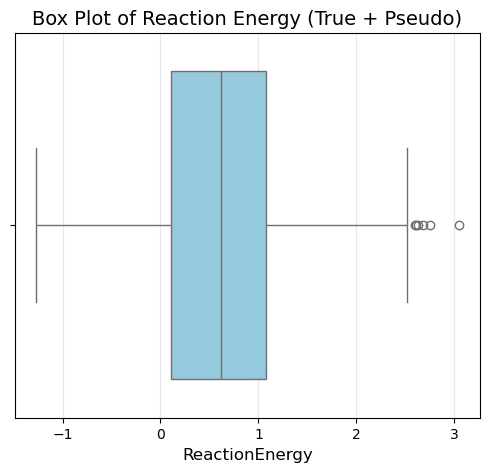

In [90]:
import seaborn as sns
plt.figure(figsize=(6, 5))
sns.boxplot(x = true_pseudo_label["ReactionEnergy"], color='skyblue')
plt.title("Box Plot of Reaction Energy (True + Pseudo)", fontsize=14)
plt.xlabel("ReactionEnergy", fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.show()

In [91]:
true_pseudo_label.columns

Index(['surfaceComposition', 'Facet', 'ChemicalComposition', 'Site',
       'O*_energy', 'OH*_energy', 'CoordinationNumber', 'ReducedComposition',
       'meanAtomicRadius', 'maxAtomicRadius', 'minAtomicRadius',
       'stdAtomicRadius', 'meanAtomicMass', 'maxAtomicMass', 'minAtomicMass',
       'stdAtomicMass', 'meanAffinity', 'maxAffinity', 'minAffinity',
       'stdAffinity', 'meanDensity', 'maxDensity', 'minDensity', 'stdDensity',
       'meanGroup', 'maxGroup', 'minGroup', 'stdGroup', 'meanMeltingP',
       'maxMeltingP', 'minMeltingP', 'stdMeltingP', 'meanIon', 'maxIon',
       'minIon', 'stdIon', 'meanElectronegativity', 'maxElectronegativity',
       'minElectronegativity', 'stdElectronegativity', 'meanPcount',
       'maxPcount', 'minPcount', 'stdPcount', 'meanDcount', 'maxDcount',
       'minDcount', 'stdDcount', 'meanEnthalpy', 'maxEnthalpy', 'minEnthalpy',
       'stdEnthalpy', 'PseudoLabelled', 'ReactionEnergy',
       'NumElementsSurface'],
      dtype='object')

====== Cross-Validated Results ======
Mean Train R²:  0.9299 ± 0.0046
Mean Test  R²:  0.7066 ± 0.0404
Mean Test  MAE: 0.2422 ± 0.0119
Mean Test  RMSE:0.3590 ± 0.0204

===== Top 10 Important Features =====
CoordinationNumber    0.167713
meanDcount            0.081310
meanEnthalpy          0.077735
meanGroup             0.074854
meanMeltingP          0.073035
PseudoLabelled        0.038265
minDcount             0.036505
minGroup              0.035729
maxGroup              0.035341
minMeltingP           0.029625
minEnthalpy           0.027297
maxDcount             0.022140
meanAffinity          0.019325
meanAtomicRadius      0.018370
maxMeltingP           0.018033
dtype: float64


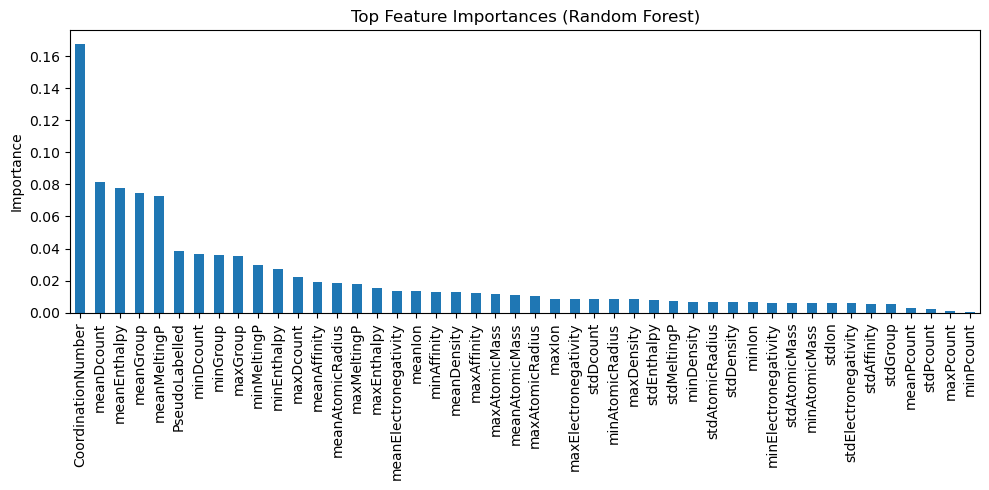

In [92]:
filtered_ = true_pseudo_label[['CoordinationNumber', 'meanAtomicRadius',
       'maxAtomicRadius', 'minAtomicRadius', 'stdAtomicRadius',
       'meanAtomicMass', 'maxAtomicMass', 'minAtomicMass', 'stdAtomicMass',
       'meanAffinity', 'maxAffinity','minAffinity', 'stdAffinity',
       'meanGroup', 'maxGroup','minGroup', 'stdGroup',
        'meanDensity', 'maxDensity','minDensity', 'stdDensity',
       'meanMeltingP', 'maxMeltingP', 'minMeltingP', 'stdMeltingP', 'meanIon',
       'maxIon', 'minIon', 'stdIon', 'meanElectronegativity',
       'maxElectronegativity', 'minElectronegativity', 'stdElectronegativity',
        'meanDcount', 'maxDcount', 'minDcount', 'stdDcount',
      'meanPcount', 'maxPcount', 'minPcount', 'stdPcount',
        'meanEnthalpy', 'maxEnthalpy', 'minEnthalpy',
       'stdEnthalpy','PseudoLabelled',
    'ReactionEnergy']].dropna()

X = filtered_.drop('ReactionEnergy', axis = 1)
y = filtered_["ReactionEnergy"]

rf_true_pseudo = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

# Define 5-fold cross validation
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Define scoring metrics
scoring = {
    'R2': make_scorer(r2_score),
    'MAE': make_scorer(mean_absolute_error),
    'RMSE': make_scorer(lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)))
}

# Perform cross-validation
cv_results = cross_validate(rf_true_pseudo, X, y, cv=cv, scoring=scoring, return_train_score=True)

# Print results
print("====== Cross-Validated Results ======")
print(f"Mean Train R²:  {cv_results['train_R2'].mean():.4f} ± {cv_results['train_R2'].std():.4f}")
print(f"Mean Test  R²:  {cv_results['test_R2'].mean():.4f} ± {cv_results['test_R2'].std():.4f}")
print(f"Mean Test  MAE: {cv_results['test_MAE'].mean():.4f} ± {cv_results['test_MAE'].std():.4f}")
print(f"Mean Test  RMSE:{cv_results['test_RMSE'].mean():.4f} ± {cv_results['test_RMSE'].std():.4f}")



# Fit once on the full dataset for feature importance extraction
rf_true_pseudo.fit(X, y)

# Compute feature importances
feat_importances = pd.Series(rf_true_pseudo.feature_importances_, index=X.columns)
feat_importances = feat_importances.sort_values(ascending=False)

# Print the top 10 most important features
print()
print("===== Top 10 Important Features =====")
print(feat_importances.head(15))

# Plot
plt.figure(figsize=(10,5))
feat_importances.plot(kind='bar')
plt.title("Top Feature Importances (Random Forest)")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()


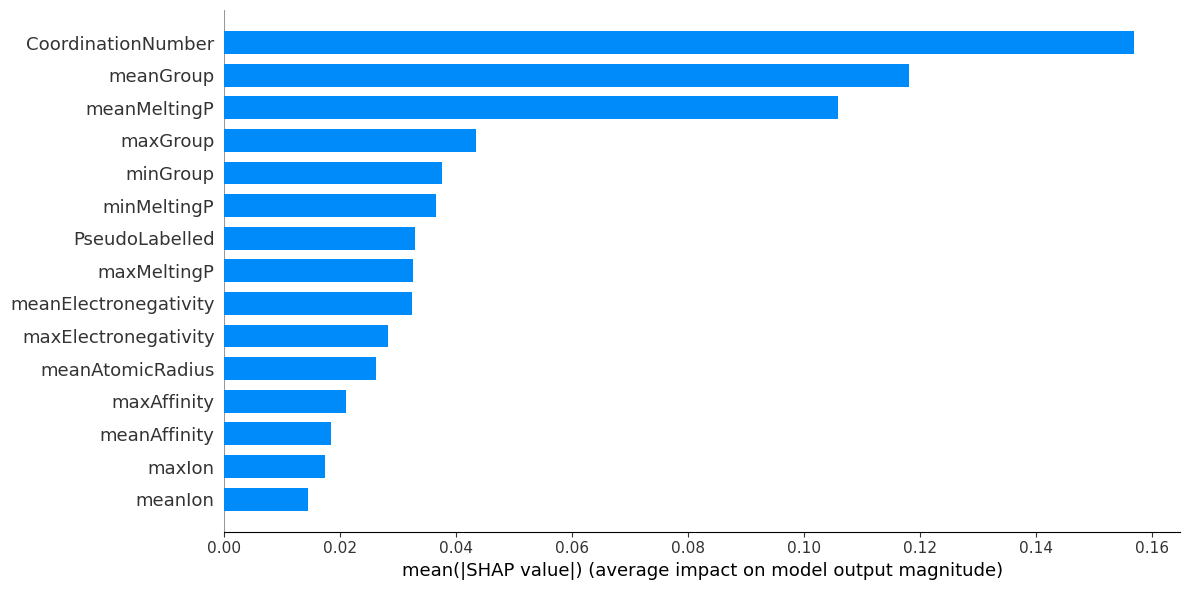

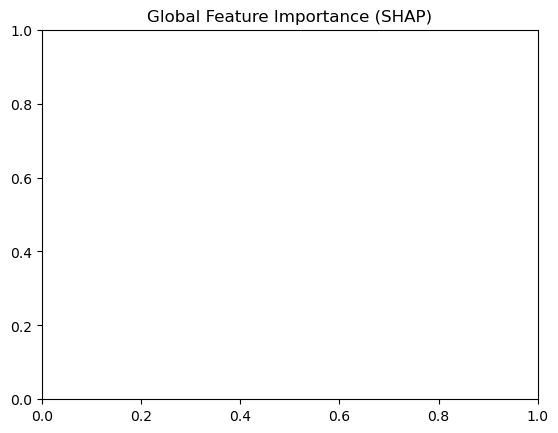

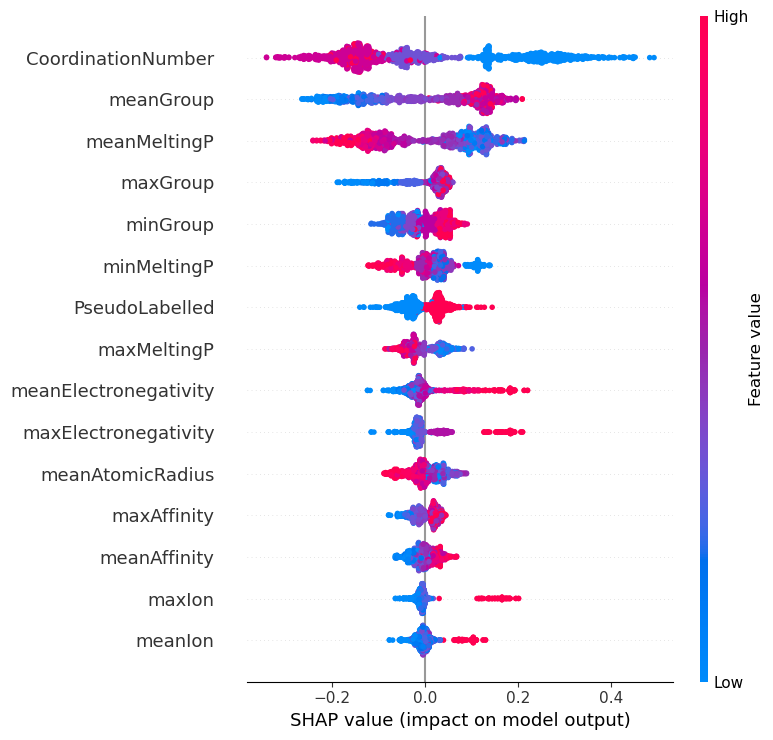

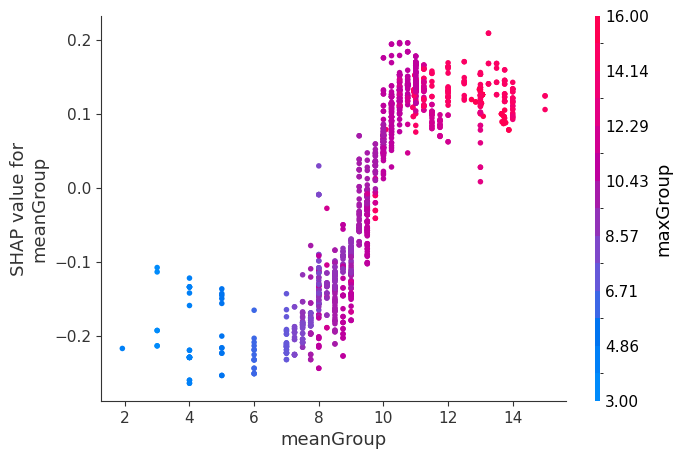

In [132]:
import shap

# Create a TreeExplainer for your Random Forest
explainer = shap.TreeExplainer(rf_true_pseudo)

# Calculate SHAP values for all samples
shap_values = explainer.shap_values(X)  # For regression, returns a 2D array (samples x features)

# -------------------------------
# 1. Global Feature Importance
# -------------------------------
# This shows the mean absolute SHAP value per feature
shap.summary_plot(shap_values, X, plot_type="bar", max_display=15, plot_size=(12,6))
plt.title("Global Feature Importance (SHAP)")
plt.show()

# -------------------------------
# 2. Summary Dot Plot
# -------------------------------
# Shows feature impact across all samples
shap.summary_plot(shap_values, X, plot_type="dot", max_display=15)

# -------------------------------
# 3. Dependence Plot for a single feature
# -------------------------------
# Example: plot SHAP value vs feature value for 'PseudoLabelled'
if 'meanGroup' in X.columns:
    shap.dependence_plot('meanGroup', shap_values, X)

# -------------------------------
# 4. Optional: Identify top contributing features for outliers
# -------------------------------
# Compute residuals
y_pred = rf_true_pseudo.predict(X)
residuals = y - y_pred

# Pick the top 10 largest absolute residuals
outlier_pos = residuals.abs().sort_values(ascending=False).head(10).index
outlier_pos = [residuals.index.get_loc(i) for i in outlier_pos] 

# SHAP values for these outliers
shap.force_plot(
    explainer.expected_value, 
    shap_values[outlier_pos, :], 
    X.iloc[outlier_pos, :]
)

In [236]:
from sklearn.model_selection import cross_val_predict

'''CoordinationNumber      0.1660
meanGroup               0.1049
meanDcount              0.0857
meanMeltingP            0.0840
minDcount               0.0456
maxGroup                0.0417
minGroup                0.0412
minMeltingP             0.0402
PseudoLabelled          0.0372
maxDcount               0.0271
maxMeltingP             0.0257
meanAffinity            0.0245
meanAtomicRadius        0.0233
meanElectronegativity   0.0169
meanIon                 0.0156


CoordinationNumber      0.1952
meanGroup               0.1025
meanDcount              0.0923
meanMeltingP            0.0906
minGroup                0.0442
minDcount               0.0427
minMeltingP             0.0380
maxGroup                0.0380
maxDcount               0.0276
maxMeltingP             0.0266
meanAffinity            0.0237
meanAtomicRadius        0.0219
meanElectronegativity   0.0164
minAffinity             0.0157
meanIon                 0.0152


CoordinationNumber    0.168484
meanDcount            0.083125
meanEnthalpy          0.077477
meanGroup             0.074010
meanMeltingP          0.070909
PseudoLabelled        0.038099
maxGroup              0.036657
minDcount             0.036601
minGroup              0.035000
minMeltingP           0.030347
minEnthalpy           0.027940
maxDcount             0.020471
meanAffinity          0.019924
maxMeltingP           0.018647
meanAtomicRadius      0.018101'''

'CoordinationNumber      0.1660\nmeanGroup               0.1049\nmeanDcount              0.0857\nmeanMeltingP            0.0840\nminDcount               0.0456\nmaxGroup                0.0417\nminGroup                0.0412\nminMeltingP             0.0402\nPseudoLabelled          0.0372\nmaxDcount               0.0271\nmaxMeltingP             0.0257\nmeanAffinity            0.0245\nmeanAtomicRadius        0.0233\nmeanElectronegativity   0.0169\nmeanIon                 0.0156'

Cross-validated (out-of-fold) performance:
R²:   0.7990
MAE:  0.2176
RMSE: 0.3210


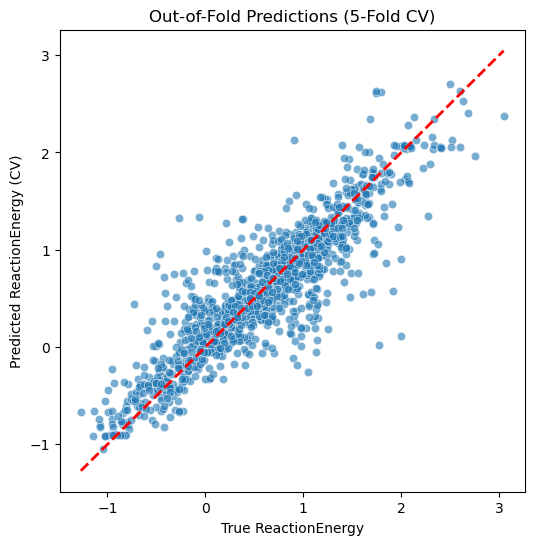

====== Cross-Validated Results ======
Mean Train R²:  0.9252 ± 0.0072
Mean Test  R²:  0.7948 ± 0.0473
Mean Test  MAE: 0.2176 ± 0.0101
Mean Test  RMSE:0.3199 ± 0.0266

===== Top 10 Important Features =====
meanGroup             0.177330
CoordinationNumber    0.174473
meanMeltingP          0.156148
meanEnthalpy          0.131980
meanDcount            0.110993
maxGroup              0.106121
minDcount             0.083975
minGroup              0.058979
dtype: float64


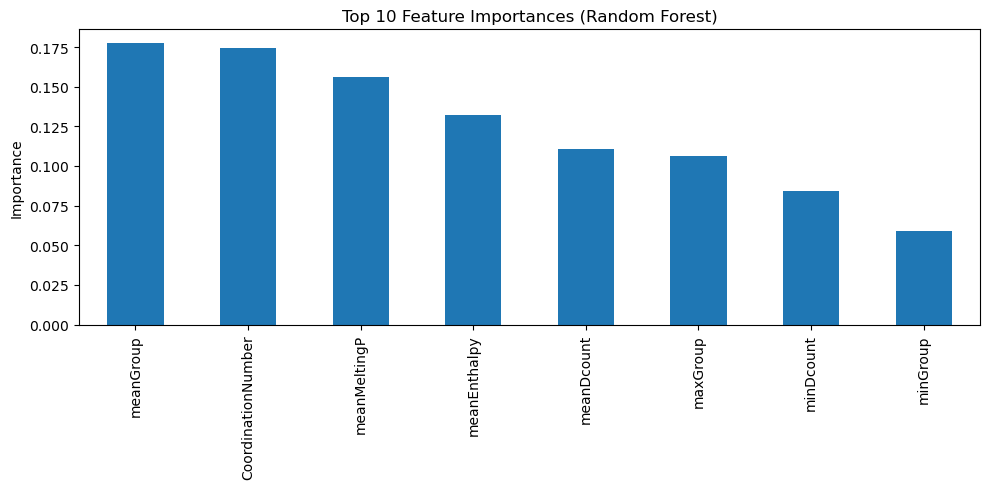

In [118]:
filtered_ = true_pseudo_label[['CoordinationNumber',
'meanDcount',
'meanEnthalpy',
'meanGroup',
'meanMeltingP',
#'PseudoLabelled',
'maxGroup',
'minDcount',
'minGroup',
#'minMeltingP',
#'minEnthalpy',           
#'maxDcount',
#'meanAffinity',
#'maxMeltingP',
#'meanAtomicRadius'
                                'ReactionEnergy']].dropna()


X = filtered_.drop('ReactionEnergy', axis = 1)
y = filtered_["ReactionEnergy"]

rf_true_pseudo = RandomForestRegressor(
    n_estimators=500,      
    max_depth=None,        
    min_samples_split=2,   
    min_samples_leaf=1,    
    max_features= 'sqrt',   
    random_state=42,
    n_jobs=-1              
)

cv = KFold(n_splits=5, shuffle=True, random_state=42)



# Define scoring metrics
scoring = {
    'R2': make_scorer(r2_score),
    'MAE': make_scorer(mean_absolute_error),
    'RMSE': make_scorer(lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)))
}

y_pred_oof = cross_val_predict(rf_true_pseudo, X, y, cv=cv, n_jobs=-1) 

r2 = r2_score(y, y_pred_oof)
mae = mean_absolute_error(y, y_pred_oof)
rmse = np.sqrt(mean_squared_error(y, y_pred_oof))

print("Cross-validated (out-of-fold) performance:")
print(f"R²:   {r2:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

# Scatter plot of true vs predicted
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,6))
sns.scatterplot(x=y, y=y_pred_oof, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)  # y=x line
plt.xlabel("True ReactionEnergy")
plt.ylabel("Predicted ReactionEnergy (CV)")
plt.title("Out-of-Fold Predictions (5-Fold CV)")
plt.show()



# Perform cross-validation
cv_results = cross_validate(rf_true_pseudo, X, y, cv=cv, scoring=scoring, return_train_score=True)

# Print results
print("====== Cross-Validated Results ======")
print(f"Mean Train R²:  {cv_results['train_R2'].mean():.4f} ± {cv_results['train_R2'].std():.4f}")
print(f"Mean Test  R²:  {cv_results['test_R2'].mean():.4f} ± {cv_results['test_R2'].std():.4f}")
print(f"Mean Test  MAE: {cv_results['test_MAE'].mean():.4f} ± {cv_results['test_MAE'].std():.4f}")
print(f"Mean Test  RMSE:{cv_results['test_RMSE'].mean():.4f} ± {cv_results['test_RMSE'].std():.4f}")



# Fit once on the full dataset for feature importance extraction
rf_true_pseudo.fit(X, y)

# Compute feature importances
feat_importances = pd.Series(rf_true_pseudo.feature_importances_, index=X.columns)
feat_importances = feat_importances.sort_values(ascending=False)

# Print the top 10 most important features
print()
print("===== Top 10 Important Features =====")
print(feat_importances.head(10))

# Plot
plt.figure(figsize=(10,5))
feat_importances.plot(kind='bar')
plt.title("Top 10 Feature Importances (Random Forest)")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

# only true labels 0.7918 ± 0.0361
# with PseudoLabelled: 0.8205 ± 0.0391
# with PseudoLabelled without pseudoLabel Category: 0.7948 ± 0.0473 #Practically the same with only true labels 

In [96]:
import shap

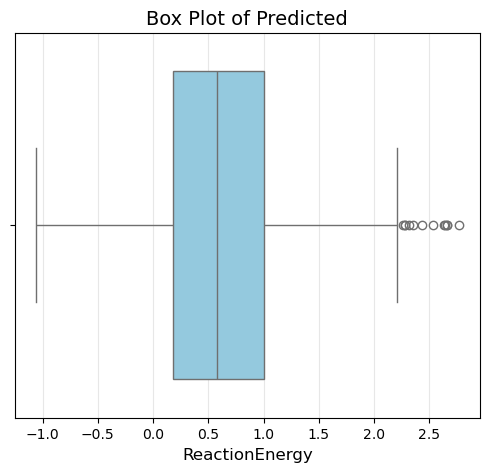

In [276]:
plt.figure(figsize=(6, 5))
sns.boxplot(x = y_pred_oof, color='skyblue')
plt.title("Box Plot of Predicted", fontsize=14)
plt.xlabel("ReactionEnergy", fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.show()

## Alright, what about a SHAP analysis now to see whether pseudo-labelled feature actually matter

In [97]:
shap.initjs()

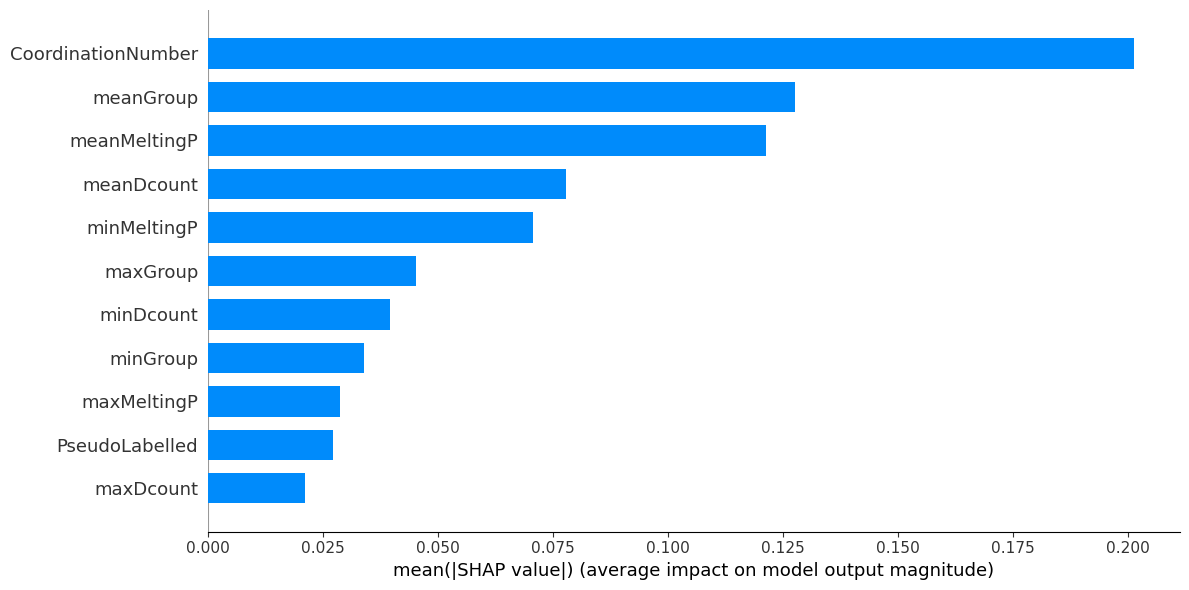

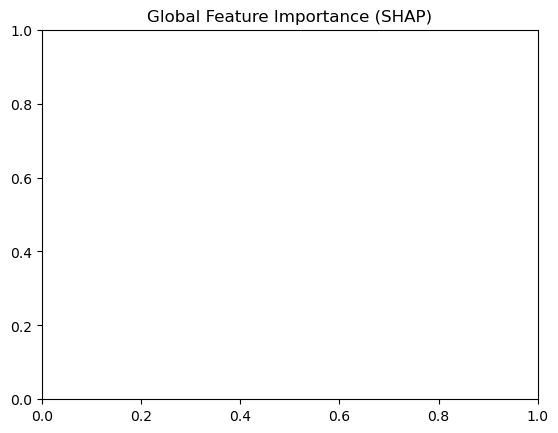

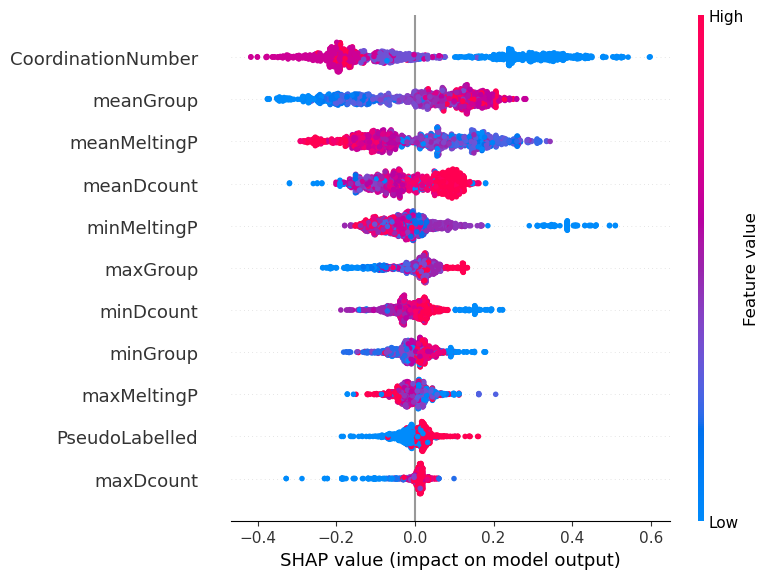

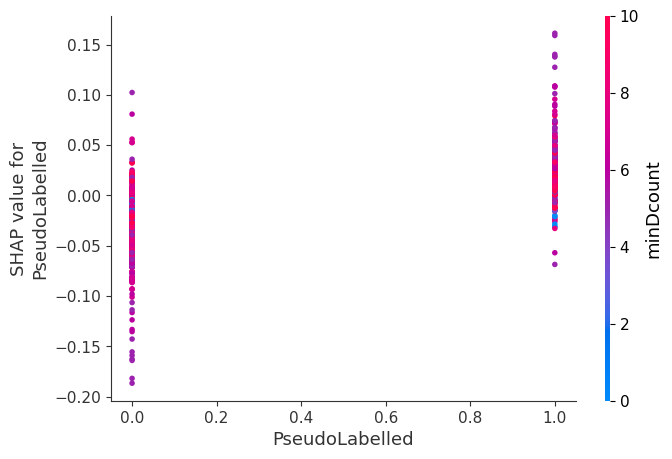

In [277]:
filtered_ = true_pseudo_label[['CoordinationNumber', 'meanGroup',
                               'meanDcount', 'meanMeltingP', 'minGroup', 'minDcount', 'minMeltingP',
                               'maxGroup', 'maxDcount','maxMeltingP', 
                                'ReactionEnergy', 'PseudoLabelled']].dropna()

X = filtered_.drop('ReactionEnergy', axis = 1)

# Create a TreeExplainer for your Random Forest
explainer = shap.TreeExplainer(rf_true_pseudo)

# Calculate SHAP values for all samples
shap_values = explainer.shap_values(X)  # For regression, returns a 2D array (samples x features)

# -------------------------------
# 1. Global Feature Importance
# -------------------------------
# This shows the mean absolute SHAP value per feature
shap.summary_plot(shap_values, X, plot_type="bar", max_display=15, plot_size=(12,6))
plt.title("Global Feature Importance (SHAP)")
plt.show()

# -------------------------------
# 2. Summary Dot Plot
# -------------------------------
# Shows feature impact across all samples
shap.summary_plot(shap_values, X, plot_type="dot", max_display=15)

# -------------------------------
# 3. Dependence Plot for a single feature
# -------------------------------
# Example: plot SHAP value vs feature value for 'PseudoLabelled'
if 'PseudoLabelled' in X.columns:
    shap.dependence_plot('PseudoLabelled', shap_values, X)

# -------------------------------
# 4. Optional: Identify top contributing features for outliers
# -------------------------------
# Compute residuals
y_pred = rf_true_pseudo.predict(X)
residuals = y - y_pred

# Pick the top 10 largest absolute residuals
outlier_pos = residuals.abs().sort_values(ascending=False).head(10).index
outlier_pos = [residuals.index.get_loc(i) for i in outlier_pos] 

# SHAP values for these outliers
shap.force_plot(
    explainer.expected_value, 
    shap_values[outlier_pos, :], 
    X.iloc[outlier_pos, :]
)

In [94]:
from xgboost import XGBRegressor
import xgboost as xgb 

descr = ['meanGroup','CoordinationNumber', 'meanDcount', 'meanMeltingP', 'minGroup', 'maxAtomicRadius','meanAtomicRadius',     
            'minDensity', 'meanElectronegativity']

target = "ReactionEnergy"

# Prepare data
X = true_pseudo_label[descr]
y = true_pseudo_label[target]

# Train-test split
X_train_top10, X_test_top10, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


xgb_model_top10 = XGBRegressor(objective='reg:squarederror',colsample_bytree= 0.8, learning_rate= 0.01, max_depth= 5, n_estimators= 400, subsample= 0.8, random_state=42)

xgb_model_top10.fit(X_train_top10, y_train)

from sklearn.model_selection import cross_validate, KFold
from sklearn.metrics import make_scorer, r2_score, mean_squared_error, mean_absolute_error

# Define 5-fold cross validation
cv = KFold(n_splits=3, shuffle=True, random_state=42)

# Define scoring metrics
scoring = {
    'R2': make_scorer(r2_score),
    'MAE': make_scorer(mean_absolute_error),
    'RMSE': make_scorer(lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)))
}

# Perform cross-validation
cv_results = cross_validate(xgb_model_top10, X, y, cv=cv, scoring=scoring, return_train_score=True)

# Print results
print("====== Cross-Validated Results ======")
print(f"Mean Train R²:  {cv_results['train_R2'].mean():.4f} ± {cv_results['train_R2'].std():.4f}")
print(f"Mean Test  R²:  {cv_results['test_R2'].mean():.4f} ± {cv_results['test_R2'].std():.4f}")
print(f"Mean Test  MAE: {cv_results['test_MAE'].mean():.4f} ± {cv_results['test_MAE'].std():.4f}")
print(f"Mean Test  RMSE:{cv_results['test_RMSE'].mean():.4f} ± {cv_results['test_RMSE'].std():.4f}")


====== Cross-Validated Results ======
Mean Train R²:  0.8974 ± 0.0070
Mean Test  R²:  0.8143 ± 0.0148
Mean Test  MAE: 0.2125 ± 0.0099
Mean Test  RMSE:0.3080 ± 0.0173


In [98]:
filtered_ = true_pseudo_label[['meanGroup','CoordinationNumber', 'meanDcount', 'meanMeltingP', 'minGroup', 'maxAtomicRadius','meanAtomicRadius',     
            'minDensity', 'meanElectronegativity', 'ReactionEnergy']].dropna()

X = filtered_.drop('ReactionEnergy', axis = 1)
y = filtered_["ReactionEnergy"]

# Create a TreeExplainer for your Random Forest
explainer = shap.TreeExplainer(xgb_model_top10)

# Calculate SHAP values for all samples
shap_values = explainer.shap_values(X)  # For regression, returns a 2D array (samples x features)

# -------------------------------
# 1. Global Feature Importance
# -------------------------------
# This shows the mean absolute SHAP value per feature
shap.summary_plot(shap_values, X, plot_type="bar", max_display=15, plot_size=(12,6))
plt.title("Global Feature Importance (SHAP)")
plt.show()

# -------------------------------
# 2. Summary Dot Plot
# -------------------------------
# Shows feature impact across all samples
shap.summary_plot(shap_values, X, plot_type="dot", max_display=15)

# -------------------------------
# 3. Dependence Plot for a single feature
# -------------------------------
# Example: plot SHAP value vs feature value for 'PseudoLabelled'
if 'PseudoLabelled' in X.columns:
    shap.dependence_plot('PseudoLabelled', shap_values, X)

# -------------------------------
# 4. Optional: Identify top contributing features for outliers
# -------------------------------
# Compute residuals
y_pred = xgb_model_top10.predict(X)
residuals = y - y_pred

# Pick the top 10 largest absolute residuals
outlier_pos = residuals.abs().sort_values(ascending=False).head(10).index
outlier_pos = [residuals.index.get_loc(i) for i in outlier_pos] 

# SHAP values for these outliers
shap.force_plot(
    explainer.expected_value, 
    shap_values[outlier_pos, :], 
    X.iloc[outlier_pos, :]
)

ValueError: could not convert string to float: '[6.0495466E-1]'

# As the Pseudo Labelling has doubled the data AND improved the RF model, now it may be the time to be more careful in data selection. In particular, the presence of outliers and duplicates 

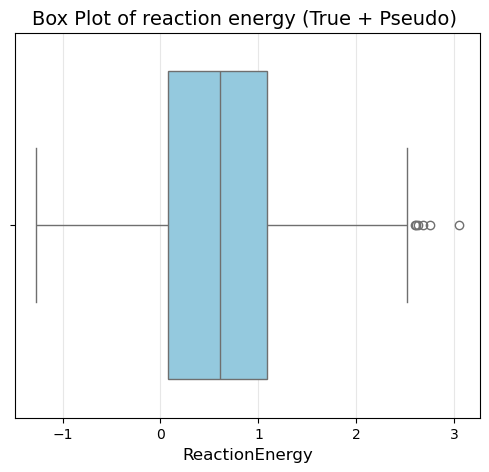

In [140]:
plt.figure(figsize=(6, 5))
sns.boxplot(x = true_pseudo_label["ReactionEnergy"], color='skyblue')
plt.title("Box Plot of reaction energy (True + Pseudo) ", fontsize=14)
plt.xlabel("ReactionEnergy", fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.show()

In [141]:
Q1 = true_pseudo_label["ReactionEnergy"].quantile(0.25)
Q3 = true_pseudo_label["ReactionEnergy"].quantile(0.75)
rightmost = Q3 + 1.5*(Q3-Q1)
print(Q1, Q3, rightmost)

0.07913323991396726 1.0859162401625873 2.596090740535517


In [142]:
outliers = true_pseudo_label[true_pseudo_label["ReactionEnergy"] > 2.59]
outliers.head(10)

,surfaceComposition,Facet,ChemicalComposition,Site,O*_energy,OH*_energy,CoordinationNumber,ReducedComposition,meanAtomicRadius,maxAtomicRadius,...,maxIon,minIon,stdIon,meanElectronegativity,maxElectronegativity,minElectronegativity,stdElectronegativity,PseudoLabelled,ReactionEnergy,NumElementsSurface
578,CoCu-MOF,100,Co6Cu3C96H48N48,M2,4.1548,1.3989,1.0000,Co2CuC32H16N16,154.6866,192.0000,...,14.5340,7.7260,1.7276,2.5537,3.0400,1.8800,0.3260,0,2.7559,5
760,CuCo-MOF,100,Co3Cu6C96H48N48,M1,3.6438,1.0438,1.0000,CoCu2C32H16N16,153.9104,192.0000,...,14.5340,7.7260,1.7338,2.5540,3.0400,1.8800,0.3254,0,2.5999,5
762,CuCu-MOF,100,Cu9C96H48N48,M1,4.1063,1.4815,1.0000,Cu3C32H16N16,153.1343,170.0000,...,14.5340,7.7260,1.7399,2.5543,3.0400,1.9000,0.3248,0,2.6248,4
763,CuCu-MOF,100,Cu9C96H48N48,M2,3.9830,1.2994,1.0000,Cu3C32H16N16,153.1343,170.0000,...,14.5340,7.7260,1.7399,2.5543,3.0400,1.9000,0.3248,0,2.6836,4
771,CuNi-MOF,100,Cu6Ni3C96H48N48,M1,4.0838,1.4796,1.0000,Cu2NiC32H16N16,153.4776,170.0000,...,14.5340,7.6400,1.7434,2.5545,3.0400,1.9000,0.3245,0,2.6042,5
1244,NiCu-MOF,100,Cu3Ni6C96H48N48,M2,4.2366,1.1919,1.0000,CuNi2C32H16N16,153.8209,170.0000,...,14.5340,7.6400,1.7469,2.5546,3.0400,1.9000,0.3242,0,3.0447,5


In [143]:
HEC = true_pseudo_label[true_pseudo_label["NumElementsSurface"] > 4]
HEC.head(50)

,surfaceComposition,Facet,ChemicalComposition,Site,O*_energy,OH*_energy,CoordinationNumber,ReducedComposition,meanAtomicRadius,maxAtomicRadius,...,maxIon,minIon,stdIon,meanElectronegativity,maxElectronegativity,minElectronegativity,stdElectronegativity,PseudoLabelled,ReactionEnergy,NumElementsSurface
577,CoCu-MOF,100,Co6Cu3C96H48N48,M1,2.8617,1.1179,1.0000,Co2CuC32H16N16,154.6866,192.0000,...,14.5340,7.7260,1.7276,2.5537,3.0400,1.8800,0.3260,0,1.7437,5
578,CoCu-MOF,100,Co6Cu3C96H48N48,M2,4.1548,1.3989,1.0000,Co2CuC32H16N16,154.6866,192.0000,...,14.5340,7.7260,1.7276,2.5537,3.0400,1.8800,0.3260,0,2.7559,5
582,CoNi-MOF,100,Co6Ni3C96H48N48,M1,2.4621,0.7929,1.0000,Co2NiC32H16N16,155.0299,192.0000,...,14.5340,7.6400,1.7311,2.5539,3.0400,1.8800,0.3257,0,1.6692,5
583,CoNi-MOF,100,Co6Ni3C96H48N48,M2,2.9110,1.2845,1.0000,Co2NiC32H16N16,155.0299,192.0000,...,14.5340,7.6400,1.7311,2.5539,3.0400,1.8800,0.3257,0,1.6265,5
760,CuCo-MOF,100,Co3Cu6C96H48N48,M1,3.6438,1.0438,1.0000,CoCu2C32H16N16,153.9104,192.0000,...,14.5340,7.7260,1.7338,2.5540,3.0400,1.8800,0.3254,0,2.5999,5
761,CuCo-MOF,100,Co3Cu6C96H48N48,M2,2.2846,0.4922,1.0000,CoCu2C32H16N16,153.9104,192.0000,...,14.5340,7.7260,1.7338,2.5540,3.0400,1.8800,0.3254,0,1.7924,5
771,CuNi-MOF,100,Cu6Ni3C96H48N48,M1,4.0838,1.4796,1.0000,Cu2NiC32H16N16,153.4776,170.0000,...,14.5340,7.6400,1.7434,2.5545,3.0400,1.9000,0.3245,0,2.6042,5
772,CuNi-MOF,100,Cu6Ni3C96H48N48,M2,3.3783,1.6337,1.0000,Cu2NiC32H16N16,153.4776,170.0000,...,14.5340,7.6400,1.7434,2.5545,3.0400,1.9000,0.3245,0,1.7446,5
876,HEO-18-Fe3.0Zn2.0Cr3.0Mn2.0Co3.0Ni3.0,100,Co3Cr2Fe2Mn2Ni3Zn2O20,Co,3.3223,1.4283,1.0000,Co3Cr2Fe2Mn2Ni3Zn2O20,163.0294,197.0000,...,13.6180,6.7670,2.8897,2.7515,3.4400,1.5500,0.8274,0,1.8940,7
877,HEO-19-Co3.0Zn2.0Cr3.0Mn3.0Fe3.0Ni2.0-Co-site,100,Co3Cr2Fe2Mn2Ni2Zn2O16,Co,1.7596,-0.1654,1.0000,Co3Cr2Fe2Mn2Ni2Zn2O16,164.5517,197.0000,...,13.6180,6.7670,2.9186,2.6855,3.4400,1.5500,0.8418,0,1.9250,7


In [144]:
# check for duplicated entries based on selected columns
duplicates = true_pseudo_label[true_pseudo_label.duplicated(subset=["Facet", "Site", "ChemicalComposition"], keep=False)]

# print the number and examples of duplicates
print(f"Number of duplicated rows: {len(duplicates)}")

# if there are any, display them
if not duplicates.empty:
    display(duplicates.sort_values(by=["Facet", "Site", "ChemicalComposition"]))

Number of duplicated rows: 35


,surfaceComposition,Facet,ChemicalComposition,Site,O*_energy,OH*_energy,CoordinationNumber,ReducedComposition,meanAtomicRadius,maxAtomicRadius,...,maxIon,minIon,stdIon,meanElectronegativity,maxElectronegativity,minElectronegativity,stdElectronegativity,PseudoLabelled,ReactionEnergy,NumElementsSurface
876,HEO-18-Fe3.0Zn2.0Cr3.0Mn2.0Co3.0Ni3.0,100,Co3Cr2Fe2Mn2Ni3Zn2O20,Co,3.3223,1.4283,1.0000,Co3Cr2Fe2Mn2Ni3Zn2O20,163.0294,197.0000,...,13.6180,6.7670,2.8897,2.7515,3.4400,1.5500,0.8274,0,1.8940,7
882,HEO-3-Mn3.0Zn2.0Cr3.0Fe2.0Co3.0Ni3.0,100,Co3Cr2Fe2Mn2Ni3Zn2O20,Co,2.6858,1.2389,1.0000,Co3Cr2Fe2Mn2Ni3Zn2O20,163.0294,197.0000,...,13.6180,6.7670,2.8897,2.7515,3.4400,1.5500,0.8274,0,1.4469,7
885,HEO-5-Fe3.0Zn2.0Cr3.0Mn3.0Co3.0Ni2.0,100,Co3Cr2Fe2Mn2Ni3Zn2O20,Co,2.7379,0.7471,1.0000,Co3Cr2Fe2Mn2Ni3Zn2O20,163.0294,197.0000,...,13.6180,6.7670,2.8897,2.7515,3.4400,1.5500,0.8274,0,1.9908,7
887,HEO-8-Fe3.0Zn2.0Cr3.0Mn3.0Co2.0Ni3.0,100,Co3Cr2Fe2Mn2Ni3Zn2O20,Co,3.0420,1.4401,1.0000,Co3Cr2Fe2Mn2Ni3Zn2O20,163.0294,197.0000,...,13.6180,6.7670,2.8897,2.7515,3.4400,1.5500,0.8274,0,1.6020,7
883,HEO-43-Ni3.0Zn2.0Cr3.0Mn3.0Fe3.0Co2.0,100,Co3Cr2Fe3Mn2Ni2Zn2O20,Co,3.3460,1.0190,1.0000,Co3Cr2Fe3Mn2Ni2Zn2O20,163.9412,197.0000,...,13.6180,6.7670,2.8804,2.7491,3.4400,1.5500,0.8299,0,2.3270,7
886,HEO-7-Ni3.0Zn2.0Cr3.0Mn3.0Fe2.0Co3.0,100,Co3Cr2Fe3Mn2Ni2Zn2O20,Co,2.6207,0.5498,1.0000,Co3Cr2Fe3Mn2Ni2Zn2O20,163.9412,197.0000,...,13.6180,6.7670,2.8804,2.7491,3.4400,1.5500,0.8299,0,2.0708,7
2349,Zn-HESO103-MnNiFeCrZn,100,Co9CrFeMnNiZnO20,Co,3.3025,1.2902,1.0000,Co9CrFeMnNiZnO20,166.1765,197.0000,...,13.6180,6.7670,2.8525,2.7741,3.4400,1.5500,0.7990,0,2.0123,7
2350,Zn-HESO105-MnNiFeCrZn,100,Co9CrFeMnNiZnO20,Co,3.2258,1.8275,1.0000,Co9CrFeMnNiZnO20,166.1765,197.0000,...,13.6180,6.7670,2.8525,2.7741,3.4400,1.5500,0.7990,0,1.3983,7
2351,Zn-HESO109-MnNiFeCrZn,100,Co9CrFeMnNiZnO20,Co,2.5430,0.5194,1.0000,Co9CrFeMnNiZnO20,166.1765,197.0000,...,13.6180,6.7670,2.8525,2.7741,3.4400,1.5500,0.7990,0,2.0236,7
2352,Zn-HESO11-MnNiFeCrZn,100,Co9CrFeMnNiZnO20,Co,3.6662,1.3310,1.0000,Co9CrFeMnNiZnO20,166.1765,197.0000,...,13.6180,6.7670,2.8525,2.7741,3.4400,1.5500,0.7990,0,2.3352,7


### One can observe that the duplicates and outliers mainly occur for HEC, but from the previous models, it is also seen that entropy or number of elements on the surface is not determinant of the reaction energy, therefore, the reduction of the number of datapoint in HEC should NOT affect the overall performance. 

In [85]:
true_pseudo_label.head()

,surfaceComposition,Facet,ChemicalComposition,Site,O*_energy,OH*_energy,CoordinationNumber,ReducedComposition,meanAtomicRadius,maxAtomicRadius,...,maxPcount,minPcount,stdPcount,meanDcount,maxDcount,minDcount,stdDcount,PseudoLabelled,ReactionEnergy,NumElementsSurface
2,Ag,111,Ag12,hollow|A_A_A|FCC,1.961800,0.563018,3.0,Ag,172.0,172.0,...,0,0,0.0,10.0,10,10,0.0,0,1.398782,1
3,Ag,111,Ag12,hollow|A_A_A|HCP,2.050681,0.589955,3.0,Ag,172.0,172.0,...,0,0,0.0,10.0,10,10,0.0,0,1.460725,1
4,Ag,111,Ag12,top|A,3.426808,1.387435,1.0,Ag,172.0,172.0,...,0,0,0.0,10.0,10,10,0.0,0,2.039373,1
9,Ag-fcc,111,Ag16,fcc,2.258668,0.718049,3.0,Ag,172.0,172.0,...,0,0,0.0,10.0,10,10,0.0,0,1.540620,1
26,Ag3Au,111,Ag9Au3,hollow|A_A_A|FCC,2.208363,0.660700,3.0,Ag3Au,170.5,172.0,...,0,0,0.0,10.0,10,10,0.0,0,1.547663,2


## Something extra here, as as seen from the previous SHAP test that he pseudoLabelled = 1 gives a positive affect, does it mean there is an general overestimation

Estimated pseudo-label bias (mean pseudo - pred_on_pseudo): 0.0084


Testing deltas: 100%|███████████████████████████| 10/10 [00:20<00:00,  2.05s/it]

      delta     cv_r2    cv_mae  mean_pseudo_importance  std_pseudo_importance
0 -0.191566  0.822895  0.207738                0.046160               0.002276
1 -0.141566  0.821355  0.207371                0.038126               0.001163
2 -0.091566  0.820720  0.206780                0.032454               0.001088
3 -0.041566  0.818394  0.206720                0.029281               0.001095
4  0.008434  0.818394  0.206195                0.027309               0.000881
5  0.000000  0.817843  0.206683                0.027319               0.001051
6  0.108434  0.817294  0.207226                0.026375               0.001152
7  0.058434  0.817117  0.206738                0.026087               0.001177
8  0.158434  0.815175  0.209370                0.027426               0.001101
9  0.208434  0.814255  0.211315                0.029868               0.001127


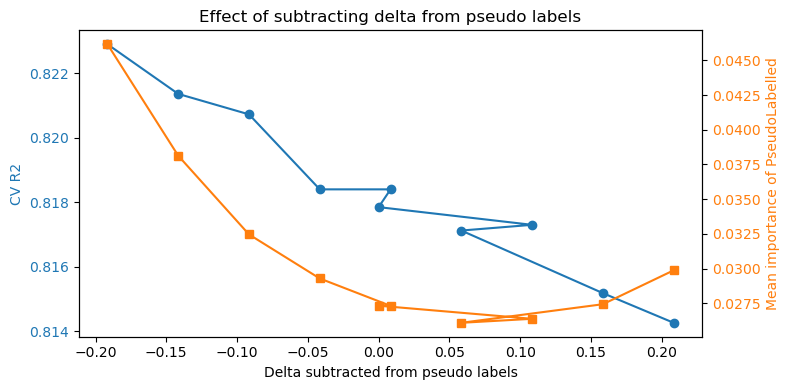

In [88]:
from tqdm import tqdm

filtered_ = true_pseudo_label[['CoordinationNumber', 'meanGroup',
                               'meanDcount', 'meanMeltingP', 'minGroup', 'minDcount', 'minMeltingP',
                               'maxGroup', 'maxDcount','maxMeltingP', 
                                'ReactionEnergy', 'PseudoLabelled']].dropna()

X = filtered_.drop('ReactionEnergy', axis=1)
y = filtered_['ReactionEnergy']

# identify pseudo vs true
is_pseudo = X['PseudoLabelled'] == 1
pseudo_idx = X[is_pseudo].index
true_idx = X[~is_pseudo].index

# --- 1) Estimate bias: train model on true-only, predict on pseudo-only ---
rf_base = RandomForestRegressor(n_estimators=500, 
                                max_features='sqrt', 
                                random_state=0, 
                                n_jobs=-1)

rf_base.fit(X.loc[true_idx].drop('PseudoLabelled', axis=1), y.loc[true_idx])
pred_on_pseudo = rf_base.predict(X.loc[pseudo_idx].drop('PseudoLabelled', axis=1))

# empirical bias = mean(pseudo_label - model_pred_on_pseudo)
pseudo_labels = y.loc[pseudo_idx].values
bias_estimate = np.mean(pseudo_labels - pred_on_pseudo)
print(f"Estimated pseudo-label bias (mean pseudo - pred_on_pseudo): {bias_estimate:.4f}")

# --- 2) Grid of candidate deltas to subtract from pseudo labels ---
# include bias_estimate and a range around it
deltas = np.concatenate((
    np.array([0.0, bias_estimate]),
    np.linspace(bias_estimate - 0.2, bias_estimate + 0.2, 9)  # tune width based on units
))

deltas = np.unique(np.round(deltas, 6))  # unique sorted

# Prepare CV
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# feature list for training (exclude 'PseudoLabelled' if you want, but we include it here)
feature_cols = X.columns.tolist()  # keep 'PseudoLabelled' in features by default

results = []

for delta in tqdm(deltas, desc="Testing deltas"):
    # create adjusted target
    y_adj = y.copy()
    y_adj.loc[pseudo_idx] = y.loc[pseudo_idx] - delta

    # Evaluate CV R^2 and MAE (out-of-fold predictions)
    rf = RandomForestRegressor(n_estimators=300, max_features='sqrt', random_state=42, n_jobs=-1)

    # out-of-fold predictions (safe evaluation)
    y_oof = cross_val_predict(rf, X[feature_cols], y_adj, cv=cv, n_jobs=-1)

    r2 = r2_score(y_adj, y_oof)
    mae = mean_absolute_error(y_adj, y_oof)

    # compute averaged importance of 'PseudoLabelled' over folds:
    # we'll train RF on each train-fold and record importance of the PseudoLabelled column
    pseudo_imps = []
    for train_idx, val_idx in cv.split(X):
        X_tr, y_tr = X.iloc[train_idx][feature_cols], y_adj.iloc[train_idx]
        X_val = X.iloc[val_idx][feature_cols]

        rf_fold = RandomForestRegressor(n_estimators=300, max_features='sqrt', random_state=42, n_jobs=-1)
        rf_fold.fit(X_tr, y_tr)

        # get importance for the PseudoLabelled column
        if 'PseudoLabelled' in feature_cols:
            pi = rf_fold.feature_importances_[feature_cols.index('PseudoLabelled')]
        else:
            pi = 0.0
        pseudo_imps.append(pi)

    mean_pseudo_imp = np.mean(pseudo_imps)
    std_pseudo_imp = np.std(pseudo_imps, ddof=0)

    results.append({
        'delta': float(delta),
        'cv_r2': float(r2),
        'cv_mae': float(mae),
        'mean_pseudo_importance': float(mean_pseudo_imp),
        'std_pseudo_importance': float(std_pseudo_imp)
    })

results_df = pd.DataFrame(results).sort_values(by='cv_r2', ascending=False).reset_index(drop=True)
print(results_df)

# --- 3) Plot results to choose delta ---
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(8,4))
ax1.plot(results_df['delta'], results_df['cv_r2'], marker='o', label='CV R2', color='C0')
ax1.set_xlabel('Delta subtracted from pseudo labels')
ax1.set_ylabel('CV R2', color='C0')
ax1.tick_params(axis='y', labelcolor='C0')
ax2 = ax1.twinx()
ax2.plot(results_df['delta'], results_df['mean_pseudo_importance'], marker='s', label='Mean Pseudo Importance', color='C1')
ax2.set_ylabel('Mean importance of PseudoLabelled', color='C1')
ax2.tick_params(axis='y', labelcolor='C1')
plt.title('Effect of subtracting delta from pseudo labels')
fig.tight_layout()
plt.show()
